In [2]:
import numpy as np
import nesspy_analysis as npa
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
base_path = Path("/media/moritz/PHD_PROJECT/NOV25/ML_F-20_D0_K0")
analysis_2 = npa.DynamicalOrderDisorder("no_inert_states", base_path)
thermos_for_inert = npa.Thermos()

data = analysis_2.get_data()
data = data.sort_values(by=["mu"])
data["dphi"] = npa.calculate_dphi(data["mu"], thermos_for_inert)
plt.plot(data['dphi'], data["growth_speed"], label="no-inert-states", linestyle="solid", ms=2, marker="o")



base_path = Path("/media/moritz/PHD_PROJECT/NOV25/ML_F2_D0_K1")
analysis_2 = npa.DynamicalOrderDisorder("inert_states", base_path)
thermos_for_inert = npa.Thermos(fres=2.0)

data = analysis_2.get_data()
data = data.sort_values(by=["mu"])
data["dphi"] = npa.calculate_dphi(data["mu"], thermos_for_inert)
plt.plot(data['dphi'], data["growth_speed"], label="inert-states", linestyle="solid", ms=2, marker="o")


base_path = Path("/media/moritz/PHD_PROJECT/NOV25/ML_F2_D2_K1")
analysis_2 = npa.DynamicalOrderDisorder("driven", base_path)
thermos_driven = npa.Thermos(fres=2.0, dmu=2.0, method='HOMO')

data = analysis_2.get_data()
data = data.sort_values(by=["mu"])
data["dphi"] = npa.calculate_dphi(data["mu"], thermos_driven)
plt.plot(data['dphi'], data["growth_speed"], label="driven", linestyle="solid", ms=2, marker="o")


plt.legend()
plt.yscale("log")
plt.xlabel("dphi")
plt.ylabel("growth_speed")
plt.show()

ValueError: Path /media/moritz/PHD_PROJECT/NOV25/ML_F-20_D0_K0 does not exist.

--- Logging error ---
Traceback (most recent call last):
  File "/home/moritz/miniforge3/envs/MLO/lib/python3.12/logging/__init__.py", line 1160, in emit
    msg = self.format(record)
          ^^^^^^^^^^^^^^^^^^^
  File "/home/moritz/miniforge3/envs/MLO/lib/python3.12/logging/__init__.py", line 999, in format
    return fmt.format(record)
           ^^^^^^^^^^^^^^^^^^
  File "/home/moritz/miniforge3/envs/MLO/lib/python3.12/logging/__init__.py", line 703, in format
    record.message = record.getMessage()
                     ^^^^^^^^^^^^^^^^^^^
  File "/home/moritz/miniforge3/envs/MLO/lib/python3.12/logging/__init__.py", line 392, in getMessage
    msg = msg % self.args
          ~~~~^~~~~~~~~~~
TypeError: not all arguments converted during string formatting
Call stack:
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/home/moritz/miniforge3/envs/MLO/lib/python3.12/site-packages/ipykernel_launcher.py", line 17, in <module

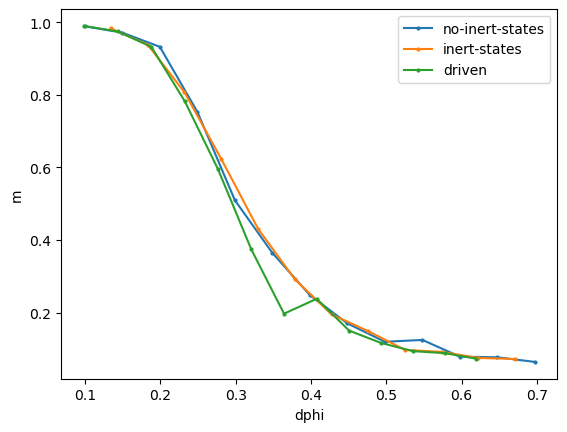

In [ ]:
base_path = Path("/media/moritz/PHD_PROJECT/NOV25/ML_F-20_D0_K0")
analysis_2 = npa.DynamicalOrderDisorder("no_inert_states", base_path)
thermos_for_inert = npa.Thermos()

data = analysis_2.get_data()
data = data.sort_values(by=["mu"])
data["dphi"] = npa.calculate_dphi(data["mu"], thermos_for_inert)
plt.plot(data['dphi'], data["m"], label="no-inert-states", linestyle="solid", ms=2, marker="o")



base_path = Path("/media/moritz/PHD_PROJECT/NOV25/ML_F2_D0_K1")
analysis_2 = npa.DynamicalOrderDisorder("inert_states", base_path)
thermos_for_inert = npa.Thermos(fres=2.0)

data = analysis_2.get_data()
data = data.sort_values(by=["mu"])
data["dphi"] = npa.calculate_dphi(data["mu"], thermos_for_inert)
plt.plot(data['dphi'], data["m"], label="inert-states", linestyle="solid", ms=2, marker="o")


base_path = Path("/media/moritz/PHD_PROJECT/NOV25/ML_F2_D2_K1")
analysis_2 = npa.DynamicalOrderDisorder("driven", base_path)
thermos_driven = npa.Thermos(fres=2.0, dmu=2.0, method='HOMO')

data = analysis_2.get_data()
data = data.sort_values(by=["mu"])
data["dphi"] = npa.calculate_dphi(data["mu"], thermos_driven)
plt.plot(data['dphi'], data["m"], label="driven", linestyle="solid", ms=2, marker="o")


plt.legend()
plt.xlabel("dphi")
plt.ylabel("m")
plt.show()

Plot defaults set.
Blackout mode set.


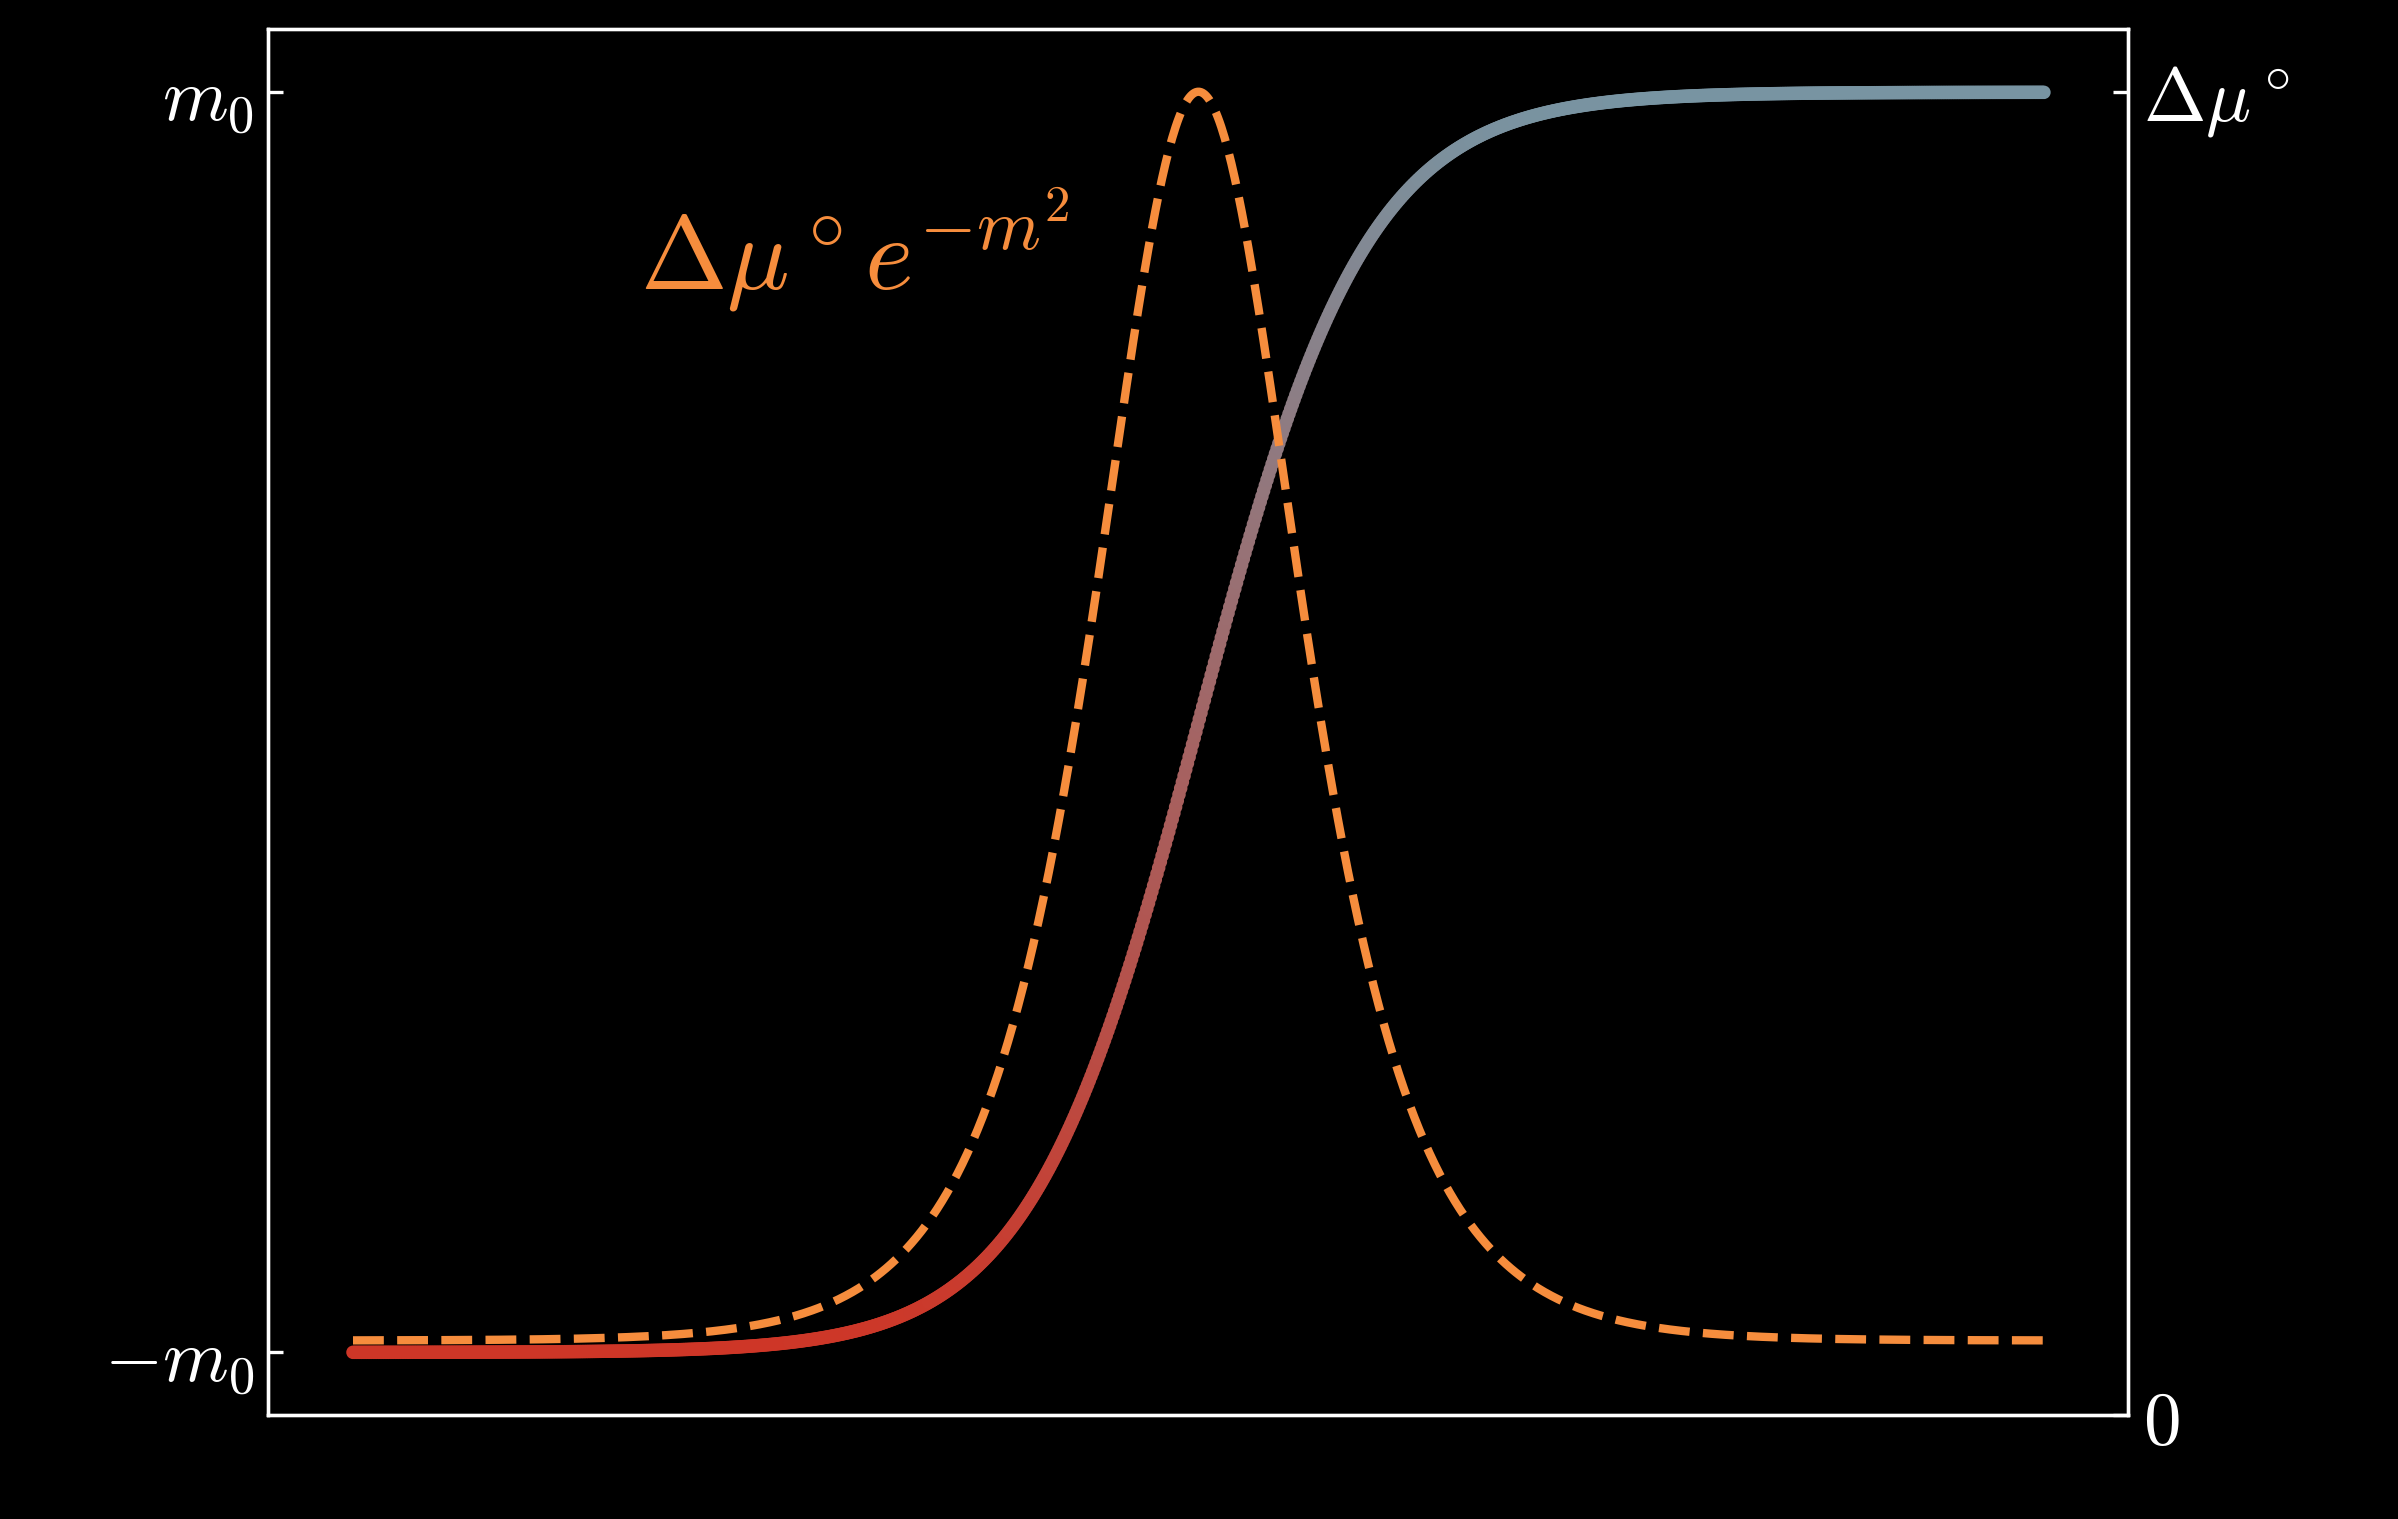

In [2]:
from matplotlib.colors import LinearSegmentedColormap
import matplotlib as mpl
import numpy as np
import matplotlib.pyplot as plt

from plot_defaults import *
set_plot_defaults()
blackout()

fig, ax = plt.subplots()
x = np.linspace(-5,5,1000)
y = np.tanh(x)
# custom colormap: red -> purple -> blue
custom_cmap = LinearSegmentedColormap.from_list('red_purple_blue', [RED, PURPLE, BLUE])

# override the existing 'coolwarm' entry so the subsequent scatter(cmap='coolwarm') uses this map
ax.scatter(x, y, c=y, cmap=custom_cmap, s=5)

mu = 1*np.exp(-y**2)
ax2 = ax.twinx()    
ax2.plot(x,mu, color=ORANGE, lw=2, ls='dashed')

# editable legend text color
plt.text(-3.3, 0.9, r'$\Delta \mu^\circ e^{-m^2}$', color=ORANGE, fontsize=25)

ax.set_ylabel(r"Order Parameter", color='black', fontsize=14)
ax.set_xlabel(r"Assembled Structure $\rightarrow$", color='black', fontsize=14)
ax.set_xticks([])
ax.set_yticks([-1,1], [r"$-m_0$", r"$m_0$"])
ax2.set_ylabel(r'Chemical Driving Force $\beta \Delta \mu$', fontsize=14, color='black')
ax2.set_yticks([0.33,1], [r"$0$", r"$\Delta \mu^\circ$"])

plt.savefig("chemical_driving_force_vs_order_parameter.pdf", bbox_inches='tight')

Whiteout mode set.


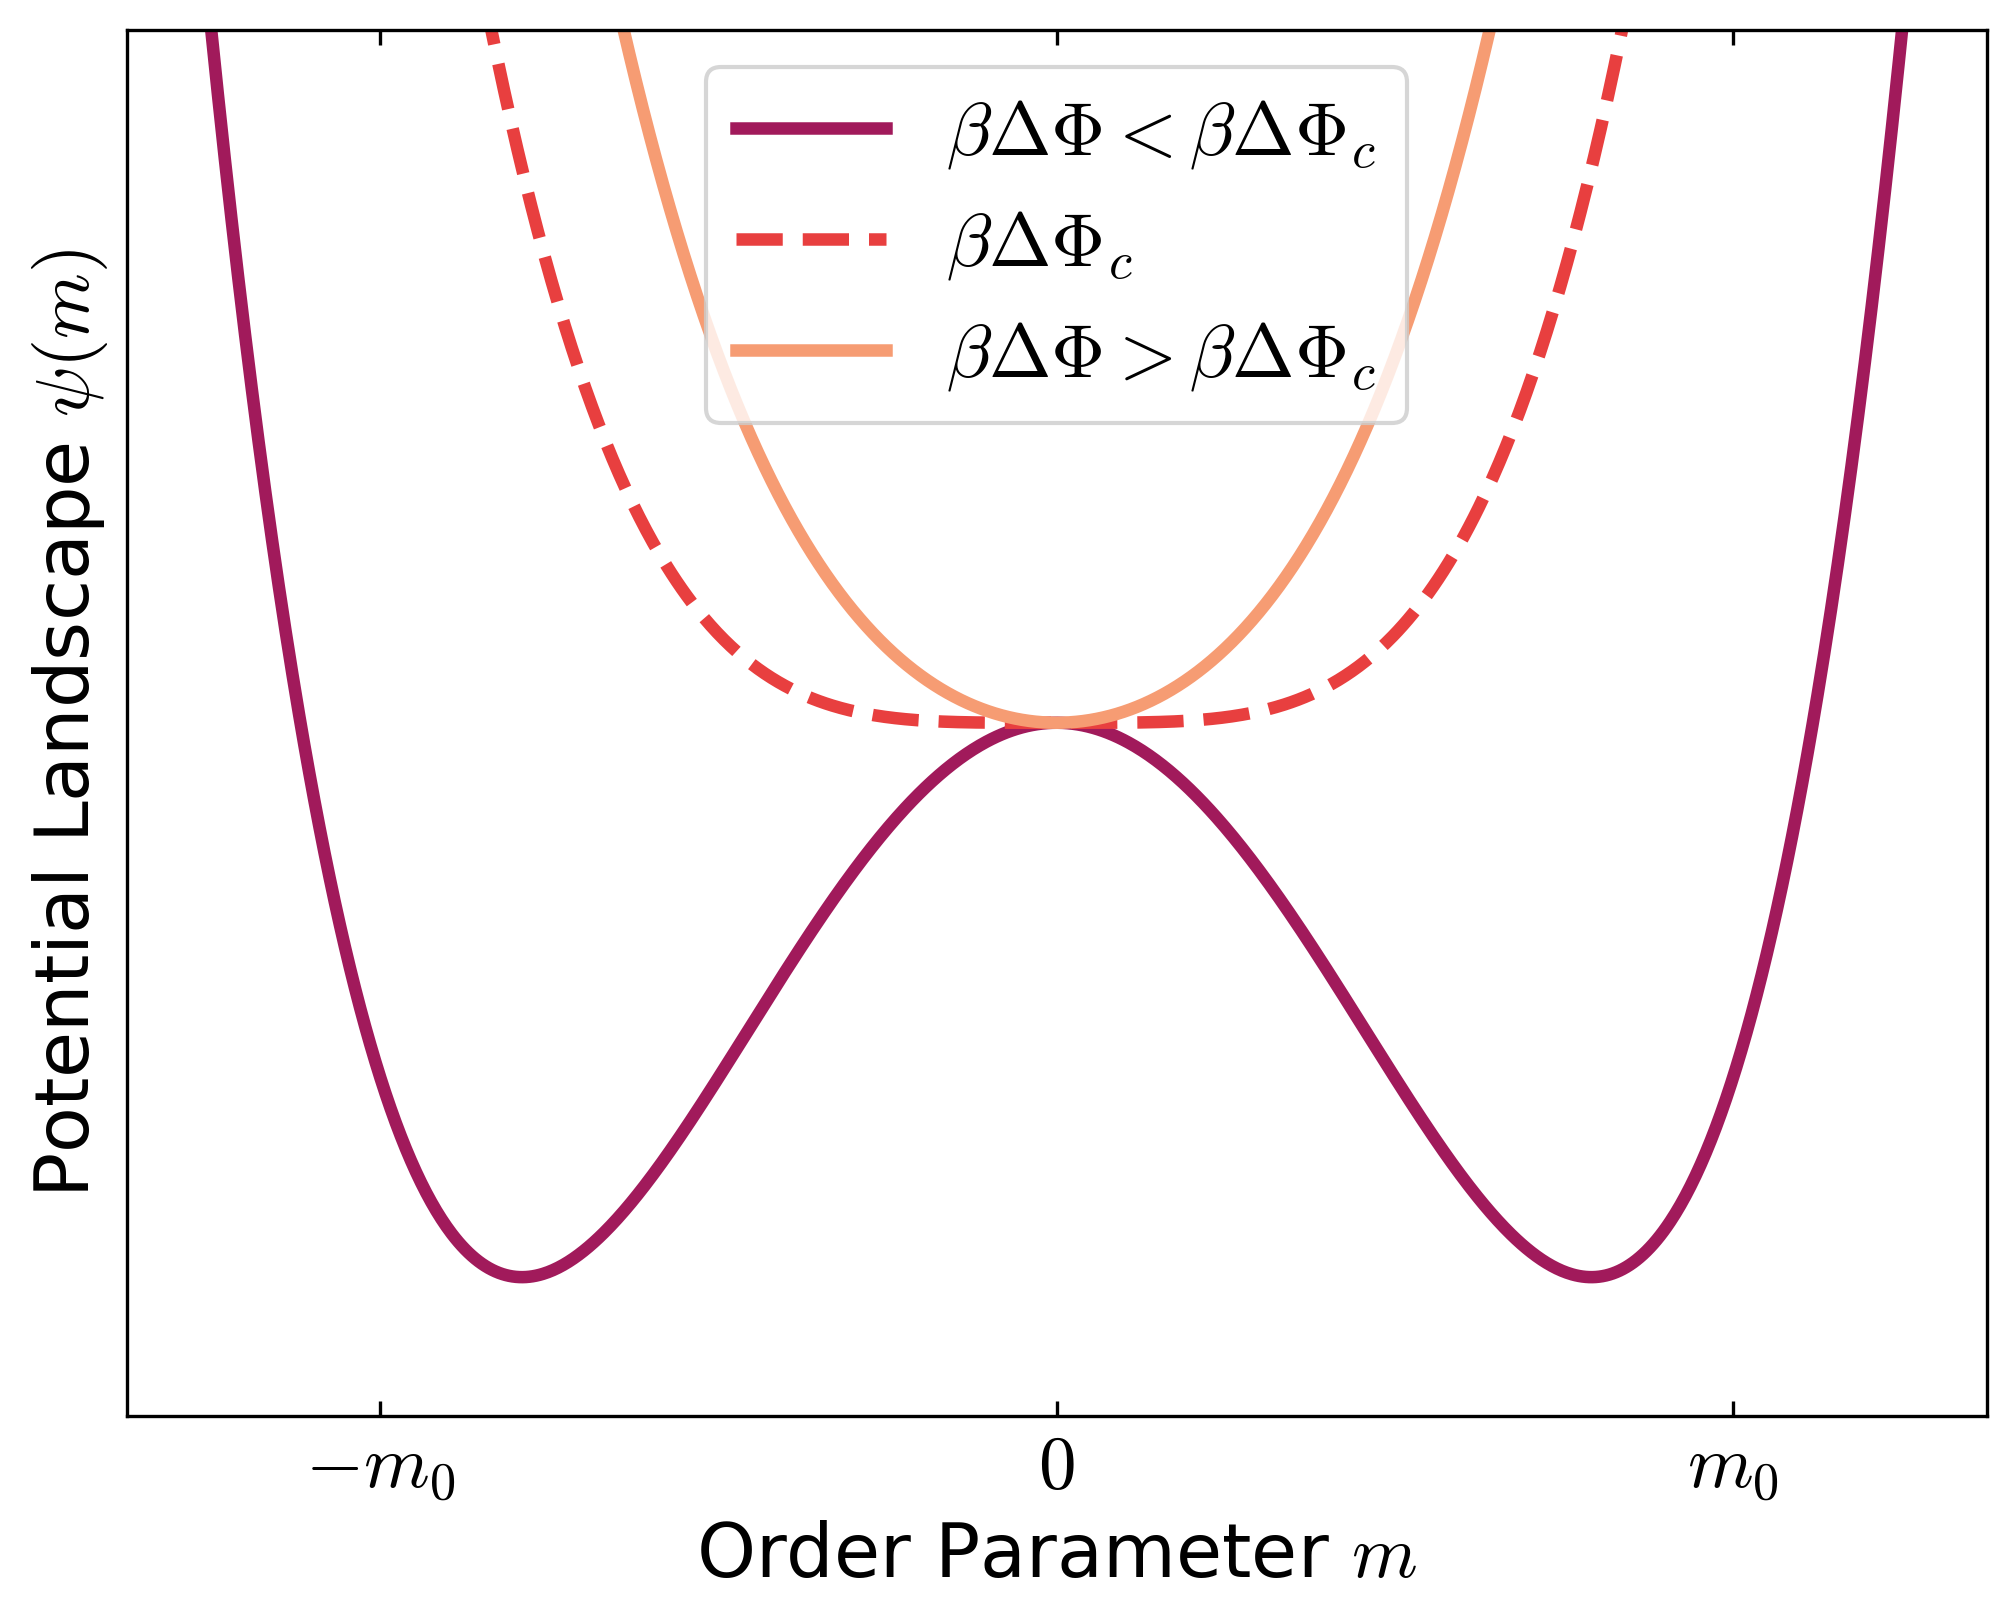

In [143]:
import seaborn as sns
whiteout()
x = np.linspace(-1,1,1000)

colors = sns.color_palette(palette='rocket', n_colors=4)

y = x**4 - 0.8*x**2 - 0.0*x**3
plt.plot(x, y, color=colors[1], lw=3, ls='solid', label=r'$\beta \Delta \Phi < \beta \Delta \Phi_c$')

y = x**4 - 0.0*x**2 - 0.0*x**3
plt.plot(x, y, color=colors[2], lw=3, ls='dashed', label=r'$\beta \Delta \Phi_c$')

y = x**4 + 0.5*x**2 - 0.0*x**3
plt.plot(x, y, color=colors[3], lw=3, ls='solid', label=r'$\beta \Delta \Phi > \beta \Delta \Phi_c$')


plt.ylabel(r'Potential Landscape $\psi(m)$', fontsize=FS_LEGEND)
plt.yticks([])
plt.xlabel(r'Order Parameter $m$', fontsize=FS_LEGEND)
plt.xticks([-0.8,0, 0.8], [r"$-m_0$", r"$0$", r"$m_0$"], fontsize=FS_LEGEND)
plt.legend()
plt.ylim(-0.2,0.2)
plt.savefig("non_eq_free_energy_vs_order_parameter_bright.pdf", bbox_inches='tight')

--- Logging error ---
Traceback (most recent call last):
  File "/home/moritz/miniforge3/envs/MLO/lib/python3.12/logging/__init__.py", line 1160, in emit
    msg = self.format(record)
          ^^^^^^^^^^^^^^^^^^^
  File "/home/moritz/miniforge3/envs/MLO/lib/python3.12/logging/__init__.py", line 999, in format
    return fmt.format(record)
           ^^^^^^^^^^^^^^^^^^
  File "/home/moritz/miniforge3/envs/MLO/lib/python3.12/logging/__init__.py", line 703, in format
    record.message = record.getMessage()
                     ^^^^^^^^^^^^^^^^^^^
  File "/home/moritz/miniforge3/envs/MLO/lib/python3.12/logging/__init__.py", line 392, in getMessage
    msg = msg % self.args
          ~~~~^~~~~~~~~~~
TypeError: not all arguments converted during string formatting
Call stack:
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/home/moritz/miniforge3/envs/MLO/lib/python3.12/site-packages/ipykernel_launcher.py", line 17, in <module

Whiteout mode set.


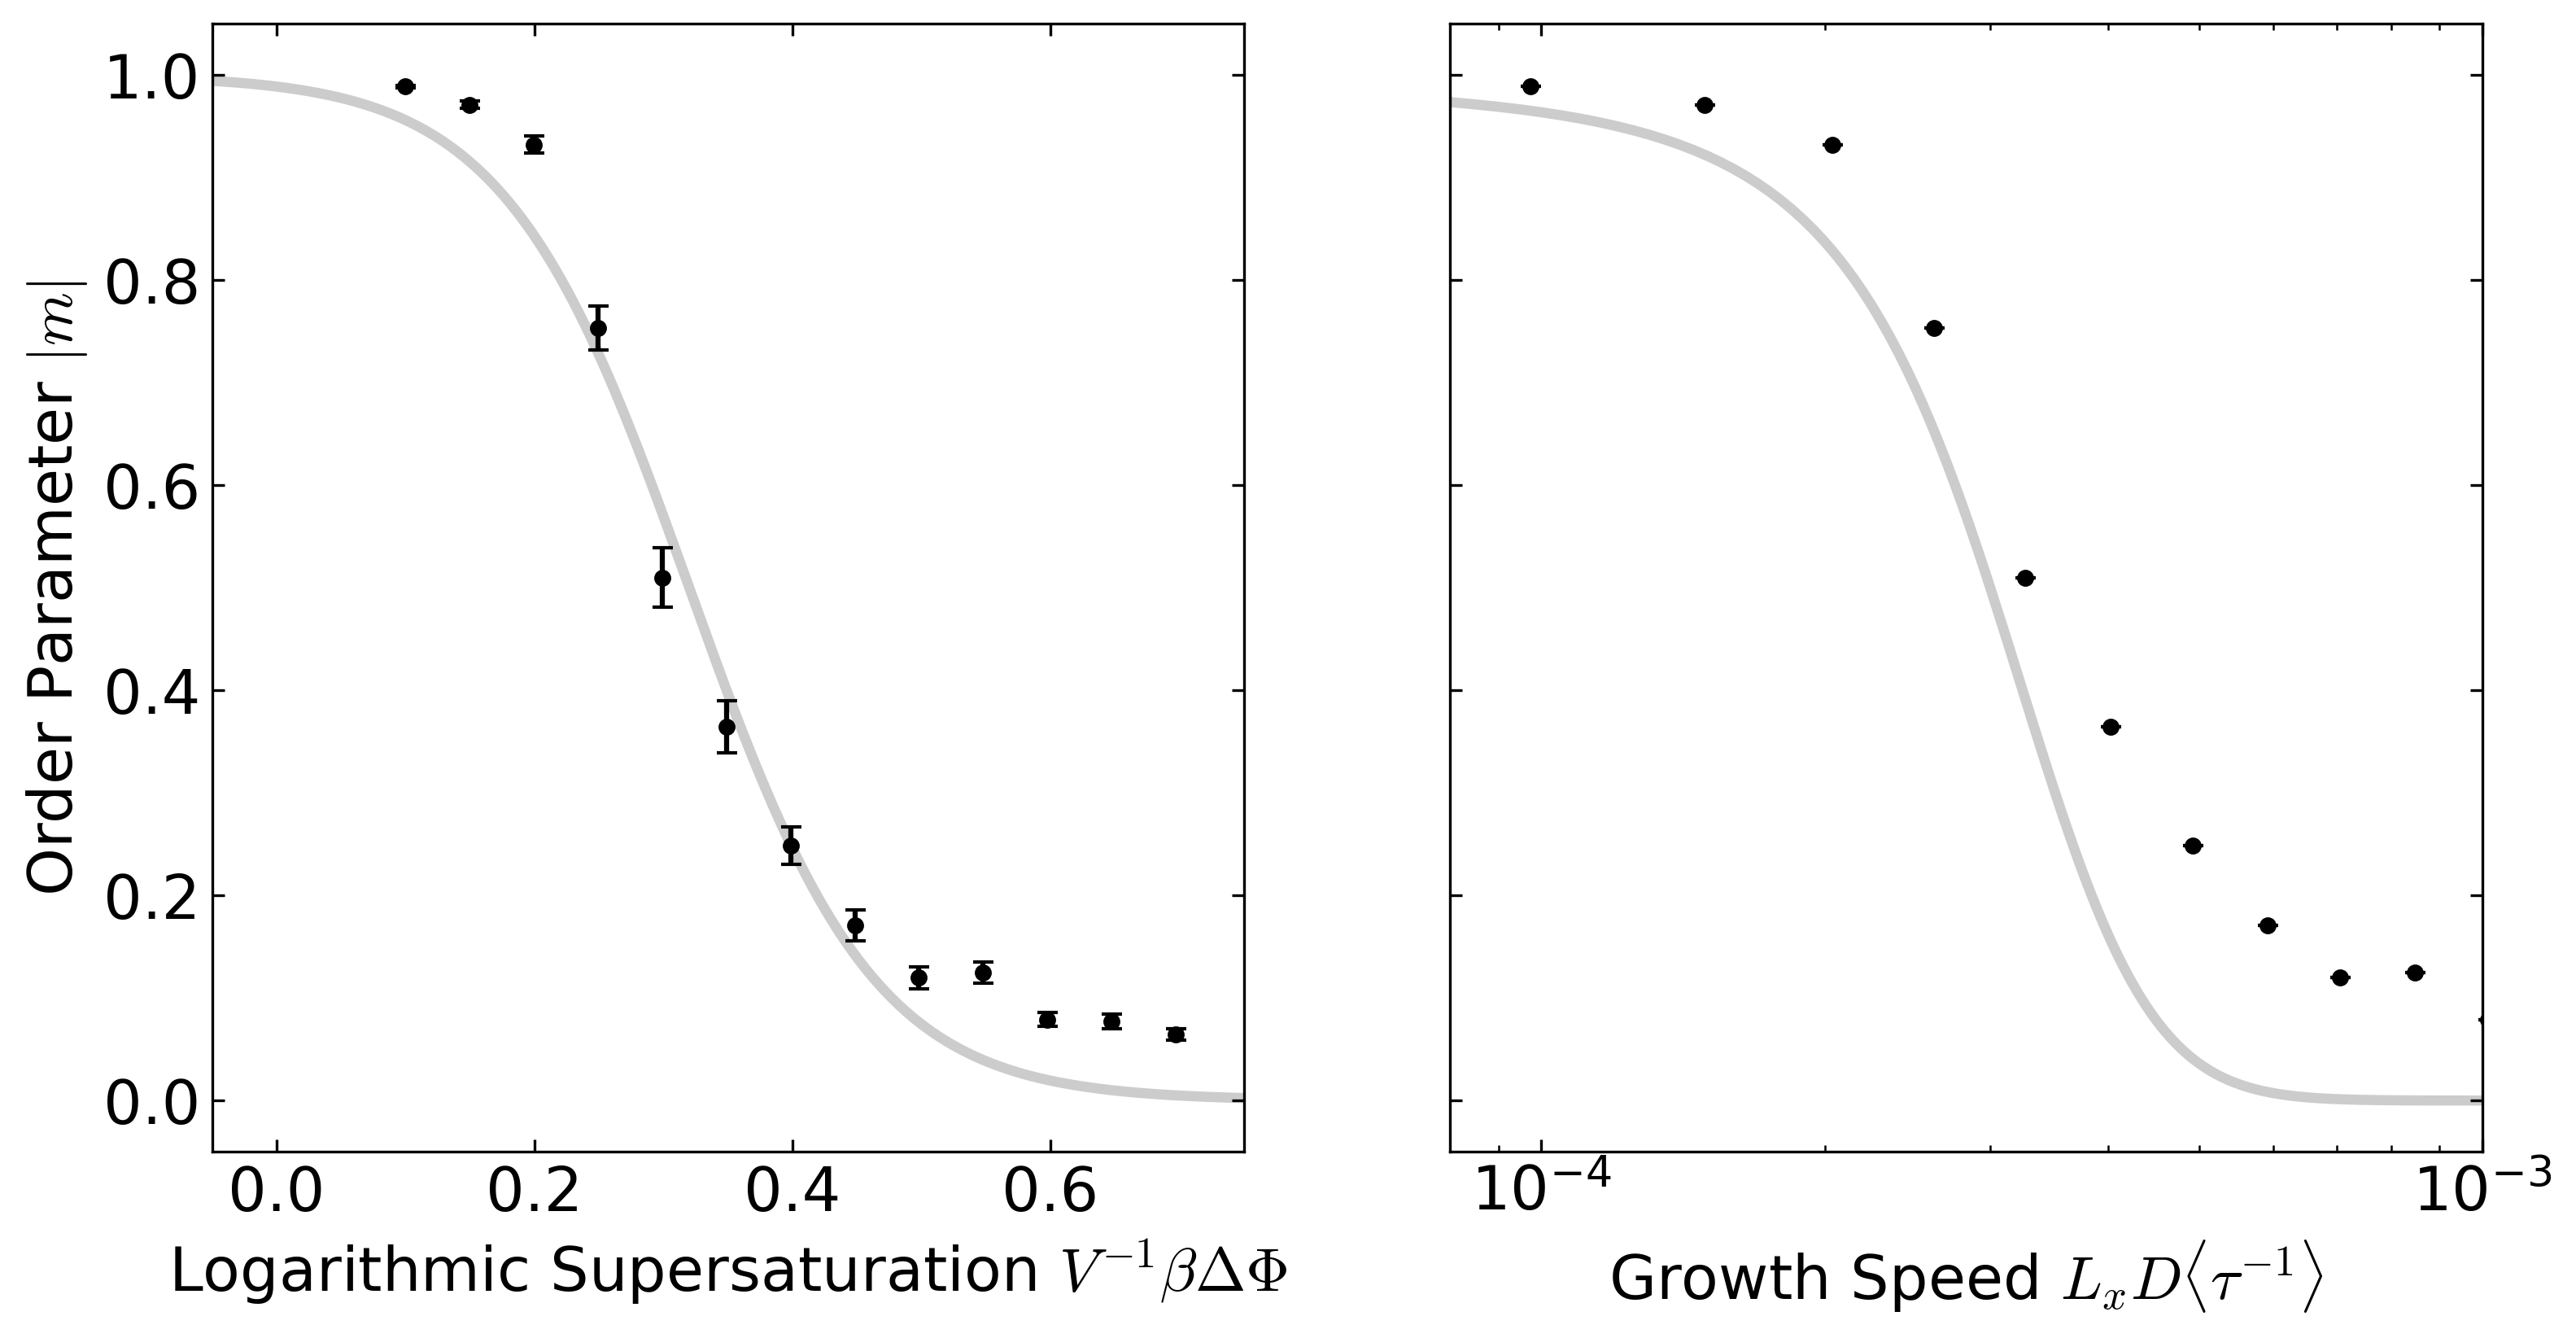

In [146]:
base_path = Path("/media/moritz/PHD_PROJECT/NOV25/ML_F-20_D0_K0")
analysis_2 = npa.DynamicalOrderDisorder("no_inert_states", base_path)
thermos_for_inert = npa.Thermos()

data = analysis_2.get_data()
data = data.sort_values(by=["mu"])
data["dphi"] = npa.calculate_dphi(data["mu"], thermos_for_inert)

whiteout()
fig, ax = plt.subplots(1,2, figsize=(12,6), sharey=True)

ax[0].errorbar(data['dphi'], data["m"],yerr=data['dm'], label="no-inert-states", linestyle="none", ms=4, marker="o", color='black',
               capsize=3)

ax[0].set_xlabel(r"Logarithmic Supersaturation $V^{-1} \beta \Delta \Phi$", fontsize=FS_LEGEND)
ax[0].set_ylabel(r"Order Parameter $\vert m \vert$", fontsize=FS_LEGEND)

ax[1].errorbar(data['growth_speed'], data["m"], yerr=data['dt']*1./data['t']**2*160, label="no-inert-states", linestyle="none", ms=4, marker="o", color='black',
               capsize=3)
ax[1].set_xscale("log")
ax[1].set_xlabel(r"Growth Speed $L_x D \langle \tau^{-1} \rangle$", fontsize=FS_LEGEND)


def curve(x, b, c):
    return -0.5 * (np.tanh(b * (x - c))-1)

x = np.linspace(-0.5,1.0,1000)
y = curve(x, 7, 0.32)
ax[0].plot(x, y, color='black', lw=3, ls='solid', alpha=0.2)
ax[0].set_xlim(-0.05, 0.75)


x = np.linspace(1e-5, 5e-3, 1000)
y = curve(x, 8200, 3e-4)
ax[1].plot(x, y, color='black', lw=3, ls='solid', alpha=0.2)
ax[1].set_xlim(8e-5, 1e-3)


ax[0].text(0.51, 0.9, r"$ m = m\left( \beta \Delta \Phi, \beta \epsilon_{ii}, \beta \epsilon_{ij} \right)$", transform=ax[0].transAxes, color='white', fontsize=14)

plt.savefig("order_parameter_vs_dphi_and_growth_speed_bright.pdf", bbox_inches='tight')

Blackout mode set.
Blackout mode set.


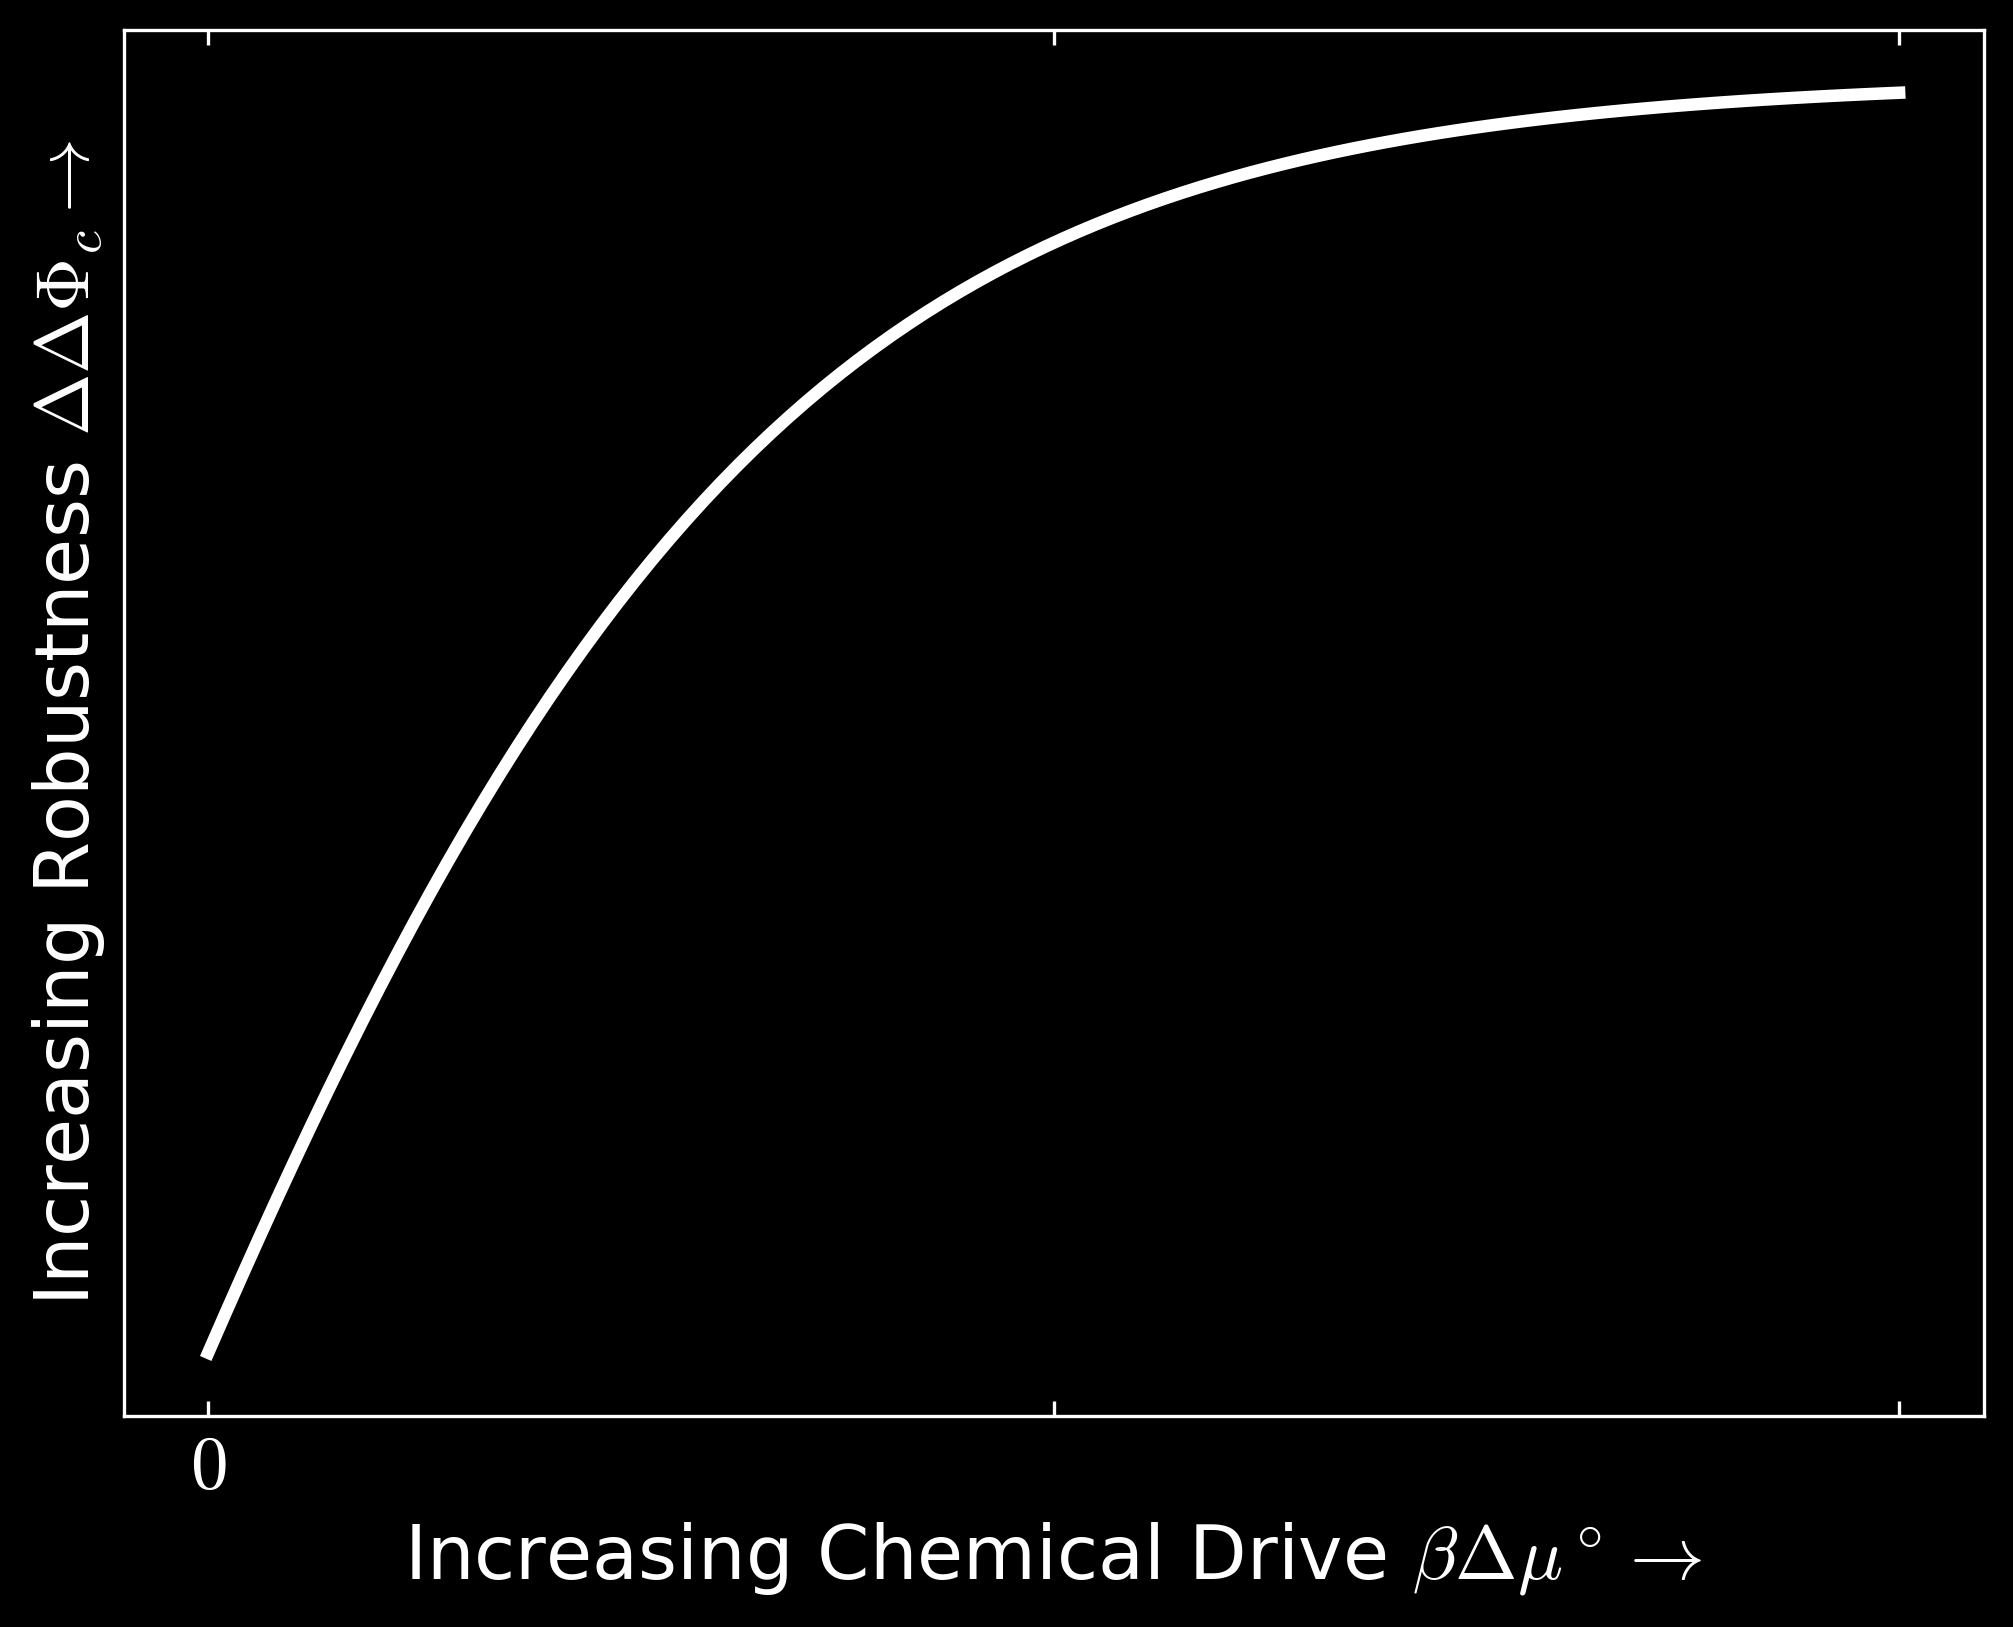

In [149]:
fig, ax = plt.subplots(figsize=(8,6))
blackout()
dmu_cont = np.linspace(0,5,100)
dphi_c = np.log((1+np.exp(dmu_cont+1))/(1+np.exp(dmu_cont)*1.018))
blackout()
ax.plot(dmu_cont, dphi_c, lw=3, color='white', ls='solid')
ax.set_xticks([0,2.5,5], [r"$0$", "", ""])
ax.set_yticks([])
ax.set_xlabel(r"Increasing Chemical Drive $\beta \Delta \mu^\circ \rightarrow$", color='white', fontsize=FS_LEGEND)
ax.set_ylabel(r"Increasing Robustness $\Delta \Delta \Phi_c \rightarrow$", color='white', fontsize=FS_LEGEND)
plt.savefig('mft.pdf', bbox_inches='tight')

In [116]:
from matplotlib.colors import ListedColormap
cmap = ListedColormap(['white', 'white', '#333333', '#ce3627', '#7894a2'])
norm = plt.Normalize(vmin=-2, vmax=2)

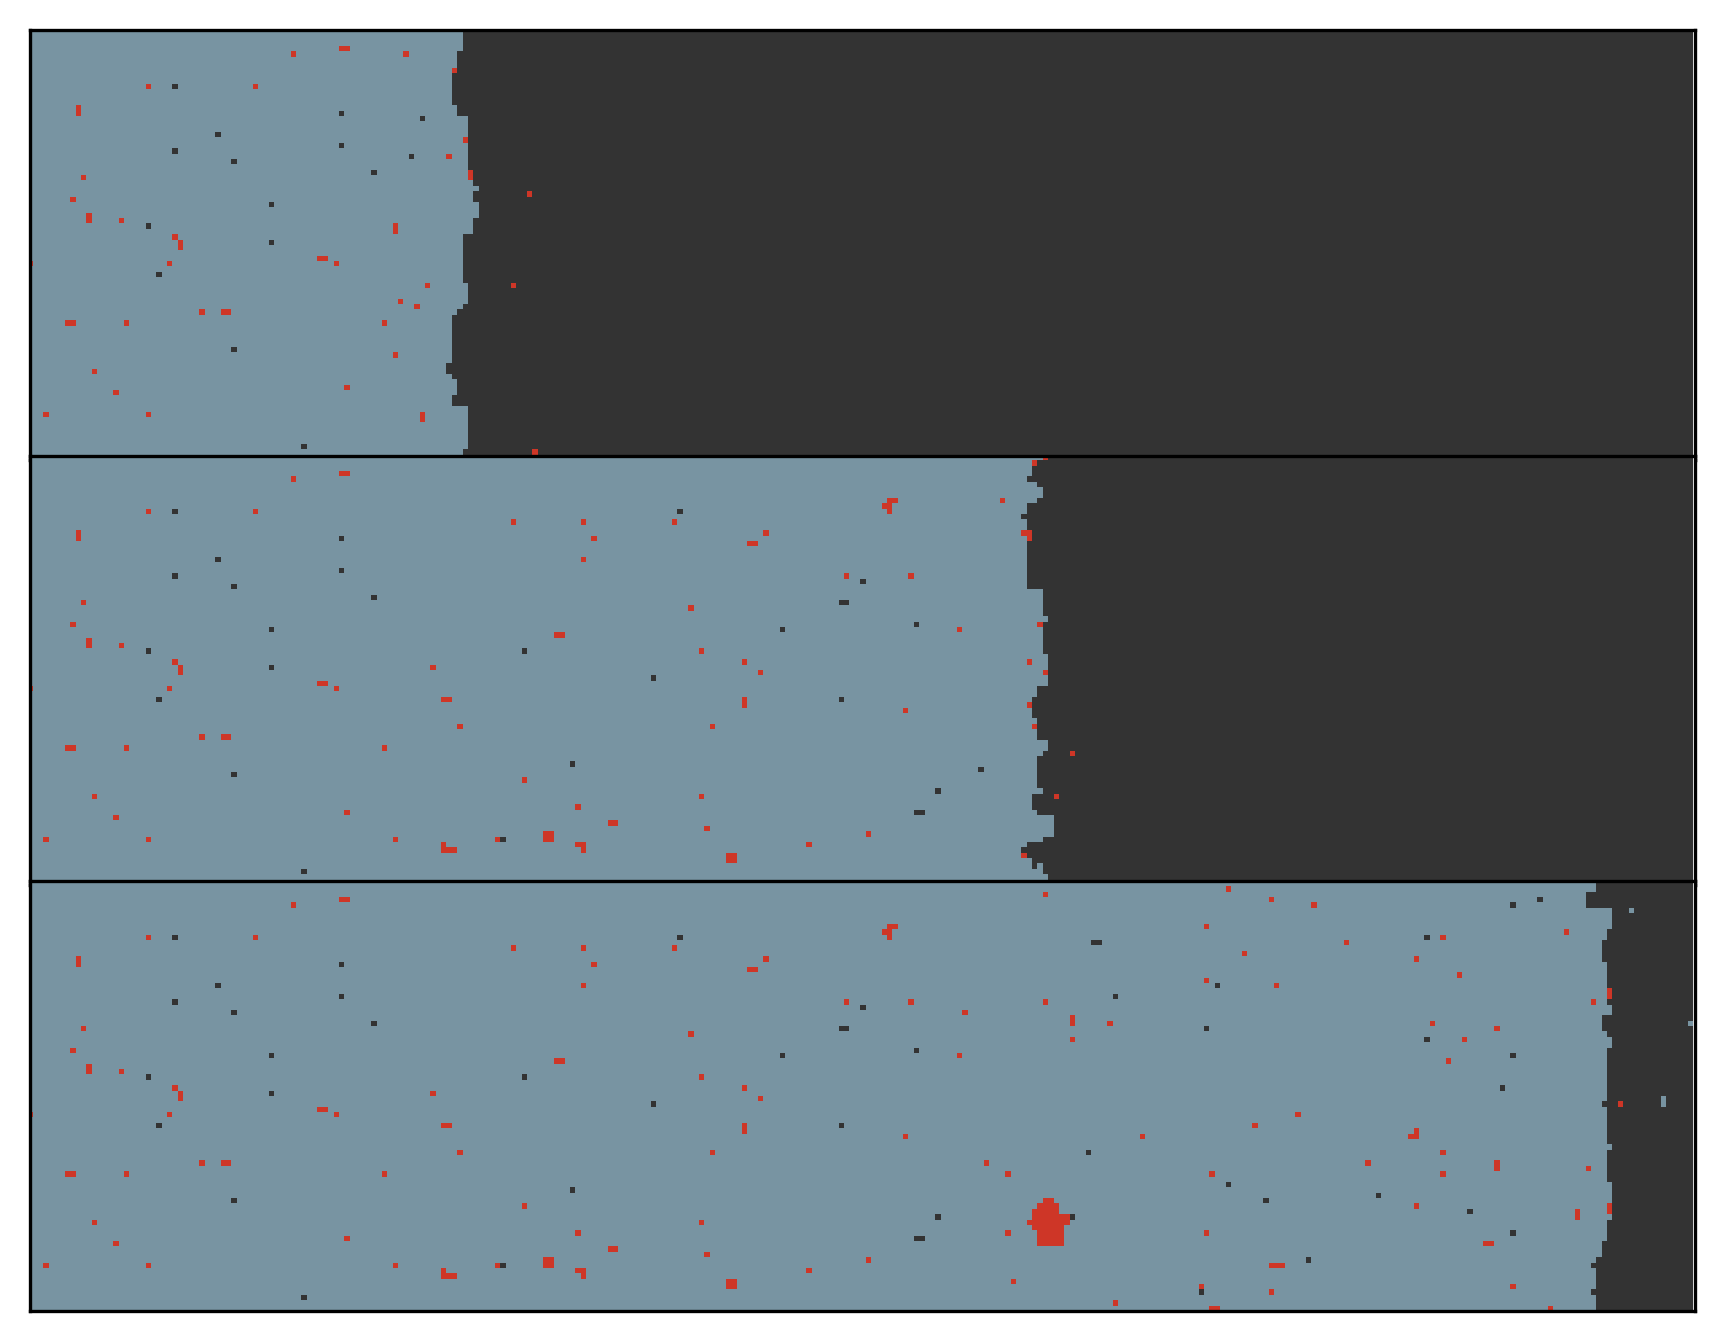

In [117]:
fig, ax = plt.subplots(3,1, figsize=(6,18))


main_lattice = np.load('/media/moritz/PHD_PROJECT/NOV25/ML_F-20_D0_K0/-6.85/2025-11-05-15:15_14/lattice_final.npy')


lattice_2 = np.load('/media/moritz/PHD_PROJECT/NOV25/ML_F-20_D0_K0/-6.85/2025-11-05-15:15_12/lattice_final.npy')
lattice_combined = main_lattice.copy()
lattice_combined[:,77:107] = lattice_2[:,290:320]
lattice_combined[:,107:320] = 0
ax[0].imshow(lattice_combined, cmap=cmap, norm=norm)

lattice_3 = np.load('/media/moritz/PHD_PROJECT/NOV25/ML_F-20_D0_K0/-6.85/2025-11-05-15:15_11/lattice_final.npy')
lattice_combined = main_lattice.copy()
lattice_combined[:,184:214] = lattice_3[:,290:320]
lattice_combined[:,214:320] = 0
ax[1].imshow(lattice_combined, cmap=cmap, norm=norm)

ax[2].imshow(main_lattice, cmap=cmap, norm=norm)

for ax_i in ax:
    ax_i.set_xticks([])
    ax_i.set_yticks([])
    ax_i.set_xlim(10,320)

fig.tight_layout(h_pad=-50.0, w_pad=0.0)
plt.savefig("lattice_snapshots_dark.pdf", bbox_inches='tight')


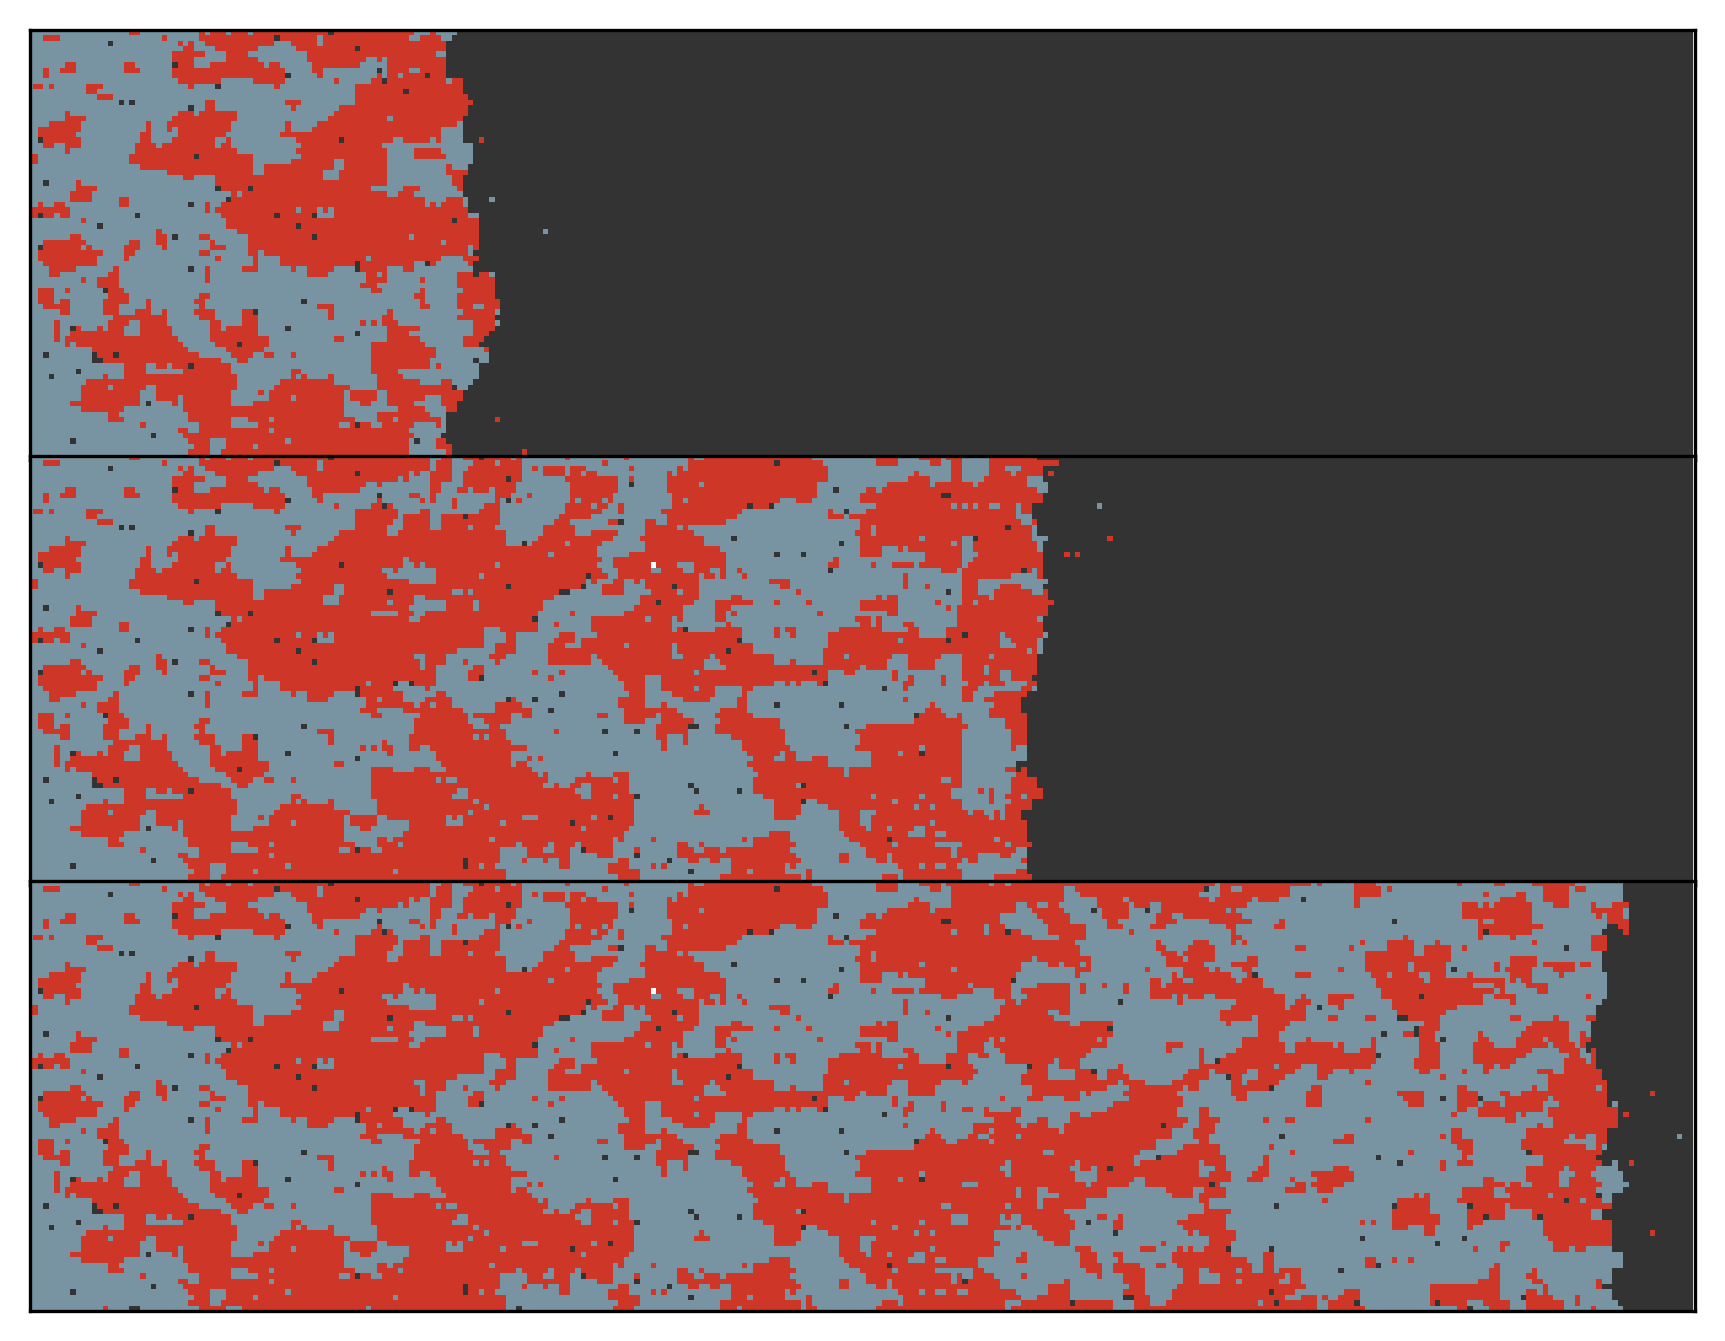

In [118]:
fig, ax = plt.subplots(3,1, figsize=(6,18))


main_lattice = np.load('/media/moritz/PHD_PROJECT/NOV25/ML_F-20_D0_K0/-6.4/2025-11-05-15:17_14/lattice_final.npy')


lattice_2 = np.load('/media/moritz/PHD_PROJECT/NOV25/ML_F-20_D0_K0/-6.4/2025-11-05-15:17_12/lattice_final.npy')
lattice_combined = main_lattice.copy()
lattice_combined[:,77:107] = lattice_2[:,290:320]
lattice_combined[:,107:320] = 0
ax[0].imshow(lattice_combined, cmap=cmap, norm=norm)

lattice_3 = np.load('/media/moritz/PHD_PROJECT/NOV25/ML_F-20_D0_K0/-6.4/2025-11-05-15:17_10/lattice_final.npy')
lattice_combined = main_lattice.copy()
lattice_combined[:,184:214] = lattice_3[:,290:320]
lattice_combined[:,214:320] = 0
ax[1].imshow(lattice_combined, cmap=cmap, norm=norm)

ax[2].imshow(main_lattice, cmap=cmap, norm=norm)

for ax_i in ax:
    ax_i.set_xticks([])
    ax_i.set_yticks([])
    ax_i.set_xlim(10,320)

fig.tight_layout(h_pad=-50.0, w_pad=0.0)
plt.savefig("lattice_snapshots_high_supersat_dark.pdf", bbox_inches='tight')


Whiteout mode set.


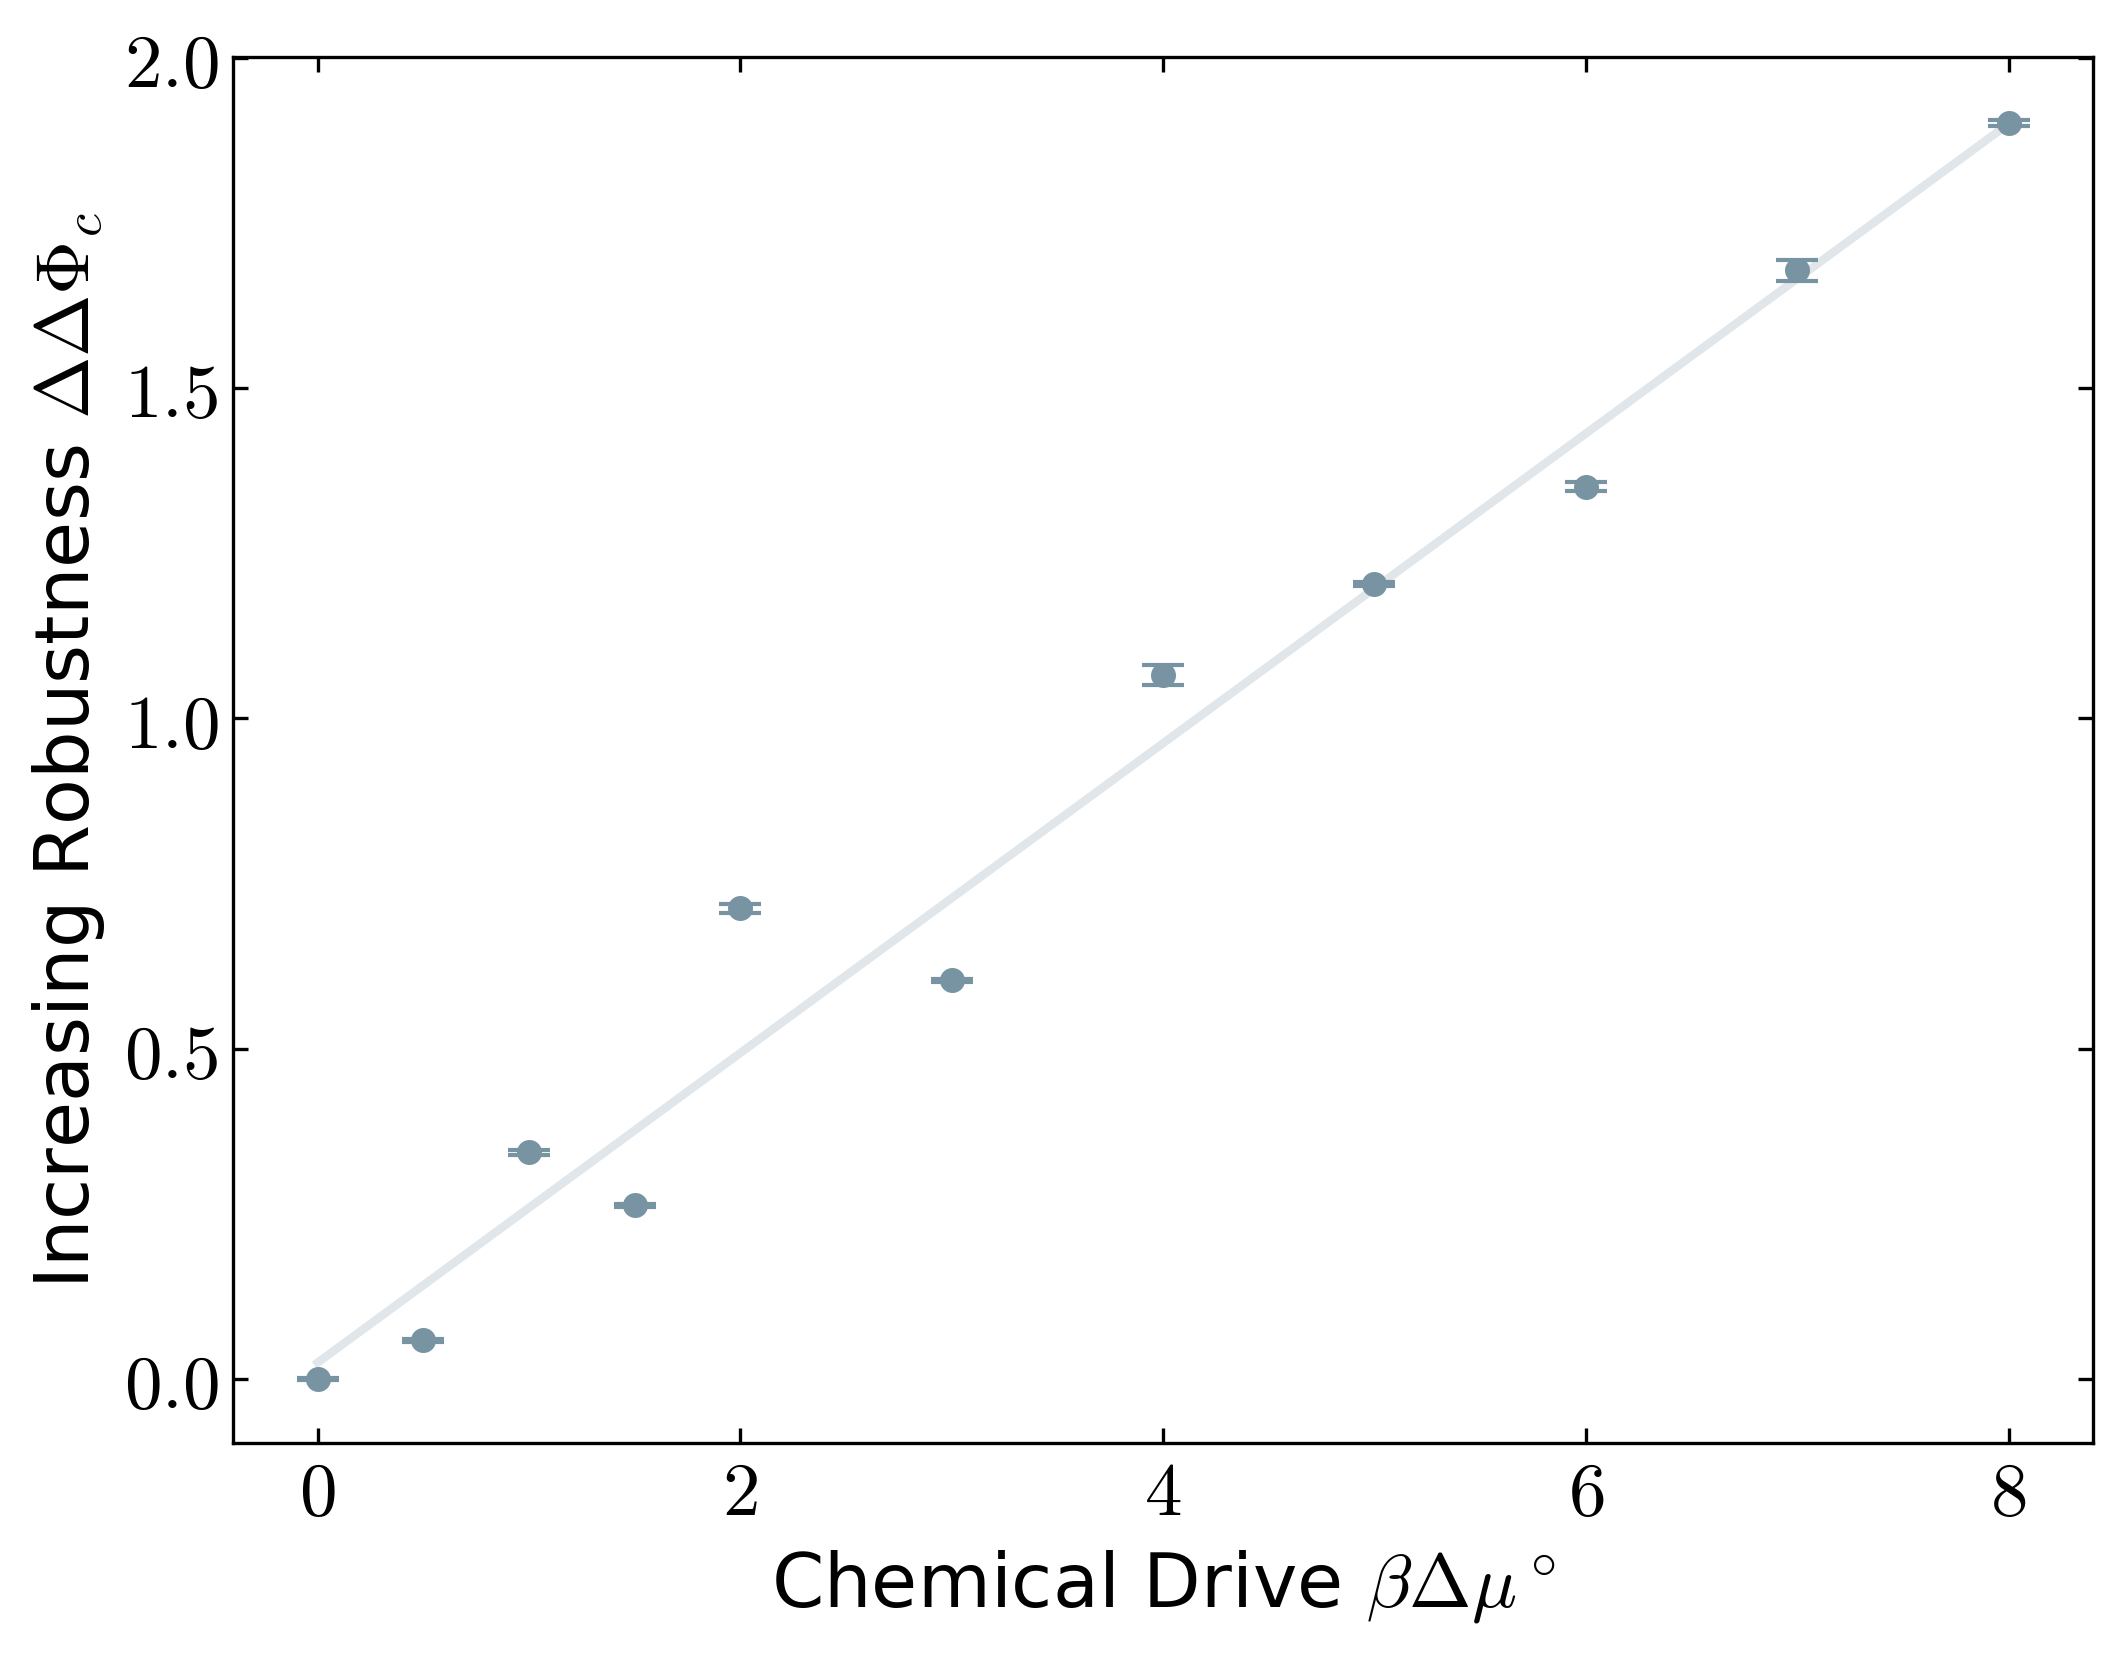

In [137]:
whiteout()

fig, ax = plt.subplots(figsize=(8,6))
data = pd.read_csv("data_dic_s6_crits.csv")

from scipy.optimize import curve_fit
def linear(x, a, b):
    return a * x + b


FS_LEGEND = 18
FS_TITLE = 22

popt, pcov = curve_fit(linear, data['dmu'], data['dphic']-data['dphic'].min())
x_fit = np.linspace(0,8,100)
y_fit = linear(x_fit, *popt)
ax.plot(x_fit, y_fit, lw=2, color='#e0e6e9', ls='-', alpha=1.)

ax.errorbar(data['dmu'], data['dphic']-data['dphic'].min(), yerr=data['ddphic'], ms=5, marker='o', color='#7894a3', ls='none', capsize=5)


ax.set_xlabel(r'Chemical Drive $\beta \Delta \mu^\circ$', color='black', fontsize=FS_LEGEND)
ax.set_ylabel(r'Increasing Robustness $\Delta \Delta \Phi_c$', color='black', fontsize=FS_LEGEND)



ax.set_yticks([0.0,0.5,1.0,1.5,2.0], [r'$0.0$', r'$0.5$', r'$1.0$', r'$1.5$', r'$2.0$'], color='black', fontsize=FS_LEGEND)
ax.set_xticks([0,2,4,6,8], [r'$0$', r'$2$', r'$4$', r'$6$', r'$8$'], color='black', fontsize=FS_LEGEND)
plt.savefig("dphic_vs_dmu_whiteout.pdf", bbox_inches='tight')

Blackout mode set.


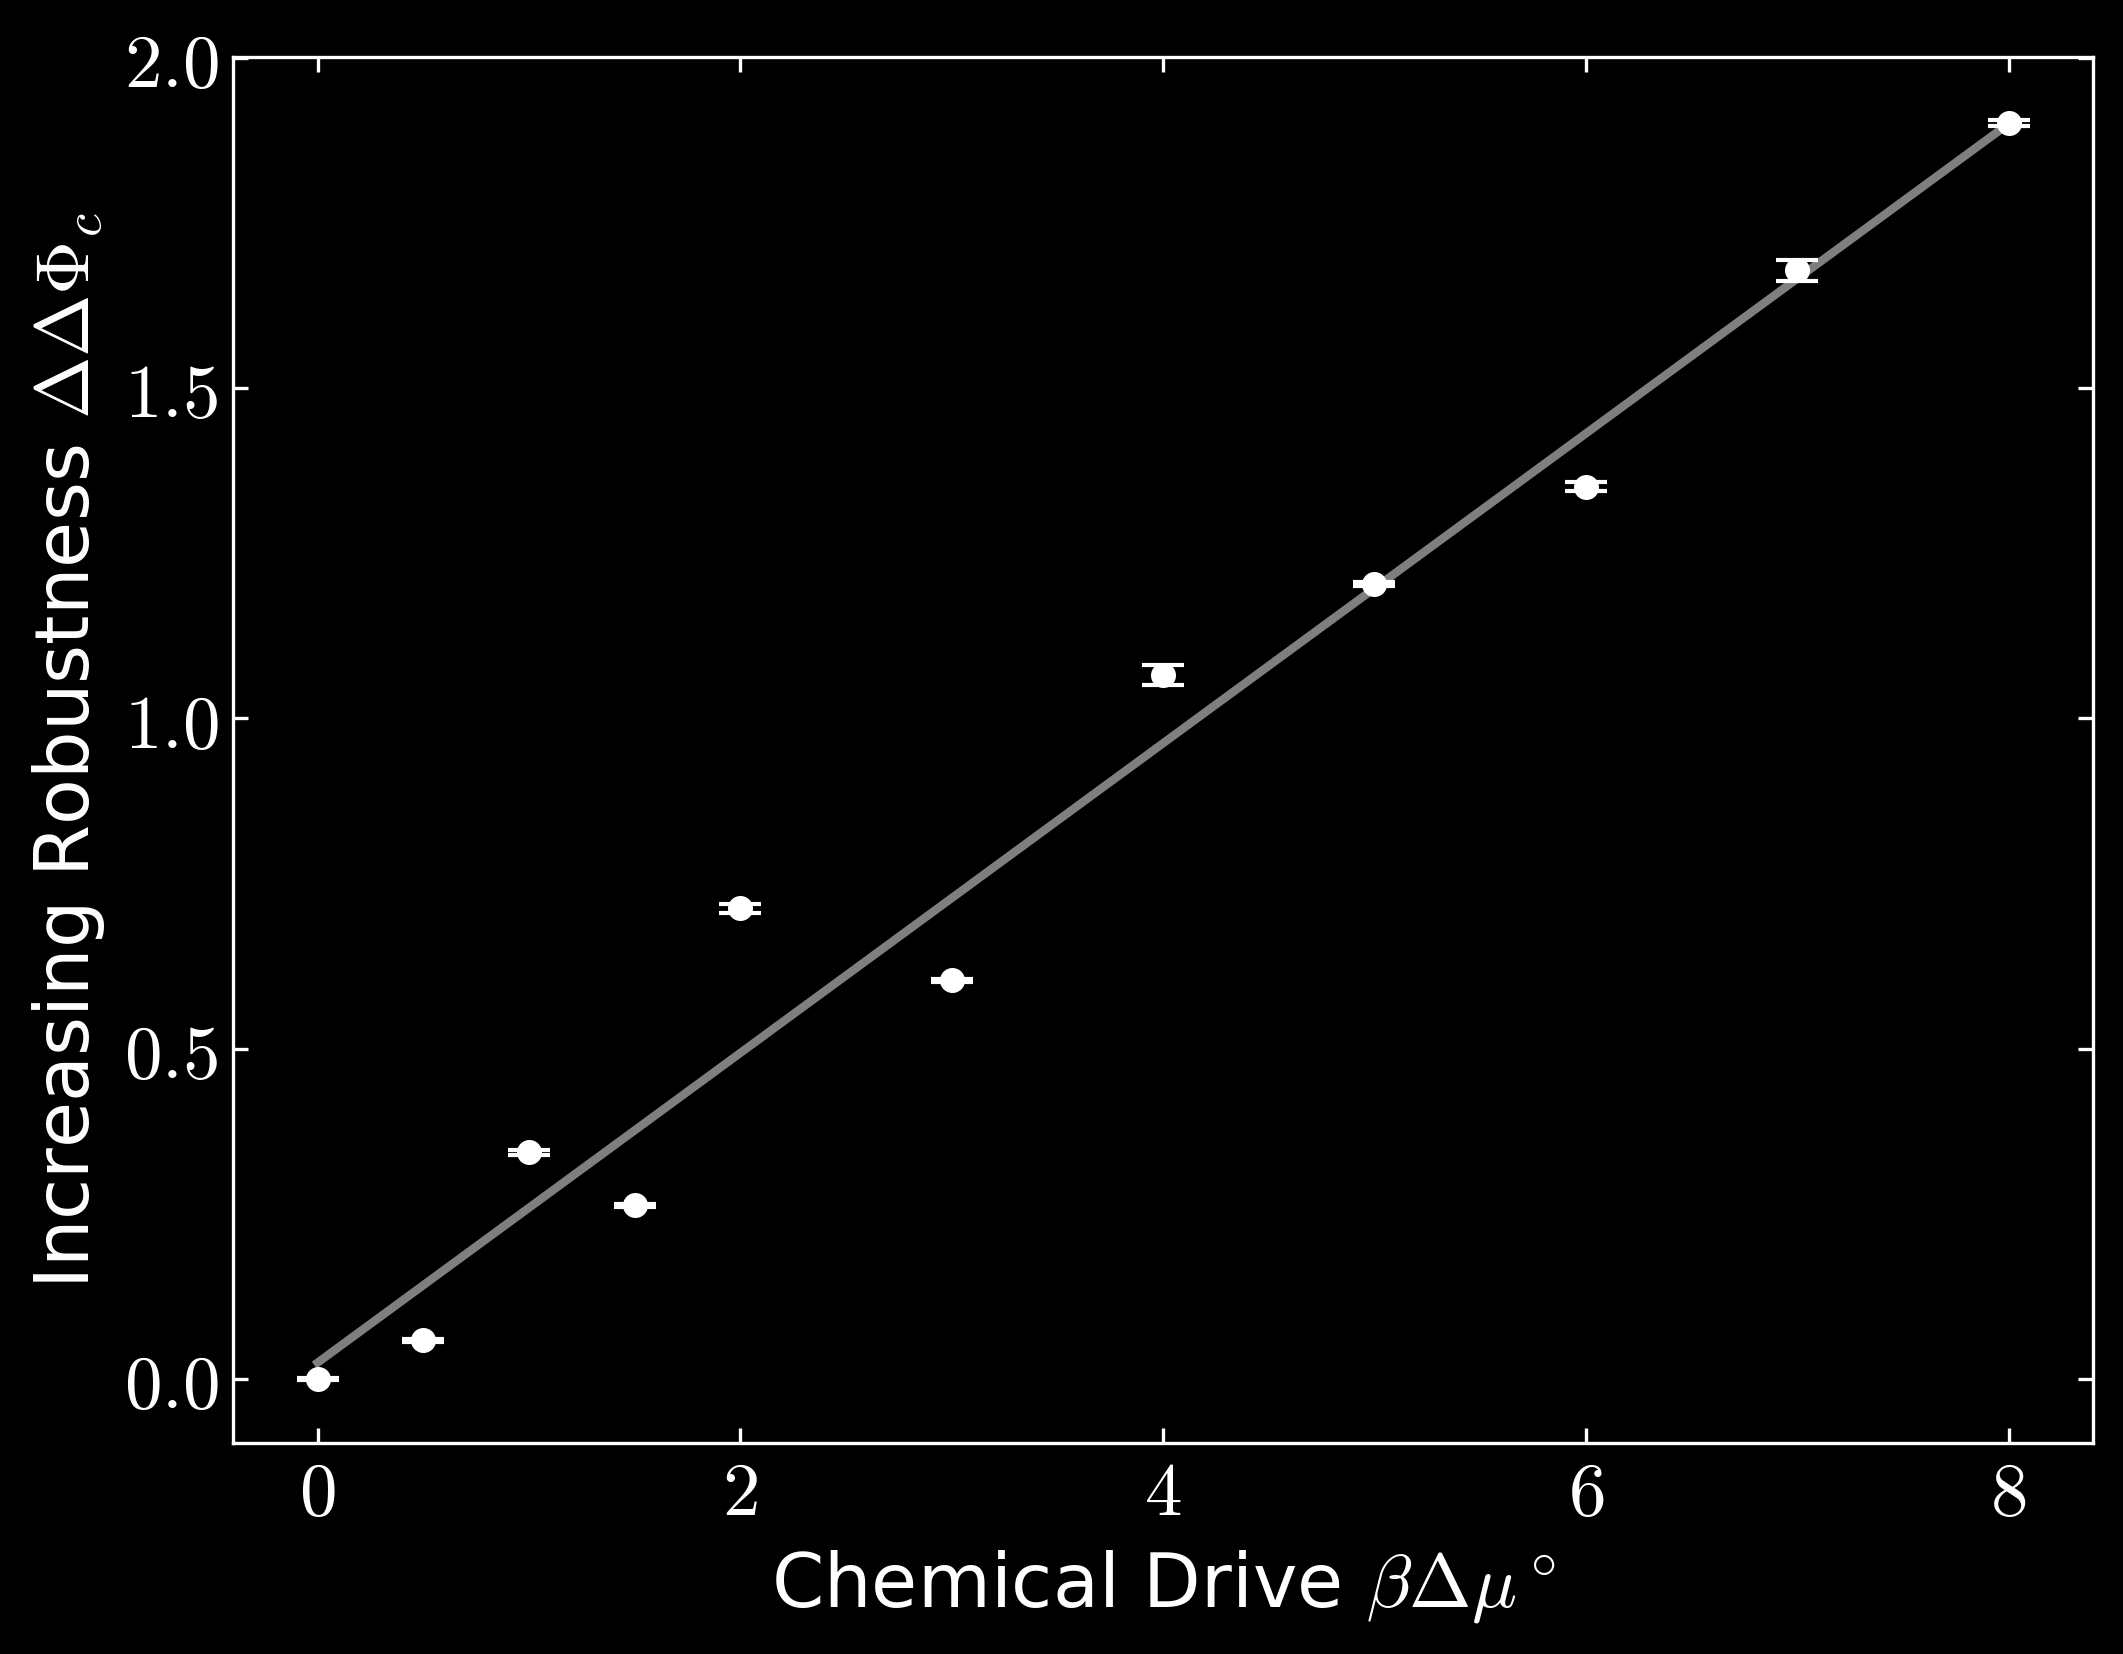

In [156]:
blackout()

fig, ax = plt.subplots(figsize=(8,6))
data = pd.read_csv("data_dic_s6_crits.csv")

from scipy.optimize import curve_fit
def linear(x, a, b):
    return a * x + b


FS_LEGEND = 18
FS_TITLE = 22

popt, pcov = curve_fit(linear, data['dmu'], data['dphic']-data['dphic'].min())
x_fit = np.linspace(0,8,100)
y_fit = linear(x_fit, *popt)
ax.plot(x_fit, y_fit, lw=2, color='#ffffff', ls='-', alpha=.5)

ax.errorbar(data['dmu'], data['dphic']-data['dphic'].min(), yerr=data['ddphic'], ms=5, marker='o', color='#ffffff', ls='none', capsize=5)


ax.set_xlabel(r'Chemical Drive $\beta \Delta \mu^\circ$', color='w', fontsize=FS_LEGEND)
ax.set_ylabel(r'Increasing Robustness $\Delta \Delta \Phi_c$', color='w', fontsize=FS_LEGEND)



ax.set_yticks([0.0,0.5,1.0,1.5,2.0], [r'$0.0$', r'$0.5$', r'$1.0$', r'$1.5$', r'$2.0$'], color='w', fontsize=FS_LEGEND)
ax.set_xticks([0,2,4,6,8], [r'$0$', r'$2$', r'$4$', r'$6$', r'$8$'], color='w', fontsize=FS_LEGEND)
plt.savefig("dphic_vs_dmu_blackout.pdf", bbox_inches='tight')

Whiteout mode set.


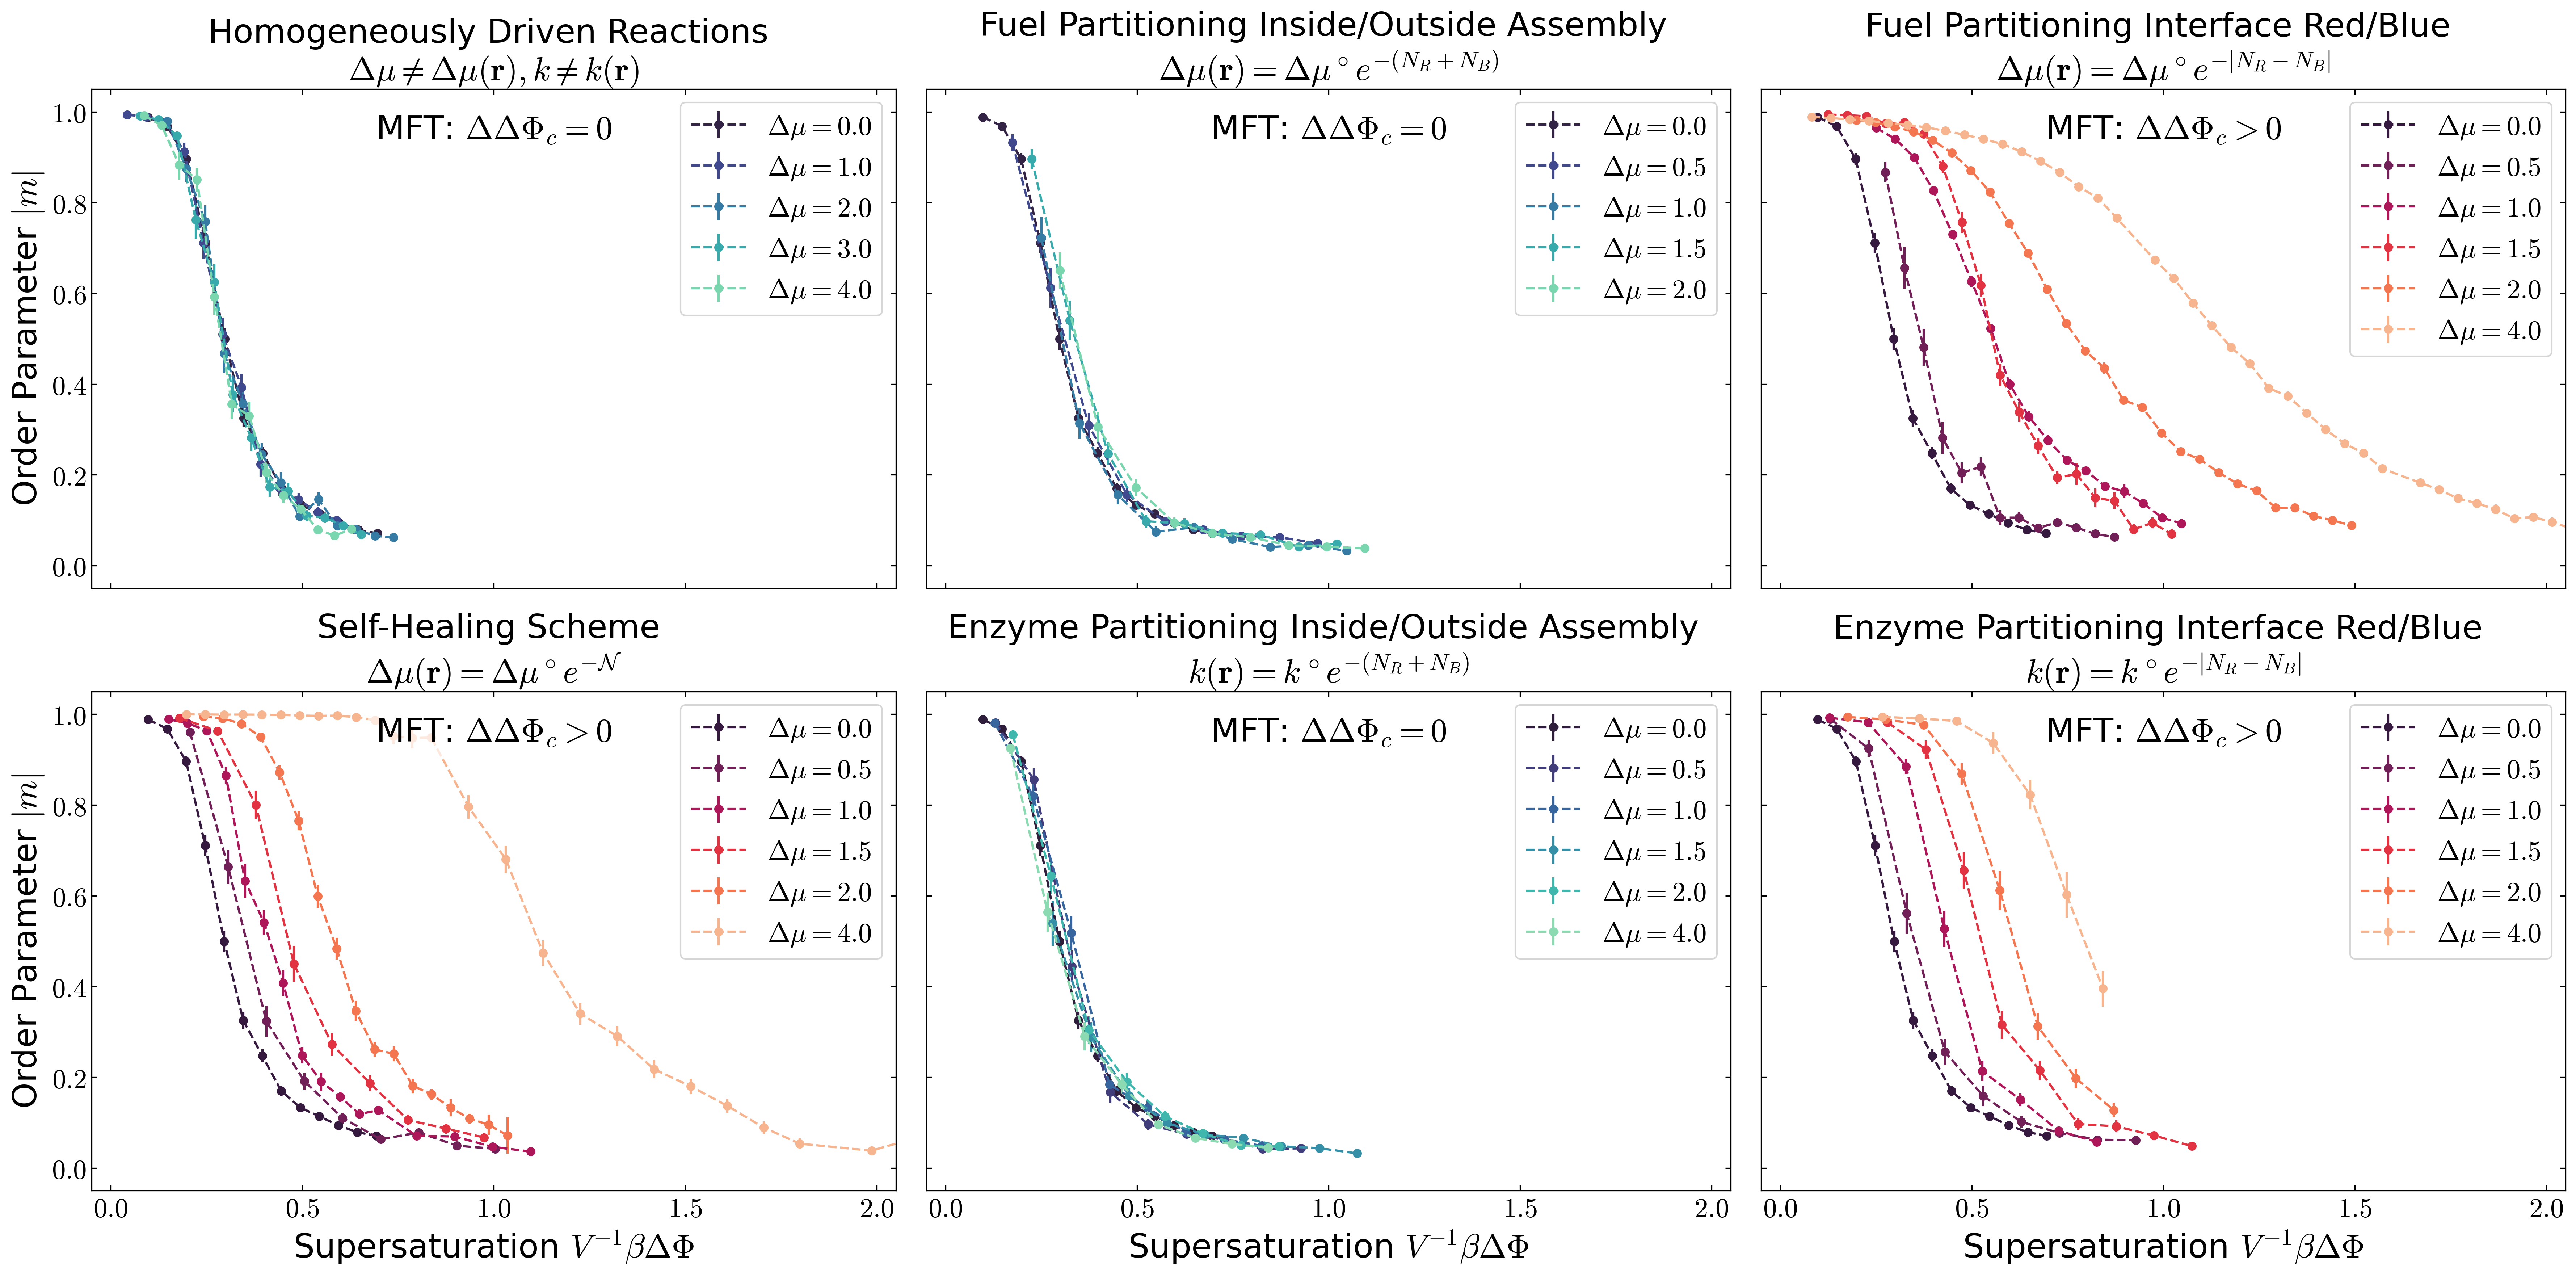

In [151]:
whiteout()

fig, ax = plt.subplots(2,3, figsize=(24,12), sharex=True, sharey=True)

ax[0,0].set_title(r'$\Delta \mu \neq \Delta \mu (\mathbf{r}), k \neq k(\mathbf{r})$', fontsize=22)    

ax[0,1].set_title(r'$\Delta \mu (\mathbf{r}) = \Delta \mu^\circ e^{-(N_R + N_B)}$', fontsize=22) 

ax[0,2].set_title(r'$\Delta \mu (\mathbf{r}) = \Delta \mu^\circ e^{-\vert N_R - N_B \vert}$', fontsize=22)  


ax[1,2].set_title(r'$k(\mathbf{r}) = k^\circ e^{-\vert N_R - N_B \vert}$', fontsize=22)  

ax[1,1].set_title(r'$k(\mathbf{r}) = k^\circ e^{-(N_R + N_B)}$', fontsize=22)  

ax[1,0].set_title(r'$\Delta \mu (\mathbf{r}) = \Delta \mu^\circ e^{-\mathcal{N}}$', fontsize=22)  


FS_LEGEND = 18
FS_TITLE = 22

ax[0,0].set_title('Homogeneously Driven Reactions \n' r'$\Delta \mu \neq \Delta \mu (\mathbf{r}), k \neq k(\mathbf{r})$', fontsize=22)    
ax[0,1].set_title('Fuel Partitioning Inside/Outside Assembly \n'r'$\Delta \mu (\mathbf{r}) = \Delta \mu^\circ e^{-(N_R + N_B)}$', fontsize=22)    
ax[0,2].set_title('Fuel Partitioning Interface Red/Blue \n'r'$\Delta \mu (\mathbf{r}) = \Delta \mu^\circ e^{-\vert N_R - N_B \vert}$', fontsize=22)    

ax[1,0].set_title('Self-Healing Scheme \n'r'$\Delta \mu (\mathbf{r}) = \Delta \mu^\circ e^{-\mathcal{N}}$', fontsize=22)    
ax[1,1].set_title('Enzyme Partitioning Inside/Outside Assembly \n'r'$k(\mathbf{r}) = k^\circ e^{-(N_R + N_B)}$', fontsize=22)    
ax[1,2].set_title('Enzyme Partitioning Interface Red/Blue \n'r'$k(\mathbf{r}) = k^\circ e^{-\vert N_R - N_B \vert}$', fontsize=22)    



PALETTE = 'rocket'

s6 = pd.read_csv("scheme6.csv")
colors = sns.color_palette(palette=PALETTE, n_colors=len(s6['drive'].unique()))
for drive in s6['drive'].unique():
    data = s6[s6['drive'] == drive]
    ax[0,2].errorbar(data["dphi"], data['m'], yerr=data['dm'], color=colors[list(s6['drive'].unique()).index(drive)],
                     ms=5, ls='--', marker='o', label=fr"$\Delta \mu = {drive}$")
    
ax[0,2].legend(fontsize=FS_LEGEND)


s7 = pd.read_csv("scheme7.csv")
colors = sns.color_palette(palette=PALETTE, n_colors=len(s7['drive'].unique()))
for drive in s7['drive'].unique():
    data = s7[s7['drive'] == drive]
    ax[1,0].errorbar(data["dphi"], data['m'], yerr=data['dm'], color=colors[list(s7['drive'].unique()).index(drive)],
                     ms=5, ls='--', marker='o', label=fr"$\Delta \mu = {drive}$")
    
ax[1,0].legend(fontsize=FS_LEGEND)



s93 = pd.read_csv("scheme93_data.csv")
colors = sns.color_palette(palette=PALETTE, n_colors=len(s93['drive'].unique()))
for drive in s93['drive'].unique():
    data = s93[s93['drive'] == drive]
    ax[1,2].errorbar(data["dphi"], data['m'], yerr=data['dm'], color=colors[list(s93['drive'].unique()).index(drive)],
                     ms=5, ls='--', marker='o', label=fr"$\Delta \mu = {drive}$")
ax[1,2].legend(fontsize=FS_LEGEND)


homo = pd.read_csv("homo_data.csv")
homo = homo[homo['drive'] < 4.5]
PALETTE = 'mako'
colors = sns.color_palette(palette=PALETTE, n_colors=len(homo['drive'].unique()))
for drive in homo['drive'].unique():
    data = homo[homo['drive'] == drive]
    ax[0,0].errorbar(data["dphi"], data['m'], yerr=data['dm'], color=colors[list(homo['drive'].unique()).index(drive)],
                     ms=5, ls='--', marker='o', label=fr"$\Delta \mu = {drive}$")
ax[0,0].legend(fontsize=FS_LEGEND)


s3data = pd.read_csv("scheme3_data.csv")
PALETTE = 'mako'
colors = sns.color_palette(palette=PALETTE, n_colors=len(s3data['drive'].unique()))
for drive in s3data['drive'].unique():
    data = s3data[s3data['drive'] == drive]
    ax[0,1].errorbar(data["dphi"], data['m'], yerr=data['dm'], color=colors[list(s3data['drive'].unique()).index(drive)],
                     ms=5, ls='--', marker='o', label=fr"$\Delta \mu = {drive}$")
ax[0,1].legend(fontsize=FS_LEGEND)


s91_data = pd.read_csv("scheme91_data.csv")
PALETTE = 'mako'
colors = sns.color_palette(palette=PALETTE, n_colors=len(s91_data['drive'].unique()))
for drive in s91_data['drive'].unique():
    data = s91_data[s91_data['drive'] == drive]
    ax[1,1].errorbar(data["dphi"], data['m'], yerr=data['dm'], color=colors[list(s91_data['drive'].unique()).index(drive)],
                     ms=5, ls='--', marker='o', label=fr"$\Delta \mu = {drive}$")
ax[1,1].legend(fontsize=FS_LEGEND)

for axis in ax.flat:
    axis.set_xlim(-0.05,2.05)
    axis.set_ylim(-0.05, 1.05)
    axis.set_xticks([0.0, 0.5, 1.0, 1.5, 2.0], [r"$0.0$", "$0.5$", "$1.0$", "$1.5$", "$2.0$"], fontsize=FS_LEGEND)
    axis.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0], [r"$0.0$", "$0.2$", "$0.4$", "$0.6$", "$0.8$", "$1.0$"], fontsize=FS_LEGEND)

ax[1,0].set_xlabel(r"Supersaturation $V^{-1} \beta \Delta \Phi$", fontsize=FS_TITLE)
ax[1,1].set_xlabel(r"Supersaturation $V^{-1} \beta \Delta \Phi$", fontsize=FS_TITLE)
ax[1,2].set_xlabel(r"Supersaturation $V^{-1} \beta \Delta \Phi$", fontsize=FS_TITLE)
ax[0,0].set_ylabel(r"Order Parameter $\vert m \vert$", fontsize=FS_TITLE)
ax[1,0].set_ylabel(r"Order Parameter $\vert m \vert$", fontsize=FS_TITLE)


ax[0,0].text(0.5, 0.9, r'MFT: $\Delta \Delta \Phi_c = 0$', transform=ax[0,0].transAxes, color='black', fontsize=FS_TITLE, ha='center',
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=5.0))

ax[0,1].text(0.5, 0.9, r'MFT: $\Delta \Delta \Phi_c = 0$', transform=ax[0,1].transAxes, color='black', fontsize=FS_TITLE, ha='center',
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=5.0))

ax[0,2].text(0.5, 0.9, r'MFT: $\Delta \Delta \Phi_c > 0$', transform=ax[0,2].transAxes, color='black', fontsize=FS_TITLE, ha='center',
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=5.0))

ax[1,0].text(0.5, 0.9, r'MFT: $\Delta \Delta \Phi_c > 0$', transform=ax[1,0].transAxes, color='black', fontsize=FS_TITLE, ha='center',
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=5.0))

ax[1,1].text(0.5, 0.9, r'MFT: $\Delta \Delta \Phi_c = 0$', transform=ax[1,1].transAxes, color='black', fontsize=FS_TITLE, ha='center',
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=5.0))

ax[1,2].text(0.5, 0.9, r'MFT: $\Delta \Delta \Phi_c > 0$', transform=ax[1,2].transAxes, color='black', fontsize=FS_TITLE, ha='center',
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=5.0))

plt.tight_layout()
plt.savefig('table_whiteout.pdf', bbox_inches='tight')

Blackout mode set.


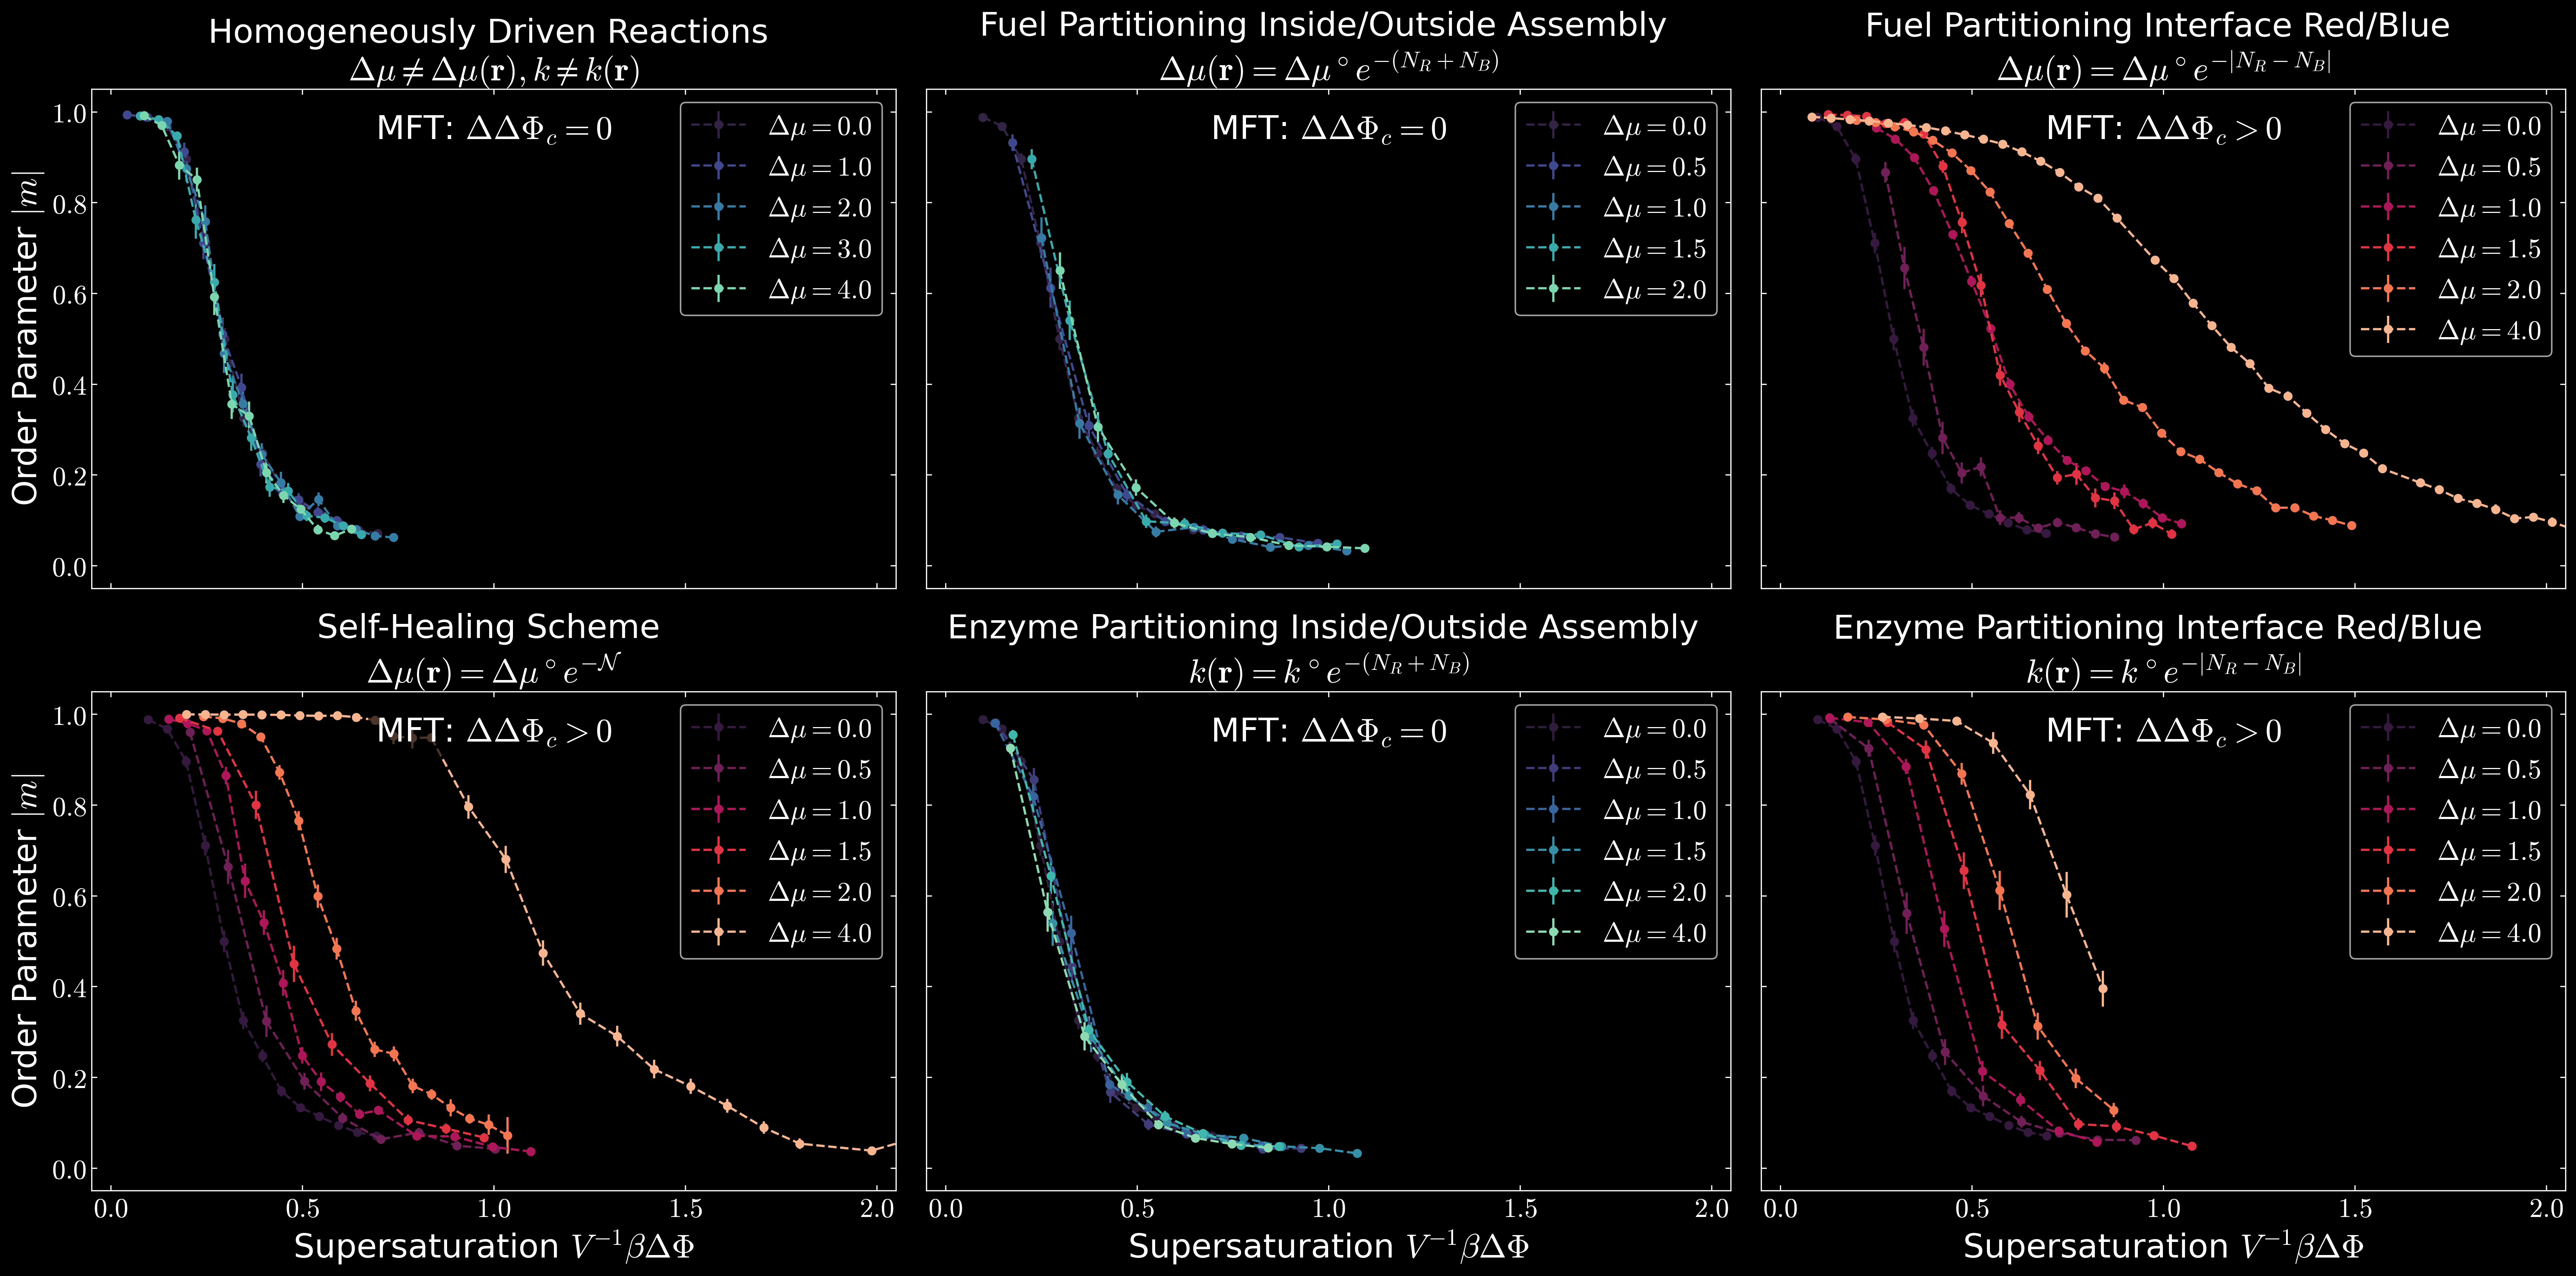

In [153]:
blackout()

fig, ax = plt.subplots(2,3, figsize=(24,12), sharex=True, sharey=True)


FS_LEGEND = 18
FS_TITLE = 22

ax[0,0].set_title('Homogeneously Driven Reactions \n' r'$\Delta \mu \neq \Delta \mu (\mathbf{r}), k \neq k(\mathbf{r})$', fontsize=22)    
ax[0,1].set_title('Fuel Partitioning Inside/Outside Assembly \n'r'$\Delta \mu (\mathbf{r}) = \Delta \mu^\circ e^{-(N_R + N_B)}$', fontsize=22)    
ax[0,2].set_title('Fuel Partitioning Interface Red/Blue \n'r'$\Delta \mu (\mathbf{r}) = \Delta \mu^\circ e^{-\vert N_R - N_B \vert}$', fontsize=22)    

ax[1,0].set_title('Self-Healing Scheme \n'r'$\Delta \mu (\mathbf{r}) = \Delta \mu^\circ e^{-\mathcal{N}}$', fontsize=22)    
ax[1,1].set_title('Enzyme Partitioning Inside/Outside Assembly \n'r'$k(\mathbf{r}) = k^\circ e^{-(N_R + N_B)}$', fontsize=22)    
ax[1,2].set_title('Enzyme Partitioning Interface Red/Blue \n'r'$k(\mathbf{r}) = k^\circ e^{-\vert N_R - N_B \vert}$', fontsize=22)    



PALETTE = 'rocket'

s6 = pd.read_csv("scheme6.csv")
colors = sns.color_palette(palette=PALETTE, n_colors=len(s6['drive'].unique()))
for drive in s6['drive'].unique():
    data = s6[s6['drive'] == drive]
    ax[0,2].errorbar(data["dphi"], data['m'], yerr=data['dm'], color=colors[list(s6['drive'].unique()).index(drive)],
                     ms=5, ls='--', marker='o', label=fr"$\Delta \mu = {drive}$")
    
ax[0,2].legend(fontsize=FS_LEGEND)


s7 = pd.read_csv("scheme7.csv")
colors = sns.color_palette(palette=PALETTE, n_colors=len(s7['drive'].unique()))
for drive in s7['drive'].unique():
    data = s7[s7['drive'] == drive]
    ax[1,0].errorbar(data["dphi"], data['m'], yerr=data['dm'], color=colors[list(s7['drive'].unique()).index(drive)],
                     ms=5, ls='--', marker='o', label=fr"$\Delta \mu = {drive}$")
    
ax[1,0].legend(fontsize=FS_LEGEND)



s93 = pd.read_csv("scheme93_data.csv")
colors = sns.color_palette(palette=PALETTE, n_colors=len(s93['drive'].unique()))
for drive in s93['drive'].unique():
    data = s93[s93['drive'] == drive]
    ax[1,2].errorbar(data["dphi"], data['m'], yerr=data['dm'], color=colors[list(s93['drive'].unique()).index(drive)],
                     ms=5, ls='--', marker='o', label=fr"$\Delta \mu = {drive}$")
ax[1,2].legend(fontsize=FS_LEGEND)


homo = pd.read_csv("homo_data.csv")
homo = homo[homo['drive'] < 4.5]
PALETTE = 'mako'
colors = sns.color_palette(palette=PALETTE, n_colors=len(homo['drive'].unique()))
for drive in homo['drive'].unique():
    data = homo[homo['drive'] == drive]
    ax[0,0].errorbar(data["dphi"], data['m'], yerr=data['dm'], color=colors[list(homo['drive'].unique()).index(drive)],
                     ms=5, ls='--', marker='o', label=fr"$\Delta \mu = {drive}$")
ax[0,0].legend(fontsize=FS_LEGEND)


s3data = pd.read_csv("scheme3_data.csv")
PALETTE = 'mako'
colors = sns.color_palette(palette=PALETTE, n_colors=len(s3data['drive'].unique()))
for drive in s3data['drive'].unique():
    data = s3data[s3data['drive'] == drive]
    ax[0,1].errorbar(data["dphi"], data['m'], yerr=data['dm'], color=colors[list(s3data['drive'].unique()).index(drive)],
                     ms=5, ls='--', marker='o', label=fr"$\Delta \mu = {drive}$")
ax[0,1].legend(fontsize=FS_LEGEND)


s91_data = pd.read_csv("scheme91_data.csv")
PALETTE = 'mako'
colors = sns.color_palette(palette=PALETTE, n_colors=len(s91_data['drive'].unique()))
for drive in s91_data['drive'].unique():
    data = s91_data[s91_data['drive'] == drive]
    ax[1,1].errorbar(data["dphi"], data['m'], yerr=data['dm'], color=colors[list(s91_data['drive'].unique()).index(drive)],
                     ms=5, ls='--', marker='o', label=fr"$\Delta \mu = {drive}$")
ax[1,1].legend(fontsize=FS_LEGEND)

for axis in ax.flat:
    axis.set_xlim(-0.05,2.05)
    axis.set_ylim(-0.05, 1.05)
    axis.set_xticks([0.0, 0.5, 1.0, 1.5, 2.0], [r"$0.0$", "$0.5$", "$1.0$", "$1.5$", "$2.0$"], fontsize=FS_LEGEND)
    axis.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0], [r"$0.0$", "$0.2$", "$0.4$", "$0.6$", "$0.8$", "$1.0$"], fontsize=FS_LEGEND)

ax[1,0].set_xlabel(r"Supersaturation $V^{-1} \beta \Delta \Phi$", fontsize=FS_TITLE)
ax[1,1].set_xlabel(r"Supersaturation $V^{-1} \beta \Delta \Phi$", fontsize=FS_TITLE)
ax[1,2].set_xlabel(r"Supersaturation $V^{-1} \beta \Delta \Phi$", fontsize=FS_TITLE)
ax[0,0].set_ylabel(r"Order Parameter $\vert m \vert$", fontsize=FS_TITLE)
ax[1,0].set_ylabel(r"Order Parameter $\vert m \vert$", fontsize=FS_TITLE)


ax[0,0].text(0.5, 0.9, r'MFT: $\Delta \Delta \Phi_c = 0$', transform=ax[0,0].transAxes, color='white', fontsize=FS_TITLE, ha='center',
             bbox=dict(facecolor='black', alpha=0.7, edgecolor='none', pad=5.0))

ax[0,1].text(0.5, 0.9, r'MFT: $\Delta \Delta \Phi_c = 0$', transform=ax[0,1].transAxes, color='w', fontsize=FS_TITLE, ha='center',
             bbox=dict(facecolor='black', alpha=0.7, edgecolor='none', pad=5.0))

ax[0,2].text(0.5, 0.9, r'MFT: $\Delta \Delta \Phi_c > 0$', transform=ax[0,2].transAxes, color='w', fontsize=FS_TITLE, ha='center',
             bbox=dict(facecolor='black', alpha=0.7, edgecolor='none', pad=5.0))

ax[1,0].text(0.5, 0.9, r'MFT: $\Delta \Delta \Phi_c > 0$', transform=ax[1,0].transAxes, color='w', fontsize=FS_TITLE, ha='center',
             bbox=dict(facecolor='black', alpha=0.7, edgecolor='none', pad=5.0))

ax[1,1].text(0.5, 0.9, r'MFT: $\Delta \Delta \Phi_c = 0$', transform=ax[1,1].transAxes, color='w', fontsize=FS_TITLE, ha='center',
             bbox=dict(facecolor='black', alpha=0.7, edgecolor='none', pad=5.0))

ax[1,2].text(0.5, 0.9, r'MFT: $\Delta \Delta \Phi_c > 0$', transform=ax[1,2].transAxes, color='w', fontsize=FS_TITLE, ha='center',
             bbox=dict(facecolor='black', alpha=0.7, edgecolor='none', pad=5.0))

plt.tight_layout()
plt.savefig('table_blackout.pdf', bbox_inches='tight')

Whiteout mode set.


/tmp/ipykernel_13588/3872023746.py:52: RuntimeWarning: divide by zero encountered in scalar divide
  m[i, j] = (Q_drazin[i, j] - Q_drazin[i, i]) / pi[i]
/tmp/ipykernel_13588/3872023746.py:52: RuntimeWarning: invalid value encountered in scalar divide
  m[i, j] = (Q_drazin[i, j] - Q_drazin[i, i]) / pi[i]
--- Logging error ---
Traceback (most recent call last):
  File "/home/moritz/miniforge3/envs/MLO/lib/python3.12/logging/__init__.py", line 1160, in emit
    msg = self.format(record)
          ^^^^^^^^^^^^^^^^^^^
  File "/home/moritz/miniforge3/envs/MLO/lib/python3.12/logging/__init__.py", line 999, in format
    return fmt.format(record)
           ^^^^^^^^^^^^^^^^^^
  File "/home/moritz/miniforge3/envs/MLO/lib/python3.12/logging/__init__.py", line 703, in format
    record.message = record.getMessage()
                     ^^^^^^^^^^^^^^^^^^^
  File "/home/moritz/miniforge3/envs/MLO/lib/python3.12/logging/__init__.py", line 392, in getMessage
    msg = msg % self.args
          ~~~~^

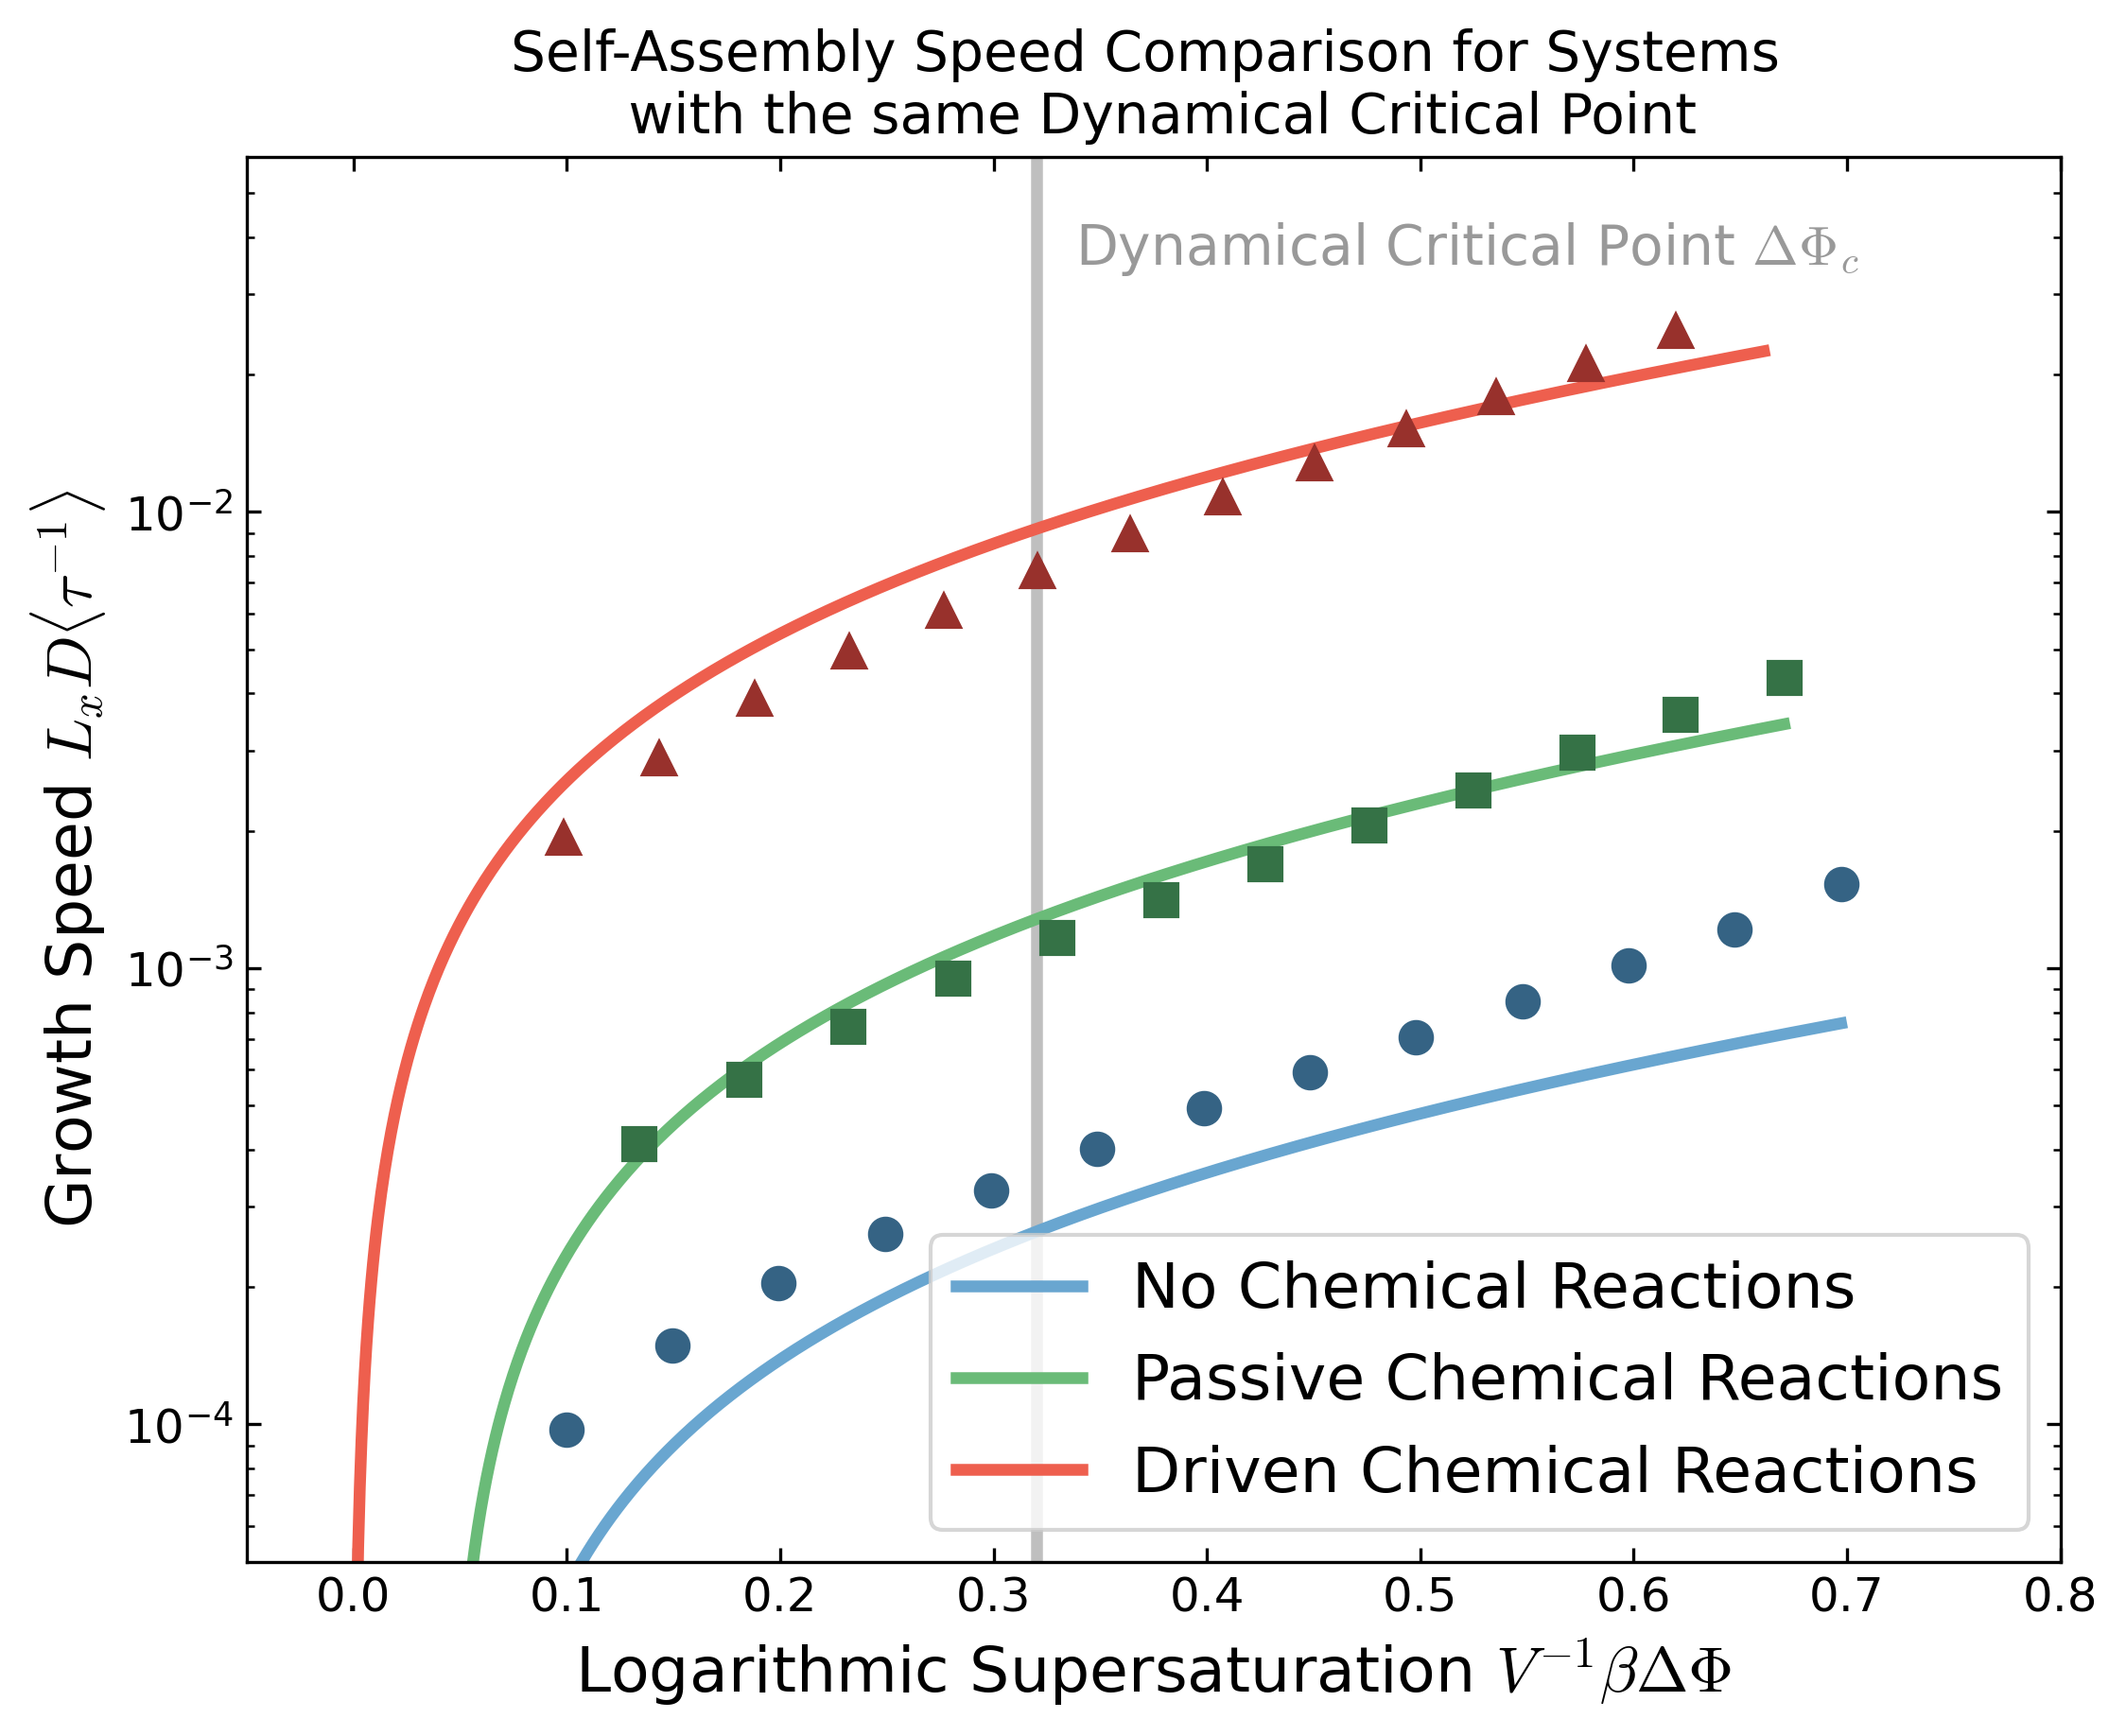

In [185]:
whiteout()

def calc_v_eff_from_flex(k, mu, df, dmu, eii, eij):
    U = np.exp(2*eii)
    U_2 = np.exp(2*eij)
    M = np.exp(dmu)
    F= np.exp(df)
    z = np.exp(mu)

# Set up the generator matrix

    L = np.array([
    [-2*(z + z*F), z, z*F, z, z*F],
    [U, -U-U*k*F*M, U*k*F*M, 0, 0],
    [1.0, k, -(k + 1), 0, 0],
    [U_2, 0.0, 0.0, -U_2*(1+F*M*k), U_2*F*M*k],
    [1.0, 0.0, 0.0, k, -(1+k)]
], dtype=np.float64)
    Q = L.T
    evals, evecs = np.linalg.eig(Q)
    evals = np.round(evals, decimals=10)
    evecs = np.round(evecs, decimals=10)
# Sort eigenvalues and eigenvectors by eigenvalue
    idx = np.argsort(evals)[::-1]
    evals = evals[idx]
    evecs = evecs[:, idx]

    # print("Eigenvalues:", evals)

# Make sure the first eigenvector is positive
    if evecs[0, 0] < 0:
        evecs[:, 0] = -evecs[:, 0]
# The stationary distribution is the eigenvector associated with eigenvalue 0
    pi = evecs[:, 0] / np.sum(evecs[:, 0])
    # print("Stationary distribution:", pi)

# Construct the Drazin psuedoinverse
    n = Q.shape[0]
    Z = np.zeros((n, n), dtype=np.float64)
    for i in range(n):
        if np.abs(evals[i]) < 1e-10:
            Z[i, i] = 0
        else:
            Z[i, i] = 1.0 / evals[i]

    Q_drazin = evecs @ Z @ np.linalg.inv(evecs)
    # print(Q_drazin)

    m = np.ones((n, n), dtype=np.float64)
    for i in range(n):
        for j in range(n):
            m[i, j] = (Q_drazin[i, j] - Q_drazin[i, i]) / pi[i]

    m = m.T

    v_e_to_active = 1./m[0, 1]
    v_active_to_e = 1./m[1, 0]

    v_eff = v_e_to_active - v_active_to_e

    return v_eff

# The DCP dphi is the same for all of them. So by finding mu(F,dphi_c) I should be able to get good results
# Solve for mu where dphi = 0.3

def find_mu_for_dphi(df, k,dmu, dphi_c=0.3):
    solutions = []
    for mu in np.linspace(-7,-2,10000):
        thermos = npa.Thermos(fres=df, dmu=dmu, k=k, method='HOMO')
        dphi = npa.calculate_dphi(mu, thermos)
        if np.isclose(dphi, dphi_c, atol=1e-3):
            solutions.append(mu)
    return np.average(solutions)

blues = sns.color_palette(palette='Blues_d')
reds = sns.color_palette(palette='Reds_d')
greens = sns.color_palette(palette='Greens_d')

plt.axvline(x=0.32, color='gray', linestyle='solid', alpha=0.5, lw=3)

FS_TITLE = 14
FS_LEGEND = 16

df = -20.0
k=0.0
dmu=0.0
dphis = []
v_effs = []
coex = -7.
mus = np.linspace(coex, coex + 0.7, 1000)
thermos_inert = npa.Thermos()
for mu in mus:
    dphi = npa.calculate_dphi(mu, thermos_inert)
    v_eff = calc_v_eff_from_flex(1.0, mu, df, dmu, -3.5, -2.0)
    dphis.append(dphi)
    v_effs.append(v_eff)
plt.plot(dphis, v_effs, lw=3, label=rf'No Chemical Reactions', color=blues[1])


base_path = Path("/media/moritz/PHD_PROJECT/NOV25/ML_F-20_D0_K0")
analysis_2 = npa.DynamicalOrderDisorder("no_inert_states", base_path)
thermos_for_inert = npa.Thermos()

data = analysis_2.get_data()
data = data.sort_values(by=["mu"])
data["dphi"] = npa.calculate_dphi(data["mu"], thermos_for_inert)
plt.plot(data['dphi'], data["growth_speed"], linestyle="none", ms=8, marker="o", color=blues[-2])



df = 2.0
k=1.0
dmu=0.0
dphis = []
v_effs = []
coex = -7.
mus = np.linspace(coex, coex + 0.7, 1000)
thermos_inert = npa.Thermos(fres=df, dmu=dmu, k=k, method='NODRIVE')
for mu in mus:
    dphi = npa.calculate_dphi(mu, thermos_inert)
    v_eff = calc_v_eff_from_flex(1.0, mu, df, dmu, -3.5, -2.0)
    dphis.append(dphi)
    v_effs.append(v_eff)
plt.plot(dphis, v_effs, lw=3, label=rf'Passive Chemical Reactions', color=greens[1])


base_path = Path("/media/moritz/PHD_PROJECT/NOV25/ML_F2_D0_K1")
analysis_2 = npa.DynamicalOrderDisorder("inert_states", base_path)
thermos_for_inert = npa.Thermos(fres=2.0)

data = analysis_2.get_data()
data = data.sort_values(by=["mu"])
data["dphi"] = npa.calculate_dphi(data["mu"], thermos_for_inert)
plt.plot(data['dphi'], data["growth_speed"],  linestyle="none", ms=8, marker="s", color=greens[-2])


df = 2.0
k=1.0
dmu=2.0
dphis = []
v_effs = []
coex = -5.2
mus = np.linspace(coex, coex + 0.85, 1000)
thermos_inert = npa.Thermos(fres=df, dmu=dmu, k=k, method='HOMO')
for mu in mus:
    dphi = npa.calculate_dphi(mu, thermos_inert)
    v_eff = calc_v_eff_from_flex(1.0, mu, df, dmu, -3.5, -2.0)
    dphis.append(dphi)
    v_effs.append(v_eff)
plt.plot(dphis, v_effs, lw=3, label=rf'Driven Chemical Reactions', color=reds[1])

base_path = Path("/media/moritz/PHD_PROJECT/NOV25/ML_F2_D2_K1")
analysis_2 = npa.DynamicalOrderDisorder("driven", base_path)
thermos_driven = npa.Thermos(fres=2.0, dmu=2.0, method='HOMO')

data = analysis_2.get_data()
data = data.sort_values(by=["mu"])
data["dphi"] = npa.calculate_dphi(data["mu"], thermos_driven)
plt.plot(data['dphi'], data["growth_speed"], linestyle="none", ms=8, marker="^", color=reds[-2])

plt.yscale("log")
plt.ylim(5e-5, 6e-2)

plt.xlim(-0.05, 0.8)
plt.ylabel(r"Growth Speed $L_x D \langle \tau^{-1} \rangle$", fontsize=FS_LEGEND)
plt.xlabel(r'Logarithmic Supersaturation $V^{-1}\beta \Delta \Phi$', fontsize=FS_LEGEND)
plt.legend(fontsize=FS_LEGEND)
plt.gcf().set_size_inches(8, 6)
plt.tight_layout()
plt.tick_params(axis='both', which='both', labelsize=12, direction='in')

plt.title('Self-Assembly Speed Comparison for Systems \n with the same Dynamical Critical Point', fontsize=FS_TITLE)

plt.text(0.45, 0.98, r'Dynamical Critical Point $\Delta \Phi_c$', transform=ax.transAxes, fontsize=FS_LEGEND-2, color='black',
         alpha=0.4,
         rotation=0)
plt.savefig("growth_speed_vs_dphi.pdf", bbox_inches='tight')

Plot defaults set.
Whiteout mode set.


/tmp/ipykernel_40409/3996111781.py:54: RuntimeWarning: divide by zero encountered in scalar divide
  m[i, j] = (Q_drazin[i, j] - Q_drazin[i, i]) / pi[i]
/tmp/ipykernel_40409/3996111781.py:54: RuntimeWarning: invalid value encountered in scalar divide
  m[i, j] = (Q_drazin[i, j] - Q_drazin[i, i]) / pi[i]
--- Logging error ---
Traceback (most recent call last):
  File "/home/moritz/miniforge3/envs/MLO/lib/python3.12/logging/__init__.py", line 1160, in emit
    msg = self.format(record)
          ^^^^^^^^^^^^^^^^^^^
  File "/home/moritz/miniforge3/envs/MLO/lib/python3.12/logging/__init__.py", line 999, in format
    return fmt.format(record)
           ^^^^^^^^^^^^^^^^^^
  File "/home/moritz/miniforge3/envs/MLO/lib/python3.12/logging/__init__.py", line 703, in format
    record.message = record.getMessage()
                     ^^^^^^^^^^^^^^^^^^^
  File "/home/moritz/miniforge3/envs/MLO/lib/python3.12/logging/__init__.py", line 392, in getMessage
    msg = msg % self.args
          ~~~~^

AttributeError: 'numpy.ndarray' object has no attribute 'transAxes'

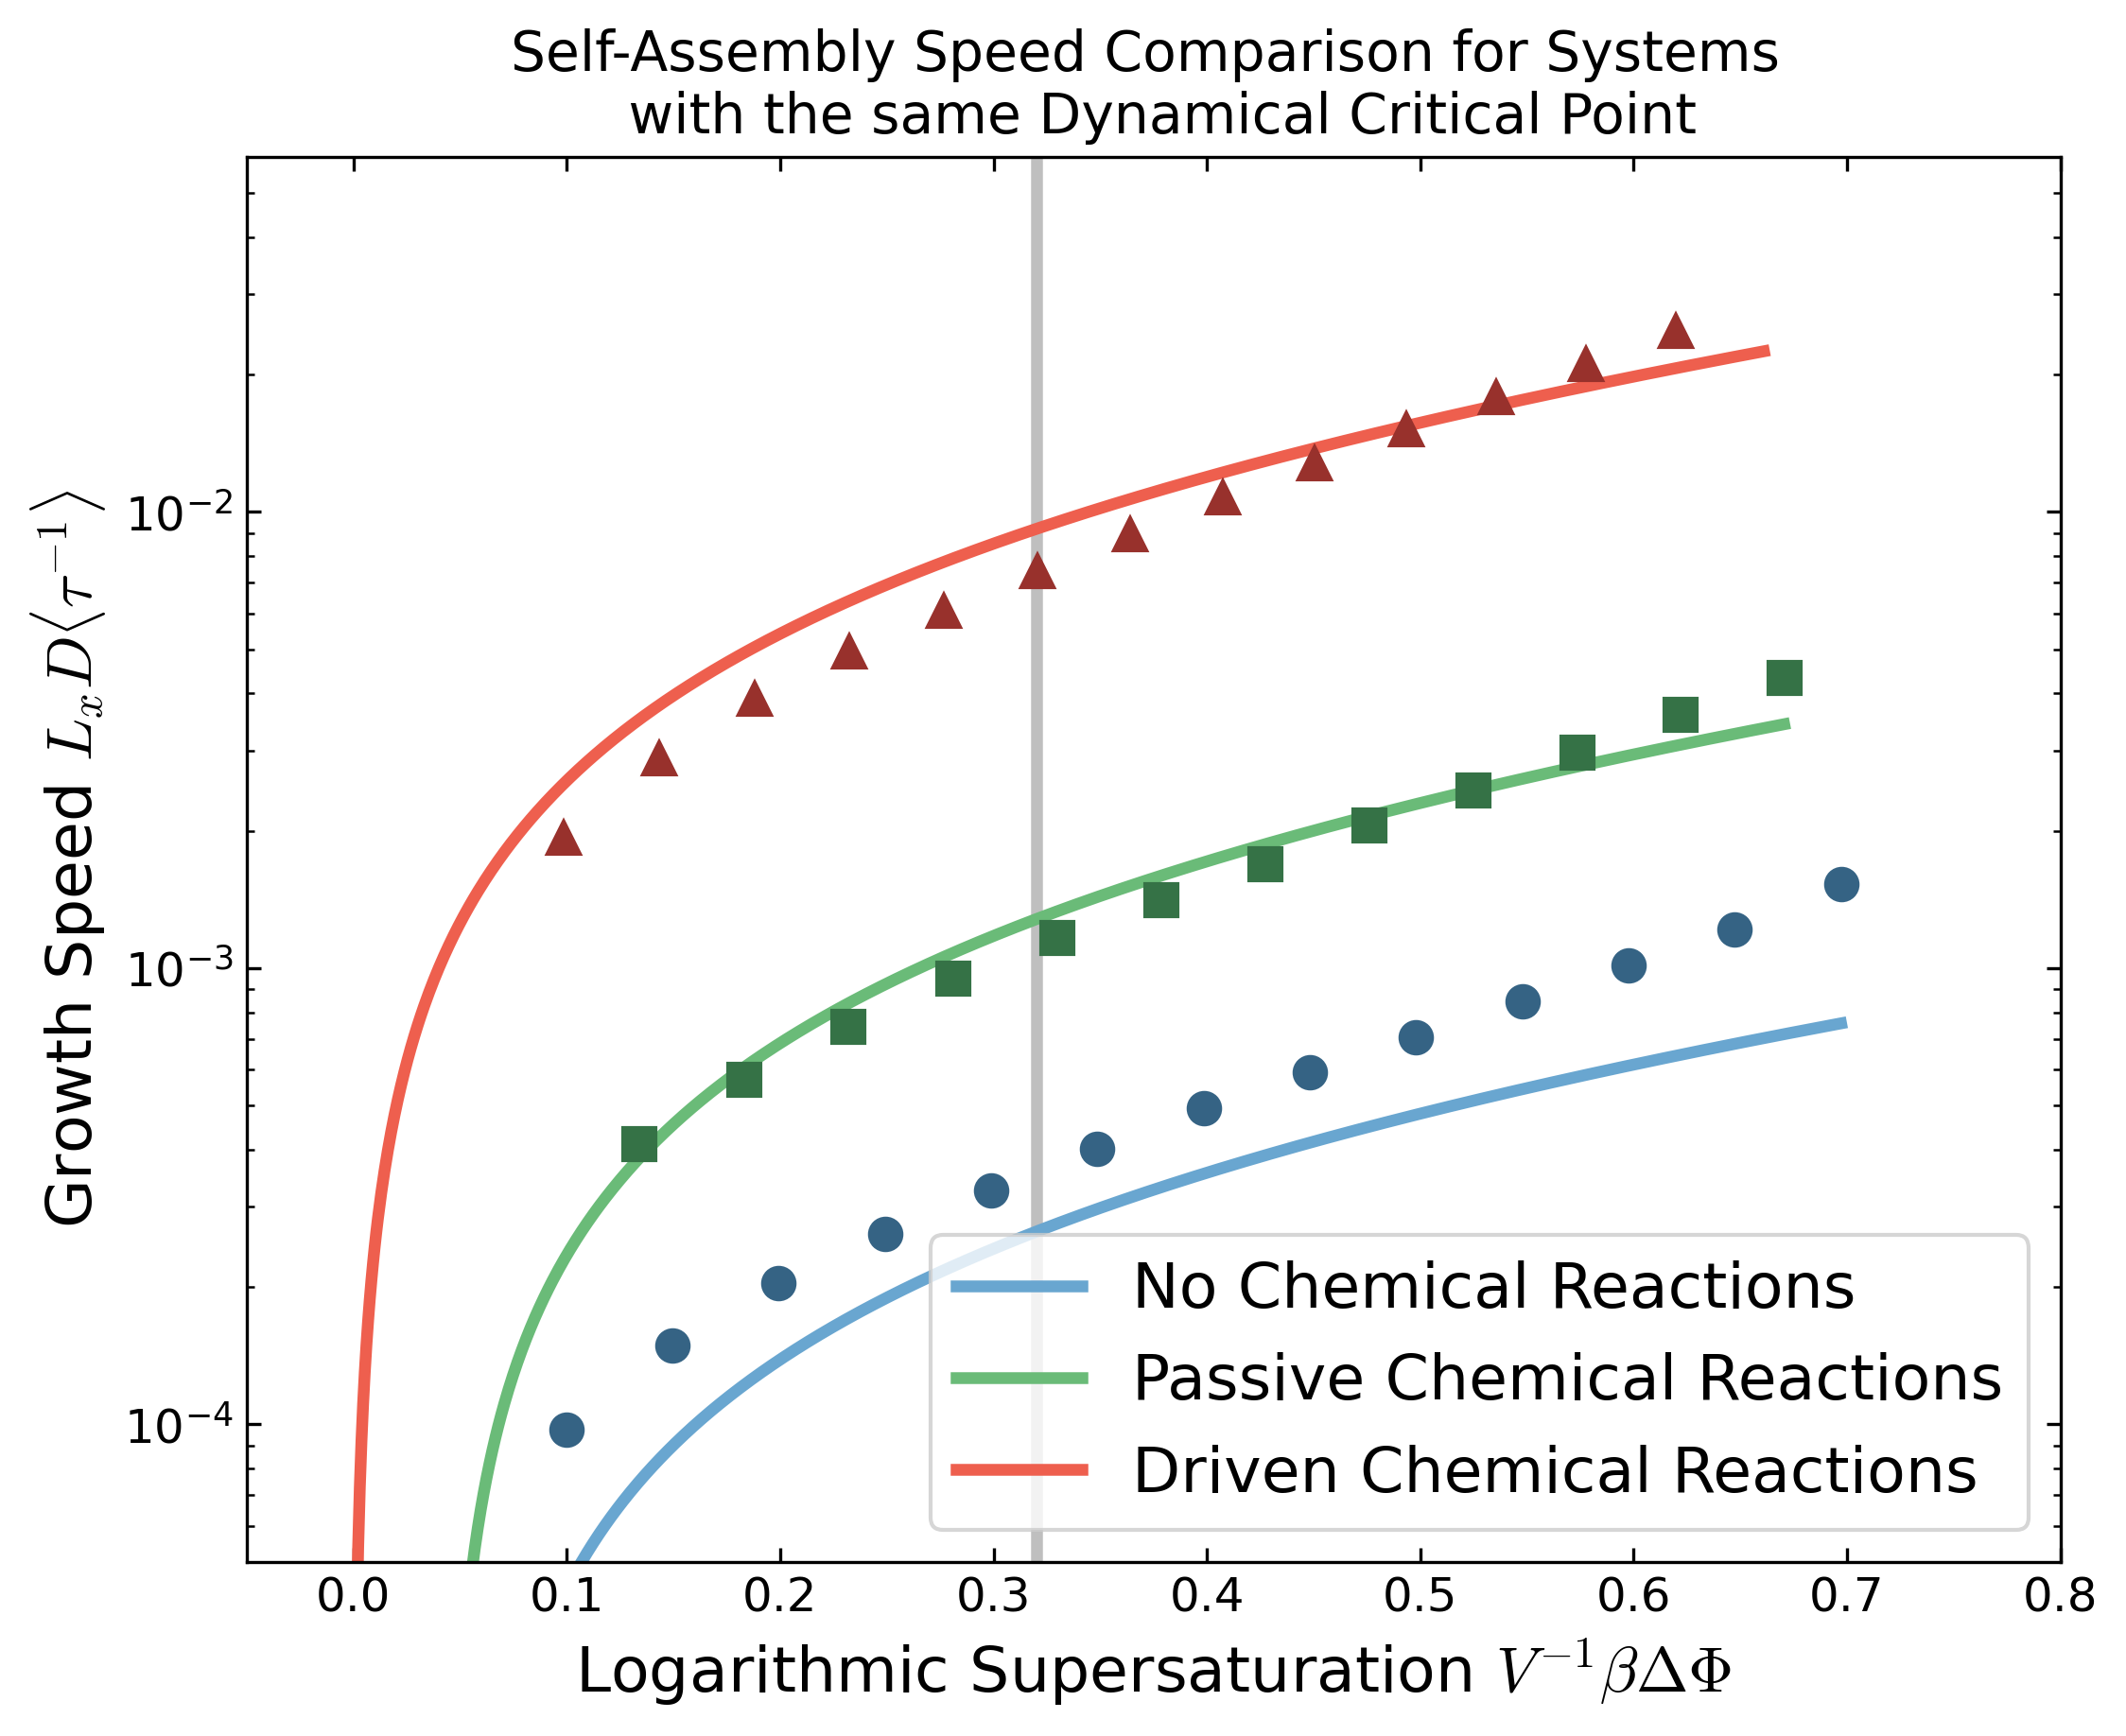

In [26]:
from plot_defaults import *
set_plot_defaults()
whiteout()

def calc_v_eff_from_flex(k, mu, df, dmu, eii, eij):
    U = np.exp(2*eii)
    U_2 = np.exp(2*eij)
    M = np.exp(dmu)
    F= np.exp(df)
    z = np.exp(mu)

# Set up the generator matrix

    L = np.array([
    [-2*(z + z*F), z, z*F, z, z*F],
    [U, -U-U*k*F*M, U*k*F*M, 0, 0],
    [1.0, k, -(k + 1), 0, 0],
    [U_2, 0.0, 0.0, -U_2*(1+F*M*k), U_2*F*M*k],
    [1.0, 0.0, 0.0, k, -(1+k)]
], dtype=np.float64)
    Q = L.T
    evals, evecs = np.linalg.eig(Q)
    evals = np.round(evals, decimals=10)
    evecs = np.round(evecs, decimals=10)
# Sort eigenvalues and eigenvectors by eigenvalue
    idx = np.argsort(evals)[::-1]
    evals = evals[idx]
    evecs = evecs[:, idx]

    # print("Eigenvalues:", evals)

# Make sure the first eigenvector is positive
    if evecs[0, 0] < 0:
        evecs[:, 0] = -evecs[:, 0]
# The stationary distribution is the eigenvector associated with eigenvalue 0
    pi = evecs[:, 0] / np.sum(evecs[:, 0])
    # print("Stationary distribution:", pi)

# Construct the Drazin psuedoinverse
    n = Q.shape[0]
    Z = np.zeros((n, n), dtype=np.float64)
    for i in range(n):
        if np.abs(evals[i]) < 1e-10:
            Z[i, i] = 0
        else:
            Z[i, i] = 1.0 / evals[i]

    Q_drazin = evecs @ Z @ np.linalg.inv(evecs)
    # print(Q_drazin)

    m = np.ones((n, n), dtype=np.float64)
    for i in range(n):
        for j in range(n):
            m[i, j] = (Q_drazin[i, j] - Q_drazin[i, i]) / pi[i]

    m = m.T

    v_e_to_active = 1./m[0, 1]
    v_active_to_e = 1./m[1, 0]

    v_eff = v_e_to_active - v_active_to_e

    return v_eff

# The DCP dphi is the same for all of them. So by finding mu(F,dphi_c) I should be able to get good results
# Solve for mu where dphi = 0.3

def find_mu_for_dphi(df, k,dmu, dphi_c=0.3):
    solutions = []
    for mu in np.linspace(-7,-2,10000):
        thermos = npa.Thermos(fres=df, dmu=dmu, k=k, method='HOMO')
        dphi = npa.calculate_dphi(mu, thermos)
        if np.isclose(dphi, dphi_c, atol=1e-3):
            solutions.append(mu)
    return np.average(solutions)

blues = sns.color_palette(palette='Blues_d')
reds = sns.color_palette(palette='Reds_d')
greens = sns.color_palette(palette='Greens_d')

plt.axvline(x=0.32, color='gray', linestyle='solid', alpha=0.5, lw=3)

FS_TITLE = 14
FS_LEGEND = 16

df = -20.0
k=0.0
dmu=0.0
dphis = []
v_effs = []
coex = -7.
mus = np.linspace(coex, coex + 0.7, 1000)
thermos_inert = npa.Thermos()
for mu in mus:
    dphi = npa.calculate_dphi(mu, thermos_inert)
    v_eff = calc_v_eff_from_flex(1.0, mu, df, dmu, -3.5, -2.0)
    dphis.append(dphi)
    v_effs.append(v_eff)
plt.plot(dphis, v_effs, lw=3, label=rf'No Chemical Reactions', color=blues[1])


base_path = Path("/media/moritz/PHD_PROJECT/NOV25/ML_F-20_D0_K0")
analysis_2 = npa.DynamicalOrderDisorder("no_inert_states", base_path)
thermos_for_inert = npa.Thermos()

data = analysis_2.get_data()
data = data.sort_values(by=["mu"])
data["dphi"] = npa.calculate_dphi(data["mu"], thermos_for_inert)
plt.plot(data['dphi'], data["growth_speed"], linestyle="none", ms=8, marker="o", color=blues[-2])

no_chemical_reactions_numerical = pd.DataFrame.from_dict(data)
no_chemical_reactions_numerical.to_csv("no_chemical_reactions_numerical.csv", index=False)
no_chemical_reactions_flex = pd.DataFrame.from_dict({'dphi': dphis, 'v_eff': v_effs})
no_chemical_reactions_flex.to_csv("no_chemical_reactions_flex.csv", index=False)


df = 2.0
k=1.0
dmu=0.0
dphis = []
v_effs = []
coex = -7.
mus = np.linspace(coex, coex + 0.7, 1000)
thermos_inert = npa.Thermos(fres=df, dmu=dmu, k=k, method='NODRIVE')
for mu in mus:
    dphi = npa.calculate_dphi(mu, thermos_inert)
    v_eff = calc_v_eff_from_flex(1.0, mu, df, dmu, -3.5, -2.0)
    dphis.append(dphi)
    v_effs.append(v_eff)
plt.plot(dphis, v_effs, lw=3, label=rf'Passive Chemical Reactions', color=greens[1])


base_path = Path("/media/moritz/PHD_PROJECT/NOV25/ML_F2_D0_K1")
analysis_2 = npa.DynamicalOrderDisorder("inert_states", base_path)
thermos_for_inert = npa.Thermos(fres=2.0)

data = analysis_2.get_data()
data = data.sort_values(by=["mu"])
data["dphi"] = npa.calculate_dphi(data["mu"], thermos_for_inert)
plt.plot(data['dphi'], data["growth_speed"],  linestyle="none", ms=8, marker="s", color=greens[-2])

no_chemical_reactions_numerical = pd.DataFrame.from_dict(data)
no_chemical_reactions_numerical.to_csv("df2_numerical.csv", index=False)
no_chemical_reactions_flex = pd.DataFrame.from_dict({'dphi': dphis, 'v_eff': v_effs})
no_chemical_reactions_flex.to_csv("df2_flex.csv", index=False)

df = 2.0
k=1.0
dmu=2.0
dphis = []
v_effs = []
coex = -5.2
mus = np.linspace(coex, coex + 0.85, 1000)
thermos_inert = npa.Thermos(fres=df, dmu=dmu, k=k, method='HOMO')
for mu in mus:
    dphi = npa.calculate_dphi(mu, thermos_inert)
    v_eff = calc_v_eff_from_flex(1.0, mu, df, dmu, -3.5, -2.0)
    dphis.append(dphi)
    v_effs.append(v_eff)
plt.plot(dphis, v_effs, lw=3, label=rf'Driven Chemical Reactions', color=reds[1])

base_path = Path("/media/moritz/PHD_PROJECT/NOV25/ML_F2_D2_K1")
analysis_2 = npa.DynamicalOrderDisorder("driven", base_path)
thermos_driven = npa.Thermos(fres=2.0, dmu=2.0, method='HOMO')

data = analysis_2.get_data()
data = data.sort_values(by=["mu"])
data["dphi"] = npa.calculate_dphi(data["mu"], thermos_driven)
plt.plot(data['dphi'], data["growth_speed"], linestyle="none", ms=8, marker="^", color=reds[-2])

no_chemical_reactions_numerical = pd.DataFrame.from_dict(data)
no_chemical_reactions_numerical.to_csv("df2_dmu2_numerical.csv", index=False)
no_chemical_reactions_flex = pd.DataFrame.from_dict({'dphi': dphis, 'v_eff': v_effs})
no_chemical_reactions_flex.to_csv("df2_dmu2_flex.csv", index=False)

plt.yscale("log")
plt.ylim(5e-5, 6e-2)

plt.xlim(-0.05, 0.8)
plt.ylabel(r"Growth Speed $L_x D \langle \tau^{-1} \rangle$", fontsize=FS_LEGEND)
plt.xlabel(r'Logarithmic Supersaturation $V^{-1}\beta \Delta \Phi$', fontsize=FS_LEGEND)
plt.legend(fontsize=FS_LEGEND)
plt.gcf().set_size_inches(8, 6)
plt.tight_layout()
plt.tick_params(axis='both', which='both', labelsize=12, direction='in')

plt.title('Self-Assembly Speed Comparison for Systems \n with the same Dynamical Critical Point', fontsize=FS_TITLE)

plt.text(0.45, 0.98, r'Dynamical Critical Point $\Delta \Phi_c$', transform=ax.transAxes, fontsize=FS_LEGEND-2, color='black',
         alpha=0.4,
         rotation=0)

/tmp/ipykernel_40409/400994953.py:54: RuntimeWarning: divide by zero encountered in scalar divide
  m[i, j] = (Q_drazin[i, j] - Q_drazin[i, i]) / pi[i]
/tmp/ipykernel_40409/400994953.py:54: RuntimeWarning: invalid value encountered in scalar divide
  m[i, j] = (Q_drazin[i, j] - Q_drazin[i, i]) / pi[i]
--- Logging error ---
Traceback (most recent call last):
  File "/home/moritz/miniforge3/envs/MLO/lib/python3.12/logging/__init__.py", line 1160, in emit
    msg = self.format(record)
          ^^^^^^^^^^^^^^^^^^^
  File "/home/moritz/miniforge3/envs/MLO/lib/python3.12/logging/__init__.py", line 999, in format
    return fmt.format(record)
           ^^^^^^^^^^^^^^^^^^
  File "/home/moritz/miniforge3/envs/MLO/lib/python3.12/logging/__init__.py", line 703, in format
    record.message = record.getMessage()
                     ^^^^^^^^^^^^^^^^^^^
  File "/home/moritz/miniforge3/envs/MLO/lib/python3.12/logging/__init__.py", line 392, in getMessage
    msg = msg % self.args
          ~~~~^~~

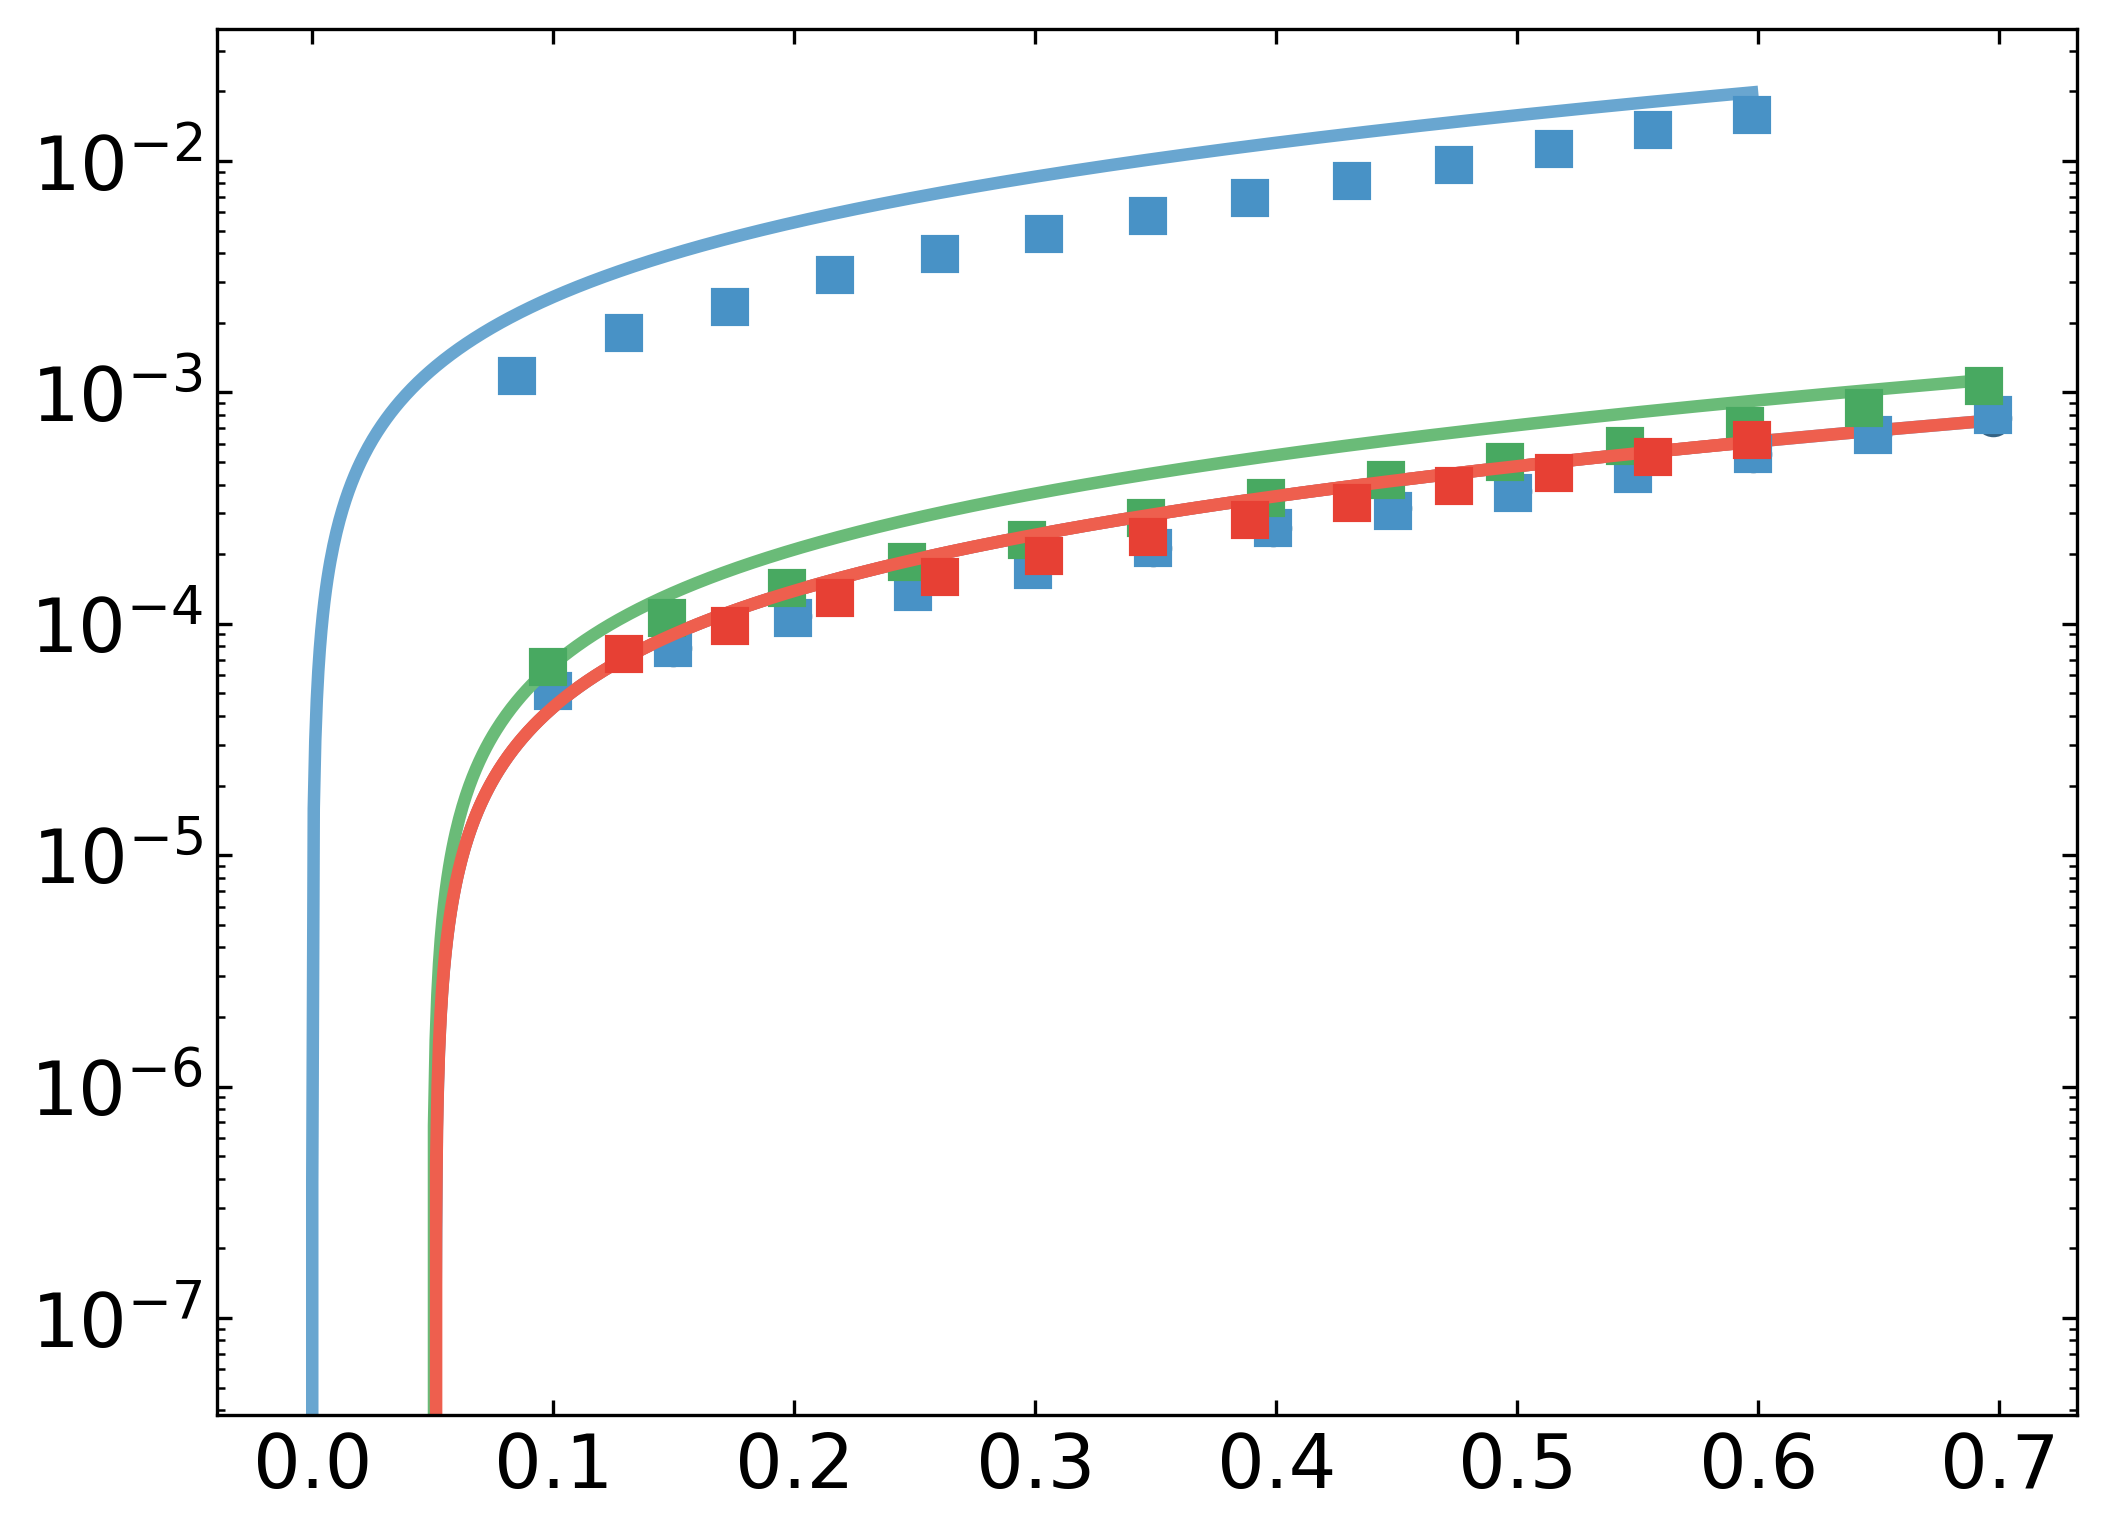

In [16]:
df = -20.0
k=0.0
dmu=0.0
dphis = []
v_effs = []
coex = -7.
mus = np.linspace(coex, coex + 0.7, 1000)
thermos_inert = npa.Thermos()
for mu in mus:
    dphi = npa.calculate_dphi(mu, thermos_inert)
    v_eff = calc_v_eff_from_flex(k, mu, df, dmu, -3.5, -2.0)
    dphis.append(dphi)
    v_effs.append(v_eff)
plt.plot(dphis, v_effs, lw=3, label=rf'No Chemical Reactions', color=blues[1])


base_path = Path("/media/moritz/PHD_PROJECT/DEC25/40_160_DFS/F-20_K0")
analysis_2 = npa.DynamicalOrderDisorder("no_inert_states", base_path)
thermos_for_inert = npa.Thermos()

data = analysis_2.get_data()
data = data.sort_values(by=["mu"])
data["dphi"] = npa.calculate_dphi(data["mu"], thermos_for_inert)
plt.plot(data['dphi'], data["growth_speed"], linestyle="none", ms=8, marker="o", color=blues[-2])

no_chemical_reactions_numerical = pd.DataFrame.from_dict(data)
no_chemical_reactions_numerical.to_csv("no_chemical_reactions_numerical160.csv", index=False)
no_chemical_reactions_flex = pd.DataFrame.from_dict({'dphi': dphis, 'v_eff': v_effs})
no_chemical_reactions_flex.to_csv("no_chemical_reactions_flex160.csv", index=False)

df = 0.0
k=0.0
dmu=0.0
dphis = []
v_effs = []
coex = -7.
mus = np.linspace(coex, coex + 0.7, 1000)
thermos_inert = npa.Thermos(fres=df, dmu=dmu, k=k)
for mu in mus:
    dphi = npa.calculate_dphi(mu, thermos_inert)
    v_eff = calc_v_eff_from_flex(k, mu, df, dmu, -3.5, -2.0)
    dphis.append(dphi)
    v_effs.append(v_eff)
plt.plot(dphis, v_effs, lw=3, label=rf'No Chemical Reactions', color=reds[1])


base_path = Path("/media/moritz/PHD_PROJECT/DEC25/40_160_DFS/F0_K0")
analysis_2 = npa.DynamicalOrderDisorder("no_inert_states", base_path)
thermos_for_inert = npa.Thermos()

data = analysis_2.get_data()
data = data.sort_values(by=["mu"])
data["dphi"] = npa.calculate_dphi(data["mu"], thermos_for_inert)
plt.plot(data['dphi'], data["growth_speed"], linestyle="none", ms=8, marker="s", color=blues[-4])

no_chemical_reactions_numerical = pd.DataFrame.from_dict(data)
no_chemical_reactions_numerical.to_csv("f0k0.csv", index=False)
no_chemical_reactions_flex = pd.DataFrame.from_dict({'dphi': dphis, 'v_eff': v_effs})
no_chemical_reactions_flex.to_csv("f0k0_flex.csv", index=False)



df = 0.0
k=1.0
dmu=0.0
dphis = []
v_effs = []
coex = -7.
mus = np.linspace(coex, coex + 0.7, 1000)
thermos_inert = npa.Thermos(fres=df, dmu=dmu, k=k)
for mu in mus:
    dphi = npa.calculate_dphi(mu, thermos_inert)
    v_eff = calc_v_eff_from_flex(k, mu, df, dmu, -3.5, -2.0)
    dphis.append(dphi)
    v_effs.append(v_eff)
plt.plot(dphis, v_effs, lw=3, label=rf'No Chemical Reactions', color=greens[1])


base_path = Path("/media/moritz/PHD_PROJECT/DEC25/40_160_DFS/F0_K1")
analysis_2 = npa.DynamicalOrderDisorder("no_inert_states", base_path)
thermos_for_inert = npa.Thermos(fres=df, dmu=dmu, k=k)

data = analysis_2.get_data()
data = data.sort_values(by=["mu"])
data["dphi"] = npa.calculate_dphi(data["mu"], thermos_for_inert)
plt.plot(data['dphi'], data["growth_speed"], linestyle="none", ms=8, marker="s", color=greens[-4])

no_chemical_reactions_numerical = pd.DataFrame.from_dict(data)
no_chemical_reactions_numerical.to_csv("f0k1.csv", index=False)
no_chemical_reactions_flex = pd.DataFrame.from_dict({'dphi': dphis, 'v_eff': v_effs})
no_chemical_reactions_flex.to_csv("f0k1_flex.csv", index=False)


df = 4.0
k=0.0
dmu=0.0
dphis = []
v_effs = []
coex = -6.9
mus = np.linspace(coex, coex + 0.7, 1000)
thermos_inert = npa.Thermos(fres=df, dmu=dmu, k=k)
for mu in mus:
    dphi = npa.calculate_dphi(mu, thermos_inert)
    v_eff = calc_v_eff_from_flex(k, mu, df, dmu, -3.5, -2.0)
    dphis.append(dphi)
    v_effs.append(v_eff)
plt.plot(dphis, v_effs, lw=3, label=rf'No Chemical Reactions', color=reds[1])


base_path = Path("/media/moritz/PHD_PROJECT/DEC25/40_160_DFS/F4_K0")
analysis_2 = npa.DynamicalOrderDisorder("no_inert_states", base_path)
thermos_for_inert = npa.Thermos(fres=df, dmu=dmu, k=k)

data = analysis_2.get_data()
data = data.sort_values(by=["mu"])
data["dphi"] = npa.calculate_dphi(data["mu"], thermos_for_inert)
plt.plot(data['dphi'], data["growth_speed"], linestyle="none", ms=8, marker="s", color=reds[-4])

no_chemical_reactions_numerical = pd.DataFrame.from_dict(data)
no_chemical_reactions_numerical.to_csv("f4k0.csv", index=False)
no_chemical_reactions_flex = pd.DataFrame.from_dict({'dphi': dphis, 'v_eff': v_effs})
no_chemical_reactions_flex.to_csv("f4k0_flex.csv", index=False)


df = 4.0
k=1.0
dmu=0.0
dphis = []
v_effs = []
coex = -6.9
mus = np.linspace(coex, coex + 0.7, 1000)
thermos_inert = npa.Thermos(fres=df, dmu=dmu, k=k)
for mu in mus:
    dphi = npa.calculate_dphi(mu, thermos_inert)
    v_eff = calc_v_eff_from_flex(1.0, mu, df, dmu, -3.5, -2.0)
    dphis.append(dphi)
    v_effs.append(v_eff)
plt.plot(dphis, v_effs, lw=3, label=rf'No Chemical Reactions', color=blues[1])


base_path = Path("/media/moritz/PHD_PROJECT/DEC25/40_160_DFS/F4_K1")
analysis_2 = npa.DynamicalOrderDisorder("no_inert_states", base_path)
thermos_for_inert = npa.Thermos(fres=df, dmu=dmu, k=k)

data = analysis_2.get_data()
data = data.sort_values(by=["mu"])
data["dphi"] = npa.calculate_dphi(data["mu"], thermos_for_inert)
plt.plot(data['dphi'], data["growth_speed"], linestyle="none", ms=8, marker="s", color=blues[-4])

no_chemical_reactions_numerical = pd.DataFrame.from_dict(data)
no_chemical_reactions_numerical.to_csv("f4k1.csv", index=False)
no_chemical_reactions_flex = pd.DataFrame.from_dict({'dphi': dphis, 'v_eff': v_effs})
no_chemical_reactions_flex.to_csv("f4k1_flex.csv", index=False)



plt.yscale("log")

Whiteout mode set.


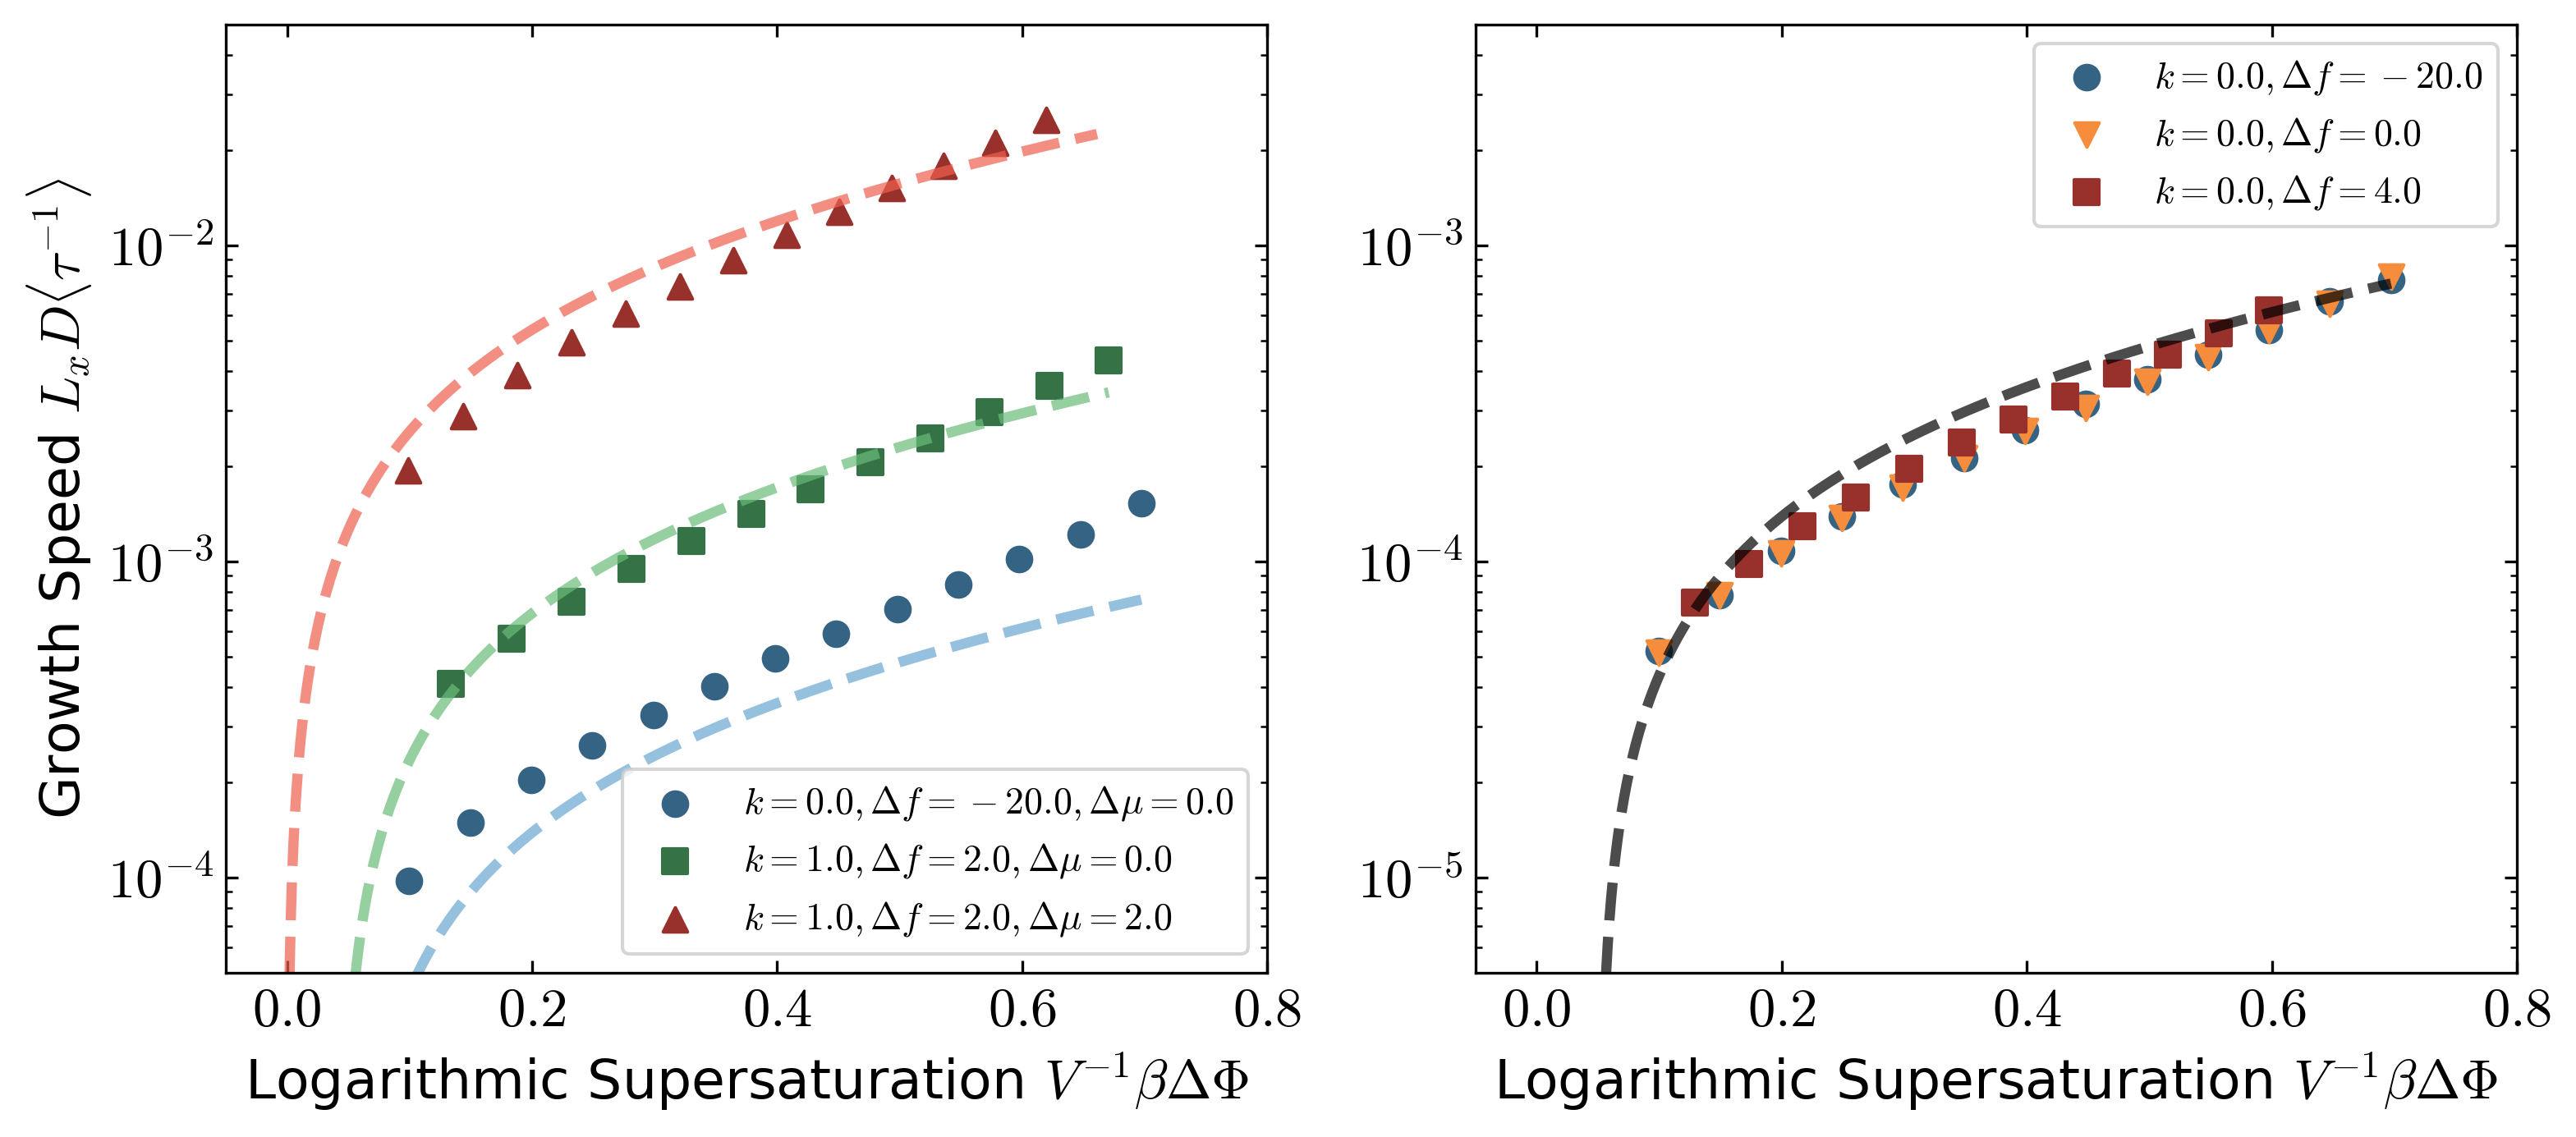

In [62]:
fig, ax = plt.subplots(1,2, figsize=(12,5))
whiteout()


# Left plot:

no_chemical_reactions_numerical = pd.read_csv("/media/moritz/PHD_PROJECT/DEC25/80x320/no_chemical_reactions_numerical.csv")
no_chemical_reactions_flex = pd.read_csv("/media/moritz/PHD_PROJECT/DEC25/80x320/no_chemical_reactions_flex.csv")

ax[0].plot(no_chemical_reactions_flex['dphi'], no_chemical_reactions_flex['v_eff'], lw=3,  color=blues[1], alpha=0.7, ls='dashed')
ax[0].scatter(no_chemical_reactions_numerical['dphi'], no_chemical_reactions_numerical['growth_speed'], s=50, marker='o', color=blues[-2], label=rf'$k = 0.0, \Delta f = -20.0, \Delta \mu = 0.0$')


no_chemical_reactions_numerical = pd.read_csv("/media/moritz/PHD_PROJECT/DEC25/80x320/df2_numerical.csv")
no_chemical_reactions_flex = pd.read_csv("/media/moritz/PHD_PROJECT/DEC25/80x320/df2_flex.csv")

ax[0].plot(no_chemical_reactions_flex['dphi'], no_chemical_reactions_flex['v_eff'], lw=3, color=greens[1], alpha=0.7, ls='dashed')
ax[0].scatter(no_chemical_reactions_numerical['dphi'], no_chemical_reactions_numerical['growth_speed'], s=50, marker='s', color=greens[-2], label=rf'$k = 1.0, \Delta f = 2.0, \Delta \mu = 0.0$')


no_chemical_reactions_numerical = pd.read_csv("/media/moritz/PHD_PROJECT/DEC25/80x320/df2_dmu2_numerical.csv")
no_chemical_reactions_flex = pd.read_csv("/media/moritz/PHD_PROJECT/DEC25/80x320/df2_dmu2_flex.csv")

ax[0].plot(no_chemical_reactions_flex['dphi'], no_chemical_reactions_flex['v_eff'], lw=3, color=reds[1], alpha=0.7, ls='dashed')
ax[0].scatter(no_chemical_reactions_numerical['dphi'], no_chemical_reactions_numerical['growth_speed'], s=50, marker='^', color=reds[-2], label=rf'$k = 1.0, \Delta f = 2.0, \Delta \mu = 2.0$')


ax[0].set_yscale("log")
ax[0].set_ylim(5e-5, 5e-2)

ax[0].set_xticks([0.0, 0.2, 0.4, 0.6, 0.8],[r'$0.0$', '$0.2$', '$0.4$', '$0.6$', '$0.8$'], fontsize=FS_LEGEND)

ax[0].set_yticks([1e-4, 1e-3, 1e-2], [r'$10^{-4}$', r'$10^{-3}$', r'$10^{-2}$'], fontsize=FS_LEGEND)

ax[0].set_xlim(-0.05, 0.8)
ax[0].set_ylabel(r"Growth Speed $L_x D \langle \tau^{-1} \rangle$", fontsize=FS_LEGEND)
ax[0].set_xlabel(r'Logarithmic Supersaturation $V^{-1}\beta \Delta \Phi$', fontsize=FS_LEGEND)
ax[0].legend(fontsize=FS_LEGEND-5)


# Right Plot:

no_chemical_reactions_numerical = pd.read_csv("/media/moritz/PHD_PROJECT/DEC25/40x160/no_chemical_reactions_numerical160.csv")
flex = pd.read_csv("/media/moritz/PHD_PROJECT/DEC25/40x160/no_chemical_reactions_flex160.csv")

ax[1].plot(flex['dphi'], flex['v_eff'], lw=3,  color='black', alpha=0.7, ls='dashed')
ax[1].scatter(no_chemical_reactions_numerical['dphi'], no_chemical_reactions_numerical['growth_speed'], s=50, marker='o', color=blues[-2], label=rf'$k = 0.0, \Delta f = -20.0$')

no_chemical_reactions_numerical = pd.read_csv("/media/moritz/PHD_PROJECT/DEC25/40x160/f0k0.csv")
ax[1].scatter(no_chemical_reactions_numerical['dphi'], no_chemical_reactions_numerical['growth_speed'], s=50, marker='v', color=ORANGE, label=rf'$k = 0.0, \Delta f = 0.0$')

no_chemical_reactions_numerical = pd.read_csv("/media/moritz/PHD_PROJECT/DEC25/40x160/f4k0.csv")
ax[1].scatter(no_chemical_reactions_numerical['dphi'], no_chemical_reactions_numerical['growth_speed'], s=50, marker='s', color=reds[-2], label=rf'$k = 0.0, \Delta f = 4.0$')


# no_chemical_reactions_numerical = pd.read_csv("/media/moritz/PHD_PROJECT/DEC25/40x160/f0k1.csv")
# ax[1].scatter(no_chemical_reactions_numerical['dphi'], no_chemical_reactions_numerical['growth_speed'], s=50, marker='h', color=greens[-2], label=rf'$k = 1.0, \Delta f = 0.0$')
# flex = pd.read_csv("/media/moritz/PHD_PROJECT/DEC25/40x160/f0k1_flex.csv")
# ax[1].plot(flex['dphi'], flex['v_eff'], lw=3,  color=greens[1], alpha=0.7, ls='solid')

# no_chemical_reactions_numerical = pd.read_csv("/media/moritz/PHD_PROJECT/DEC25/40x160/f4k1.csv")
# ax[1].scatter(no_chemical_reactions_numerical['dphi'], no_chemical_reactions_numerical['growth_speed'], s=50, marker='h', color=greens[-2], label=rf'$k = 1.0, \Delta f = 4.0$')
# flex = pd.read_csv("/media/moritz/PHD_PROJECT/DEC25/40x160/f4k1_flex.csv")
# ax[1].plot(flex['dphi'], flex['v_eff'], lw=3,  color=greens[1], alpha=0.7, ls='solid')




ax[1].legend(fontsize=FS_LEGEND-5)
ax[1].set_yscale("log")
ax[1].set_ylim(5e-6, 5e-3)

ax[1].set_xticks([0.0, 0.2, 0.4, 0.6, 0.8],[r'$0.0$', '$0.2$', '$0.4$', '$0.6$', '$0.8$'], fontsize=FS_LEGEND)

ax[1].set_yticks([1e-5, 1e-4, 1e-3], [r'$10^{-5}$', r'$10^{-4}$', r'$10^{-3}$'], fontsize=FS_LEGEND)

ax[1].set_xlim(-0.05, 0.8)
# ax[1].set_ylabel(r"Growth Speed $L_x D \langle \tau^{-1} \rangle$", fontsize=FS_LEGEND)
ax[1].set_xlabel(r'Logarithmic Supersaturation $V^{-1}\beta \Delta \Phi$', fontsize=FS_LEGEND)
ax[1].legend(fontsize=FS_LEGEND-5)

plt.savefig("fig5.pdf", bbox_inches='tight', dpi=300)

Whiteout mode set.


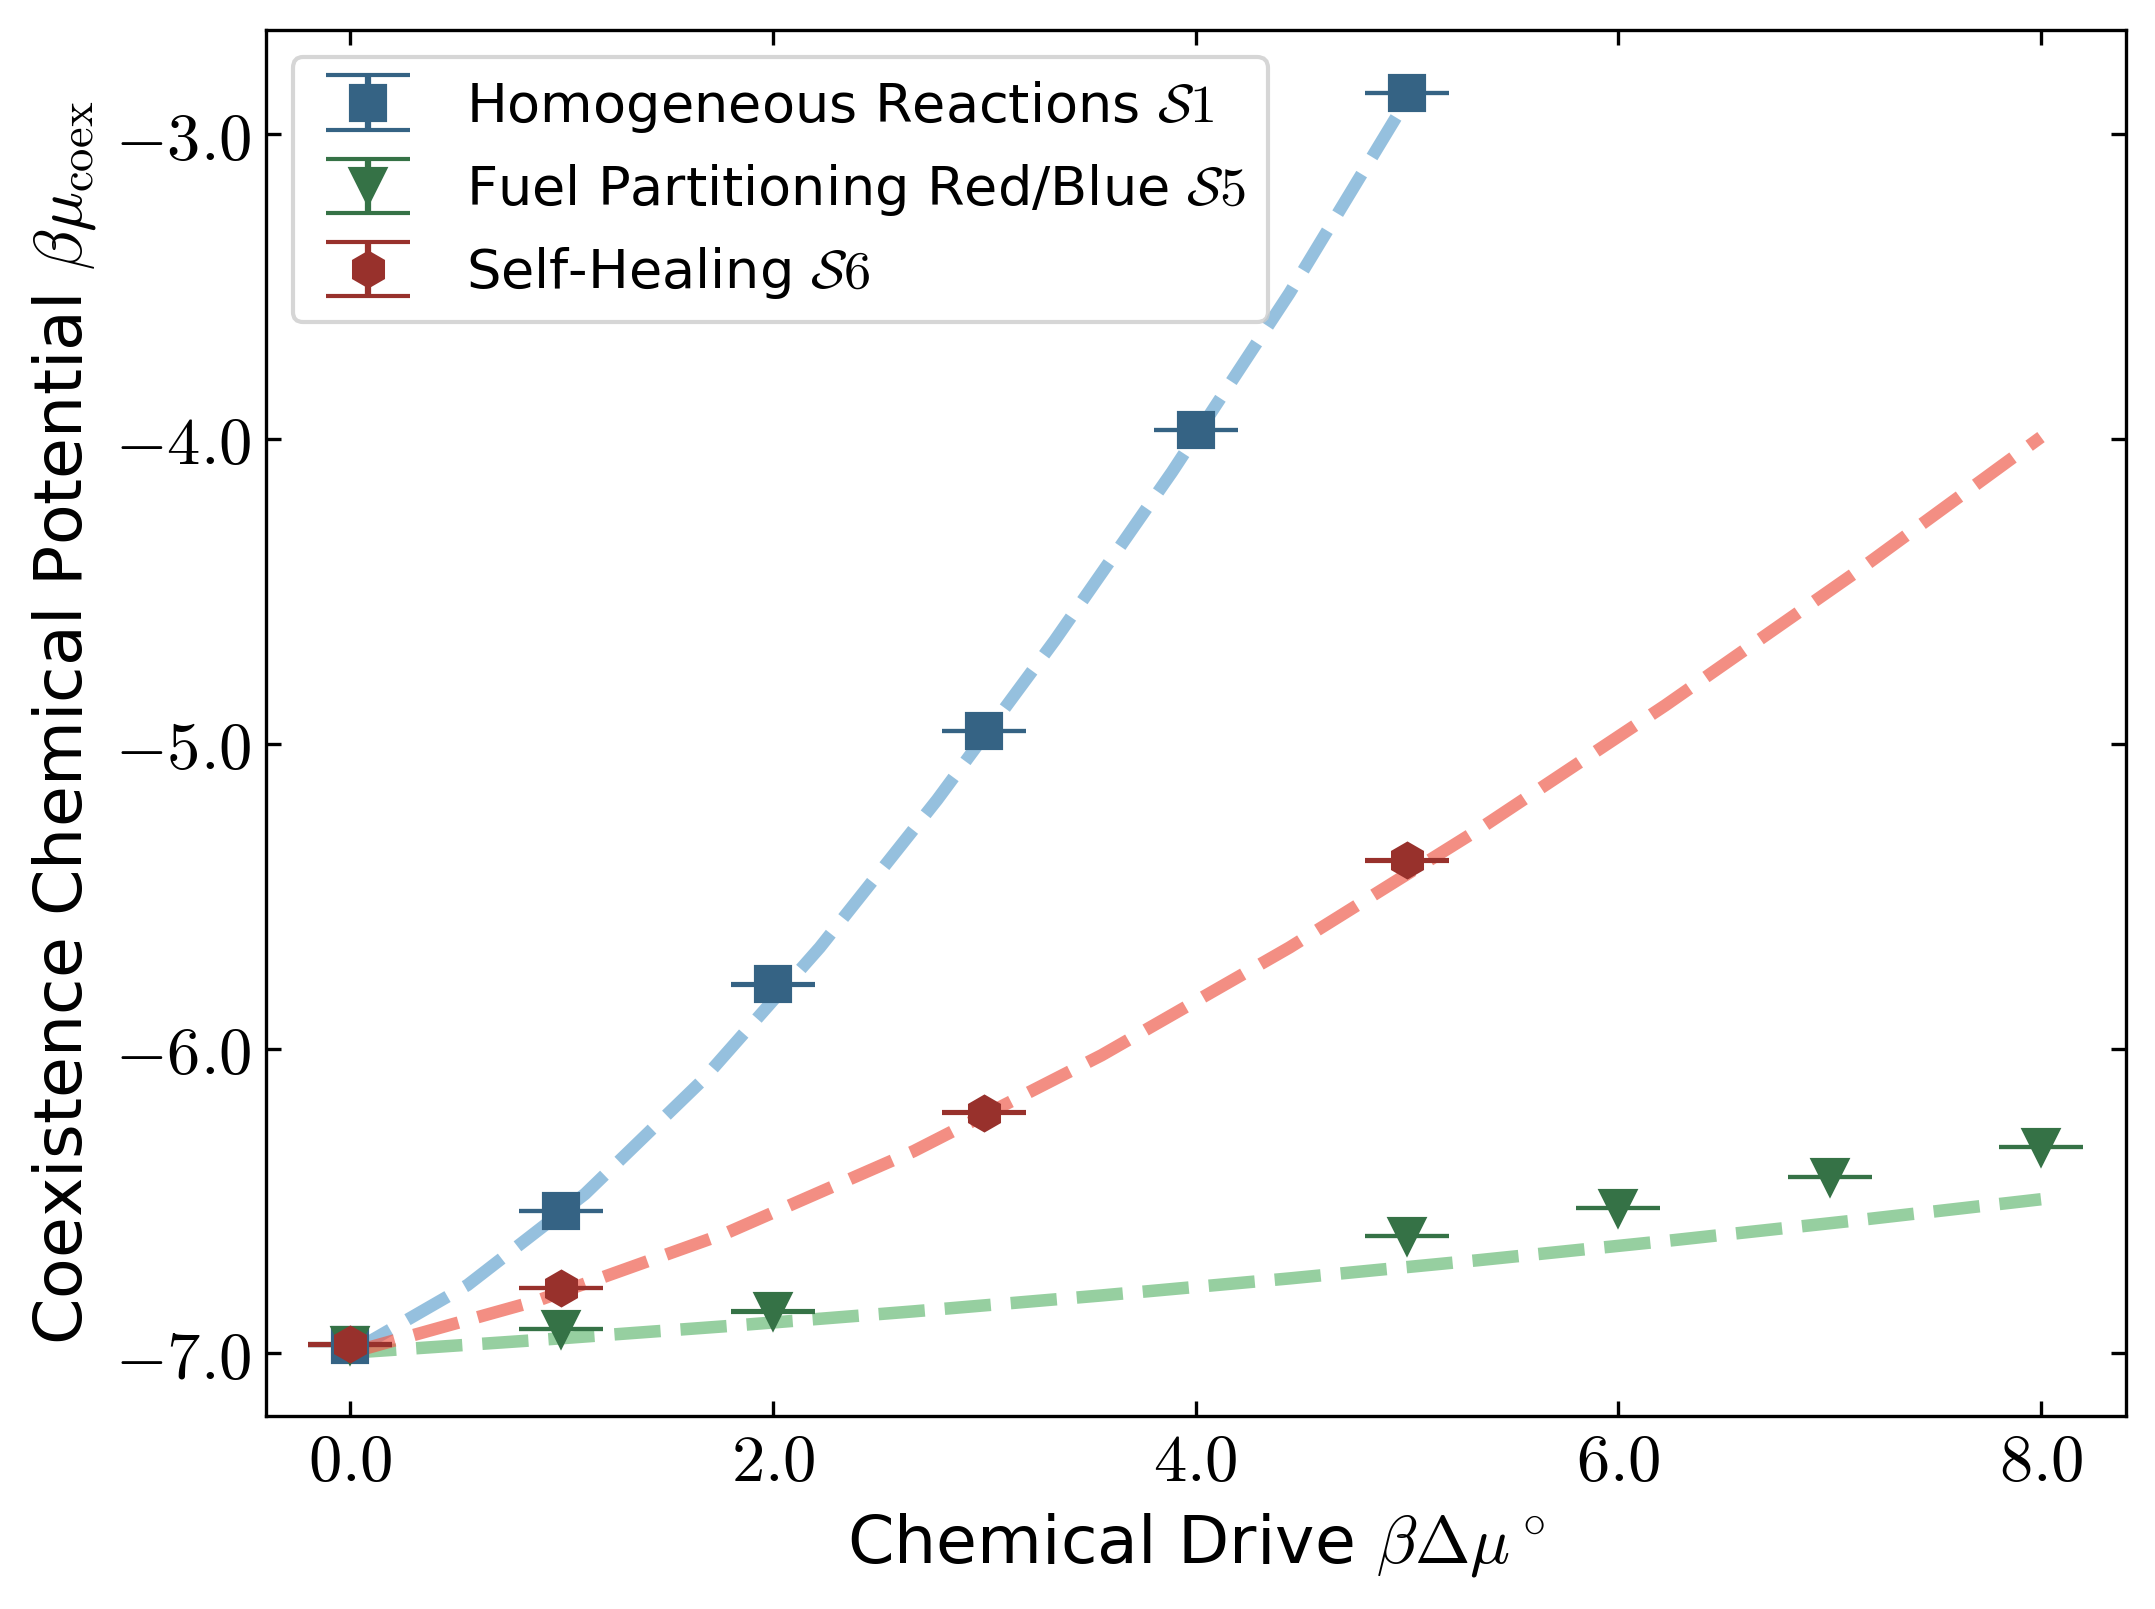

In [82]:
fig, ax = plt.subplots(figsize=(8,6))
whiteout()

numerical = pd.read_csv("/media/moritz/PHD_PROJECT/DEC25/coex/homo_data.csv")
theory = pd.read_csv("/media/moritz/PHD_PROJECT/DEC25/coex/homo_theory.csv")
ax.plot(theory['dmu'], theory['sol'], lw=3,  color=blues[1], alpha=0.7, ls='dashed')
ax.errorbar(numerical['dmu'], numerical['muc'], yerr=numerical['dmuc'], color=blues[-2],
            capsize=10, ms=8, ls='none', marker='s', label=r'Homogeneous Reactions $\mathcal{S}1$')


numerical = pd.read_csv("/media/moritz/PHD_PROJECT/DEC25/coex/s6_coex.csv")
theory = pd.read_csv("/media/moritz/PHD_PROJECT/DEC25/coex/s6_theory.csv")
ax.plot(theory['dmu'], theory['sol'], lw=3,  color=greens[1], alpha=0.7, ls='dashed')
ax.errorbar(numerical['dmu'], numerical['muc'], yerr=numerical['dmuc'], color=greens[-2],
            capsize=10, ms=8, ls='none', marker='v', label=r'Fuel Partitioning Red/Blue $\mathcal{S}5$')


numerical = pd.read_csv("/media/moritz/PHD_PROJECT/DEC25/coex/s7_coex.csv")
theory = pd.read_csv("/media/moritz/PHD_PROJECT/DEC25/coex/s7_theory.csv")
ax.plot(theory['dmu'], theory['sol'], lw=3,  color=reds[1], alpha=0.7, ls='dashed')
ax.errorbar(numerical['dmu'], numerical['muc'], yerr=numerical['dmuc'], color=reds[-2],
            capsize=10, ms=8, ls='none', marker='h', label=r'Self-Healing $\mathcal{S}6$')

ax.legend(fontsize=FS_LEGEND-3)

ax.set_ylabel(r'Coexistence Chemical Potential $\beta \mu_{\mathrm{coex}}$', fontsize=FS_LEGEND)
ax.set_xlabel(r'Chemical Drive $\beta \Delta \mu^\circ$', fontsize=FS_LEGEND)

ax.set_xticks([0,2,4,6,8],[r'$0.0$', '$2.0$', '$4.0$', '$6.0$', '$8.0$'], fontsize=FS_LEGEND)
ax.set_yticks([-7, -6, -5, -4, -3], [r'$-7.0$', r'$-6.0$', r'$-5.0$', r'$-4.0$', r'$-3.0$'], fontsize=FS_LEGEND)

plt.savefig("fig_coex_vs_dmu.pdf", bbox_inches='tight', dpi=300)